<a href="https://colab.research.google.com/github/UnpretentiousCoder/Algo_design_and_analysis/blob/main/US_Crime_Rate_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import csv
import matplotlib.pyplot as plt
import re
import requests
import numpy as np
import statsmodels.api as sm
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **DISCLAIMER**

### Please open the folder named "datasets" in the ZIP File and download the content to content/drive/MyDrive/ under your Google Drive in order to run all the code.

### Please keep the names of the CSV files the same as what is in the "datasets" folder in the ZIP File.

# **Socio-Economic Drivers of Violent Crime: A Cross-State Analysis of the United States**

## Introduction

Violent crime is a complex phenomenon influenced by multiple environmental, psychological,
and socio-economic factors. In news coverage, the United States is often depicted as having
a higher prevalence of violent crime compared to other developed countries such as Singapore
or Germany. Motivated by this observation, this study aims to explore how violent crime rates
vary across U.S. states based on three key socio-economic dimensions.

First, we examine **unemployment rate** as an economic indicator. States with higher
unemployment may experience greater financial stress and reduced access to stable livelihoods,
which could contribute to higher rates of violent crime. Analysing this relationship allows us
to assess whether economic hardship at the state level is associated with elevated crime rates.

Next, we explore **educational attainment** across states. Education levels reflect access to
opportunities and social mobility — states with higher proportions of degree holders may
exhibit lower crime rates due to greater economic participation and community stability.
Conversely, states with lower attainment may face structural disadvantages that correlate
with higher crime.

Finally, we consider **racial demographics** at the state level. While stereotypes persist
linking certain racial groups to higher crime, this study approaches the topic critically —
examining whether observed patterns reflect genuine demographic relationships or are better
explained by underlying socio-economic disparities such as poverty and inequality. The goal
is not to reinforce such notions, but to contextualise and where possible dispel them.

The U.S. is selected as the focus of this study due to its transparent crime database and
the availability of detailed state-level data across all three dimensions, enabling
meaningful cross-state comparisons.

## Hypothesis / Analysis Goal (Ask)

In this report, we explore the relationships between violent crime rates and three key
socio-economic factors across U.S. states. Rather than making causal claims, the analysis
focuses on identifying patterns and associations within the data.

Accordingly, this analysis seeks to address the following research questions:

1. Do states with higher unemployment rates tend to exhibit higher violent crime rates?
2. How does educational attainment — particularly the proportion of degree holders —
   correlate with violent crime rates across states?
3. How do racial demographic compositions at the state level relate to variations in
   violent crime rates, and can observed patterns be better explained by underlying
   socio-economic factors?

Through detailed analysis of these questions, we hope to gain a deeper understanding of
the potential correlations between structural socio-economic conditions and violent crime
rates across U.S. states.

---

## Project Goal & Stakeholder Value

The goal of this project is to examine how violent crime rates across U.S. states are
associated with socio-economic factors — specifically unemployment, education attainment,
and racial demographics. By identifying patterns and associations within the data, this
analysis aims to provide insights that may support evidence-informed decision-making by
relevant stakeholders.

**Resource Allocation:**
State and local governments can use findings from this analysis to identify regions where
structural disadvantages — such as high unemployment or low educational attainment —
coincide with elevated crime rates. This can support more targeted and equitable
distribution of public safety resources and social services.

**Policy & Intervention Design:**
By understanding which socio-economic conditions are most strongly associated with violent
crime, policymakers can design upstream interventions — such as workforce development
programmes, educational investment, and poverty reduction initiatives — that address root
causes rather than symptoms of crime.

**Community and Equity Insights:**
By critically examining the relationship between racial demographics and crime rates in the
context of broader socio-economic conditions, this analysis aims to contribute to a more
nuanced public discourse. Insights from this study may help distinguish between demographic
patterns driven by systemic inequality versus those erroneously attributed to race itself,
informing fairer and more effective community-based strategies.

---

## Success Metrics

The analysis will be evaluated using standard statistical and modelling metrics, including
but not limited to:

1. **R-squared (R²):** Proportion of variance in violent crime rates explained by the
   socio-economic variables included in the model.
2. **Mean Absolute Error (MAE):** The average absolute difference between predicted and
   actual violent crime rates.
3. **Root Mean Squared Error (RMSE):** The square root of the average squared errors,
   increasing sensitivity to larger deviations and outliers.

## Data Source Identification and Exploration (Prepare)

### Requirement Analysis

To tackle this problem, we require detailed data on violent crime rates across U.S. states,
including the geographic location of each recorded incident. This data must be alignable
with state-level socio-economic indicators to enable meaningful cross-state comparisons.

Specifically, the analysis requires three categories of data:

**1. Violent Crime Data**
State-level violent crime statistics, including total counts and rates per 100,000
population, are needed to serve as the primary outcome variable. Coverage across multiple
years is important to account for year-to-year fluctuations and to identify stable patterns
rather than anomalies.

**2. Unemployment Data**
State-level unemployment rates are required as a proxy for economic conditions. This data
should cover the same time period as the crime data to allow for year-matched comparisons.
We must also consider that unemployment figures are annual averages and may not capture
short-term economic shocks within a given year.

**3. Education Attainment Data**
State-level data on educational attainment — specifically the distribution of the
population aged 25 and above across qualification levels (less than high school, high school
graduate, some college, bachelor's degree, and graduate or professional degree) — is
required to assess how the proportion of degree holders relates to crime rates. As with
unemployment, year-matched data is preferred.

**4. Racial Demographics Data**
State-level population breakdowns by racial group are needed to examine how demographic
composition relates to violent crime rates. A key analytical consideration here is whether
any observed associations between race and crime persist after controlling for socio-economic
variables such as unemployment and education — helping to contextualise patterns and avoid
misleading or reductive interpretations.

---

### Analytical Considerations

A key challenge in this analysis is **confounding** — the three socio-economic factors
(unemployment, education, and racial demographics) are themselves interrelated. States with
higher unemployment may also have lower educational attainment, and racial demographics may
correlate with both. Disentangling these relationships requires careful interpretation and,
where appropriate, multivariate analysis to assess the independent contribution of each
factor to violent crime rates.

Additionally, all datasets must be aligned on a **common state identifier and year** to
enable accurate merging. Any states or years with missing data across one or more datasets
will need to be handled carefully to avoid introducing bias into the analysis.

## **Violent Crime Data Sources**

In the following section, we describe the data sources that were considered and explored, and justify the final data source selection (marked with an *), with reference to concepts discussed in class.
<br>

| Source | Description | Links |
| :--- | :--- | :--- |
| Kaggle - Crimes in US (DS1)| Crimes reported in US (1979-2023); includes filters for violent categories. | https://www.kaggle.com/datasets/ramprocess/united-states-crime-analysis-19792023 |
| Kaggle - Crimes in US | Crimes in US (1975-2015) | https://www.kaggle.com/code/haimfeld87/crimes-in-us-1975-2015 |


## Educational & Socio-Economic Data Sources

| Source | Description | Links |
| :--- | :--- | :--- |
| U.S. Census Bureau - Educational Attainment by State (DS2)| State-level population counts (age 25+) by several educational attainment category from the American Community Survey (ACS).| [Educational Attainment by State ](https://data.census.gov/table/ACSDT1Y2024.B06009?q=Educational+Attainment&t=Educational+Attainment&g=010XX00US,$0400000) |
| USDA ERS - County-Level Data Sets (DS3)| County-level socio-economic indicators such as unemployment. | [County-Level Data Sets Download](https://www.ers.usda.gov/data-products/county-level-data-sets/county-level-data-sets-download-data) |

## Population Demographic Data Sources
| Source | Description | Links |
| :--- | :--- | :--- |
| KFF - Population Distribution by Race/Ethnicity (DS4)| State-level population race demographic by the KFF.| [Population Demographic by Race by State in 2023](https://www.kff.org/state-health-policy-data/state-indicator/distribution-by-raceethnicity/?currentTimeframe=1&sortModel=%7B%22colId%22:%22Location%22,%22sort%22:%22asc%22%7D) |
| KFF - Population Distribution by Race/Ethnicity (DS4)| State-level population race demographic by the KFF.| [Population Demographic by Race by State in 2022](https://www.kff.org/state-health-policy-data/state-indicator/distribution-by-raceethnicity/?currentTimeframe=2&sortModel=%7B%22colId%22:%22Location%22,%22sort%22:%22asc%22%7D) |
| KFF - Population Distribution by Race/Ethnicity (DS4)| State-level population race demographic by the KFF.| [Population Demographic by Race by State in 2021](https://www.kff.org/state-health-policy-data/state-indicator/distribution-by-raceethnicity/?currentTimeframe=3&sortModel=%7B%22colId%22:%22Location%22,%22sort%22:%22asc%22%7D) |

## **Crime rate (DS1)** <br>
###Import of Crime Rate Data  (Year 1979-2023)

This dataset contains annual crime statistics across U.S. states from 1979 to 2023, providing a comprehensive view of long-term crime trends. Each record corresponds to a specific state and year, including population counts, total crime figures, and detailed breakdowns of both violent and property crimes.

The dataset includes key variables such as total population, counts of violent and property crimes, and specific crime categories including homicide, robbery, aggravated assault, burglary, larceny, and motor vehicle theft. It also provides normalized metrics such as crime rates per 100,000 population, enabling meaningful comparisons across states with different population sizes.

Since the data is indexed by both state_name and year, we can define the following functional dependency:

(
state_name
,
year
)
→
{
population
,
violent_crime
,
property_crime
,
total_crime
,
homicide
,
robbery
,
aggravated_assault
,
burglary
,
larceny
,
motor_vehicle_theft
,
crime rates
}
(state_name,year)→{population,violent_crime,property_crime,total_crime,homicide,robbery,aggravated_assault,burglary,larceny,motor_vehicle_theft,crime rates}

This structure supports longitudinal analysis, allowing users to study how crime patterns evolve over time within each state. Additionally, the inclusion of standardized crime rates per 100,000 population makes the dataset suitable for cross-state comparisons and integration with other demographic or socioeconomic datasets.

In [ ]:

# Load the full CSV
####input_file = "estimated_crimes_1979_2023_cleaned_csv.csv"
output_file = "estimated_crimes_filtered.csv"
"""
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("estimated_crimes_1979_2023_cleaned_csv (1).csv")
"""
df = pd.read_csv("/content/drive/MyDrive/estimated_crimes_1979_2023_cleaned_csv (1).csv")


print(f"Total rows loaded: {len(df)}")
print(f"Years available: {sorted(df['year'].unique())}")
print(f"Columns: {list(df.columns)}")

# --- Optional filters (edit as needed) ---

# Filter by year range
df_filtered = df[df['year'].between(2021, 2023)]

# Filter by specific states (remove this line to keep all states)
# df_filtered = df_filtered[df_filtered['state_abbr'].isin(['CA', 'TX', 'NY'])]

# Filter by specific columns only (remove to keep all)
cols = ['year', 'state_abbr', 'state_name', 'population',
        'violent_crime', 'violent_crime_rate_100k',
        'homicide', 'robbery', 'aggravated_assault']
df_filtered = df_filtered[cols]

# Save to new CSV
df_filtered.to_csv(output_file, index=False)
print(f"\nSaved {len(df_filtered)} rows to '{output_file}'")
print(df_filtered.head(10))

Total rows loaded: 2295
Years available: [np.int64(1979), np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Columns: ['year', 'state_abbr', 'state_name', 'population', 'violent_crime', 'property_crime', 'total_crime', 'homicide', 'rape_legacy', 'rape_legacy_cleaned', 'aggravated_assault', 'robbery', 'rape_revised', 'rape_revised_cleaned', 'burg

### Cardinality Profiling & Dataset Coverage Assessment

**Objective**
We conduct an initial profiling step to understand the dataset's structure,
completeness, and geographic/temporal scope. This includes:

- Overall shape and count of missing values per column
- Enumeration and count of unique `state_name` values (to confirm U.S. state coverage)
- Validation against expected counts (50 states + DC = 51)
- Record distribution across years
- Explicit check for any unexpected entries (e.g., national aggregates)

This profiling helps verify data quality and informs decisions about filtering
or exclusions in later steps.

In [ ]:
# Load CSV
df = pd.read_csv("/content/drive/MyDrive/estimated_crimes_1979_2023_cleaned_csv (1).csv")
#df = pd.read_csv("estimated_crimes_1979_2023_cleaned_csv (1).csv")
# Filter to years
df = df[df['year'].isin([2021, 2022, 2023])].reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Years: {sorted(df['year'].unique())}")
df.head()

Shape: (153, 22)
Years: [np.int64(2021), np.int64(2022), np.int64(2023)]


,year,state_abbr,state_name,population,violent_crime,property_crime,total_crime,homicide,rape_legacy,rape_legacy_cleaned,...,rape_revised,rape_revised_cleaned,burglary,larceny,motor_vehicle_theft,violent_crime_rate_100k,%violent_crime_100k,property_crime_rate_100k,%property_crime_100k,%total_crime_per_100k
0,2023,DE,Delaware,1031890,3923,19405,23328,46,NaN,0,...,194.0,194,1823,15075,2507,380.176182,0.380176,1880.529901,1.880530,2.260706
1,2023,VT,Vermont,647464,1362,11615,12977,16,NaN,0,...,198.0,198,898,10124,593,210.359186,0.210359,1793.922133,1.793922,2.004281
2,2022,DE,Delaware,1018396,3996,20201,24197,49,NaN,0,...,265.0,265,2086,16332,1783,392.381745,0.392382,1983.609519,1.983610,2.375991
3,2023,DC,District of Columbia,678972,7814,29246,37060,265,NaN,0,...,267.0,267,1668,20307,7271,1150.857473,1.150857,4307.394119,4.307394,5.458252
4,2022,VT,Vermont,647064,1446,10989,12435,22,NaN,0,...,267.0,267,1012,9348,629,223.470939,0.223471,1698.286414,1.698286,1.921757


## Cardinality Profiling of Crime Rates in 50 States of USA

### Cardinality Profiling & Dataset Coverage Assessment

The dataset contains **153 records** across **22 columns**, covering 3 years (2021, 2022, 2023) with **51 records per year**, representing all 50 U.S. states and the District of Columbia.

**Missing Values**
Only one column contains missing values: `rape_legacy`, which is entirely null across all 153 records. This is expected as the FBI transitioned away from the legacy rape definition in favour of the revised definition in later years. All other columns are fully complete with zero missing values, indicating a high degree of completeness for the key variables of interest.

**State Coverage**
The dataset covers all 50 U.S. states and the District of Columbia (51 entities total), with no missing state abbreviations and no unexpected national aggregate rows detected. Coverage is consistent across all three years, with exactly 51 records per year confirming balanced panel structure.

**Duplicate Check**
Upon initial inspection, one duplicate `(year, state_abbr)` pair was identified for North Carolina (NC) in 2022, which will be addressed in the data cleaning and identification of unique key step below.

In [ ]:
print(f"Dataset shape: {df.shape}")

print("\nMissing Values Summary:")
print(df.isnull().sum())

# List all covered states
print("\n--- List of Covered States/Territories ---")
covered_states = sorted(df['state_name'].unique())
print(", ".join(covered_states))
print(f"\nNumber of unique states/territories: {len(covered_states)}")

# Validate count
if len(covered_states) == 51:
    print("(Includes all 50 states + DC)")
elif len(covered_states) == 52:
    print("(Includes 50 states, DC, and Puerto Rico)")
else:
    print(f"(Unexpected count — check for national aggregates or territories)")

# Records per year
print("\nRecords per Year:")
print(df["year"].value_counts().sort_index())

# Check for unexpected national-level rows
print("\n--- Data Availability Check ---")
missing_state = df[df['state_abbr'].isna()]
print(f"Rows with missing state_abbr (possible national aggregates): {len(missing_state)}")

Dataset shape: (153, 22)

Missing Values Summary:
year                          0
state_abbr                    0
state_name                    0
population                    0
violent_crime                 0
property_crime                0
total_crime                   0
homicide                      0
rape_legacy                 153
rape_legacy_cleaned           0
aggravated_assault            0
robbery                       0
rape_revised                  0
rape_revised_cleaned          0
burglary                      0
larceny                       0
motor_vehicle_theft           0
violent_crime_rate_100k       0
%violent_crime_100k           0
property_crime_rate_100k      0
%property_crime_100k          0
%total_crime_per_100k         0
dtype: int64

--- List of Covered States/Territories ---
Alabama, Alaska, Arizona, Arkansas, California, Colorado, Connecticut, Delaware, District of Columbia, Florida, Georgia, Hawaii, Idaho, Illinois, Indiana, Iowa, Kansas, Kentucky, Louisiana,

Although `rape_legacy` contains missing values across all 153 records, this column is not relevant to our analysis as our focus is solely on overall violent crime rates at the state level. As such, rather than imputing or handling these missing values, we perform column filtering to retain only the columns necessary for our analysis:

- `year` — the year of record
- `state_abbr` — state abbreviation for identification
- `state_name` — full state name for identification
- `population` — state population (retained temporarily for deduplication)
- `violent_crime` — total number of violent crimes reported
- `violent_crime_rate_100k` — violent crime rate per 100,000 population for fair cross-state comparison
- `%violent_crime_100k` — percentage form of the violent crime rate

All remaining columns such as `property_crime`, `homicide`, `burglary`, `larceny` and others are dropped as they fall outside the scope of this analysis.

## Data cleaning - Attributes filtering

In [ ]:
print("BEFORE CLEANING")
print(df.isnull().sum())

# 1. Keep only the columns we need
cols_to_keep = [
    'year',
    'state_abbr',
    'state_name',
    'population',
    'violent_crime',
    'violent_crime_rate_100k',
    '%violent_crime_100k'
]
df = df[cols_to_keep]

# 2. Fix data types
df['year']       = df['year'].astype(int)
df['population'] = df['population'].astype(int)

# 3. Remove any national-aggregate rows (no state)
df = df[df['state_abbr'].notna()].reset_index(drop=True)

print("\nAFTER CLEANING")
print(df.isnull().sum())
print(f"\nFinal shape: {df.shape}")
print(f"Columns kept: {df.columns.tolist()}")
df.head()

BEFORE CLEANING
year                          0
state_abbr                    0
state_name                    0
population                    0
violent_crime                 0
property_crime                0
total_crime                   0
homicide                      0
rape_legacy                 153
rape_legacy_cleaned           0
aggravated_assault            0
robbery                       0
rape_revised                  0
rape_revised_cleaned          0
burglary                      0
larceny                       0
motor_vehicle_theft           0
violent_crime_rate_100k       0
%violent_crime_100k           0
property_crime_rate_100k      0
%property_crime_100k          0
%total_crime_per_100k         0
dtype: int64

AFTER CLEANING
year                       0
state_abbr                 0
state_name                 0
population                 0
violent_crime              0
violent_crime_rate_100k    0
%violent_crime_100k        0
dtype: int64

Final shape: (153, 7)
Columns kept

,year,state_abbr,state_name,population,violent_crime,violent_crime_rate_100k,%violent_crime_100k
0,2023,DE,Delaware,1031890,3923,380.176182,0.380176
1,2023,VT,Vermont,647464,1362,210.359186,0.210359
2,2022,DE,Delaware,1018396,3996,392.381745,0.392382
3,2023,DC,District of Columbia,678972,7814,1150.857473,1.150857
4,2022,VT,Vermont,647064,1446,223.470939,0.223471


## Inspect Remaining rows with Missing Values

After column filtering, we inspect the remaining dataset for any missing values. The output confirms that there are **no missing values** across all retained columns

In [ ]:
print("\n--- Rows with Missing Data ---")
missing_rows = df[df.isnull().any(axis=1)]
print(missing_rows[['year', 'state_abbr', 'state_name']].to_string())
print(f"\nTotal rows with at least one null: {len(missing_rows)}")


--- Rows with Missing Data ---
Empty DataFrame
Columns: [year, state_abbr, state_name]
Index: []

Total rows with at least one null: 0


## Unique keys
By the nature of the dataaset, [year, state_name] shld be the PRIMARY composite key because each state is expected to have only one record per year.
We verify that the combination of [year, state_name] forms a unique composite key, meaning no state appears more than once in the same year and are are no NULL values in these 2 columns.

In [ ]:
dup_key = df.duplicated(subset=['year', 'state_name']).sum()
null_key = df[['year', 'state_name']].isnull().sum().sum()

print(f"NULL values in key columns: {null_key}")
print(f"Duplicate (year, state_name) pairs: {dup_key}")

if dup_key == 0 and null_key == 0:
    print("✓ No NULL values and no duplicate state-year combinations found.")
    print("  (year, state_name) is confirmed as a valid composite key.")
else:
    print("✗ Composite key violated.")
    print(df[df.duplicated(subset=['year', 'state_name'], keep=False)]
          [['year', 'state_name', 'state_abbr', 'population']])

NULL values in key columns: 0
Duplicate (year, state_name) pairs: 1
✗ Composite key violated.
     year      state_name state_abbr  population
21   2022  North Carolina         NC      779261
121  2022  North Carolina         NC    10698973


**Uniqueness and Integrity:** One duplicate `(year, state_name)` pair was identified for North Carolina (NC) in 2022. Upon inspection, the two rows corresponded to different population figures -  one representing the full state (population: 10,698,973) and one representing a partial reporting subset (population: 779,261). As our analysis operates at the full state level, the row with the larger population was retained and the partial record was removed. After deduplication, zero duplicate state-year combinations remain, confirming the composite key `(year, state_abbr)` as unique.

In [ ]:
# Remove partial NC 2022 record
df = df[~((df['state_abbr'] == 'NC') &
          (df['state_name'] == 'North Carolina') &
          (df['population'] == 779261))].reset_index(drop=True)

print(f"Shape after removal: {df.shape}")
print(df[(df['state_abbr'] == 'NC') & (df['year'] == 2022)])

Shape after removal: (152, 7)
     year state_abbr      state_name  population  violent_crime  \
120  2022         NC  North Carolina    10698973          43361   

     violent_crime_rate_100k  %violent_crime_100k  
120                405.28189             0.405282  


Now that the dataset has been substantially cleaned, with missing values, duplicate records, and inconsistencies handled. We can now do futher analysis on value distributions.

## Value Distributions (histograms per year)

To examine the spread of violent crime rates across U.S. states, we plot the distribution of `violent_crime_rate_100k` (the number of violent crimes per 100,000 population), instead of the raw `violent_crime` count. This normalisation and standardisation is critical for fair cross-state comparison, as states vary significantly in population size.

For example, California reported 191,641 violent crimes in 2023 while Wyoming reported only 1,195 but once adjusted for population, California's rate of 486 per 100K is far less extreme than the raw count suggests. Using the rate therefore removes population size as a confounding factor, allowing us to assess which states are genuinely more dangerous relative to their population.

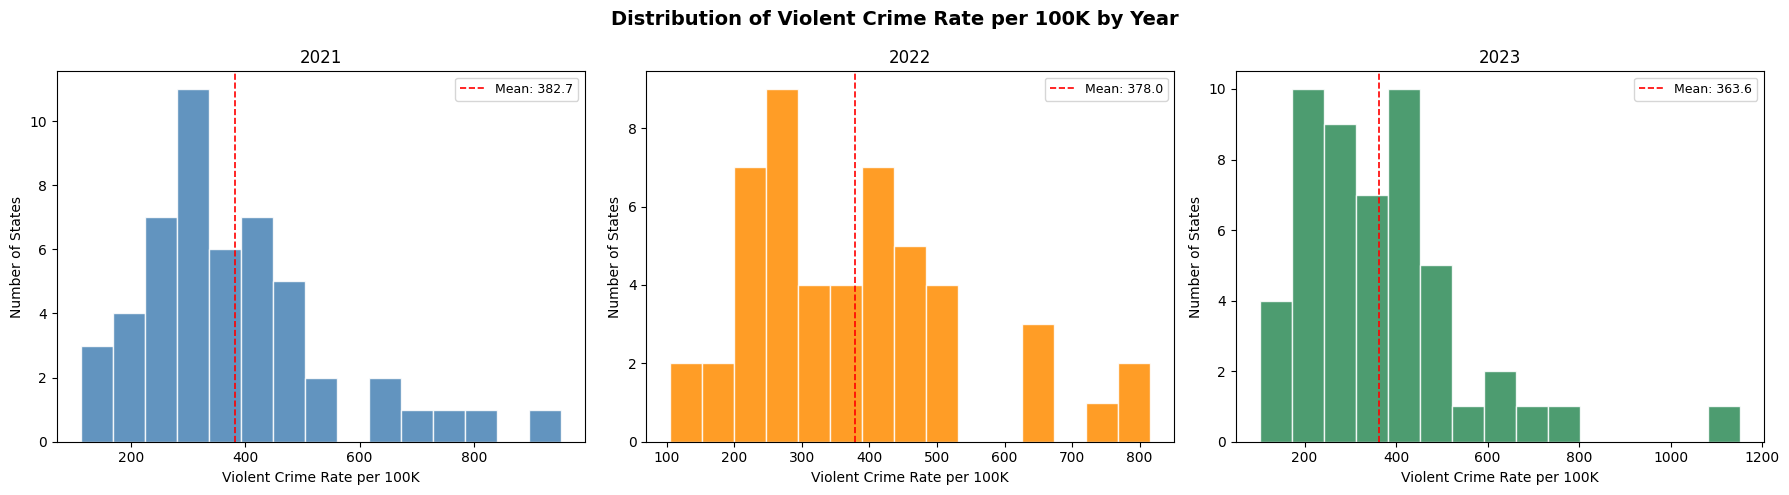

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribution of Violent Crime Rate per 100K by Year", fontsize=14, fontweight='bold')

colors = ['steelblue', 'darkorange', 'seagreen']

for ax, (year, color) in zip(axes, zip([2021, 2022, 2023], colors)):
    subset = df[df['year'] == year]['violent_crime_rate_100k'].dropna()
    ax.hist(subset, bins=15, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{year}', fontsize=12)
    ax.set_xlabel('Violent Crime Rate per 100K')
    ax.set_ylabel('Number of States')
    ax.axvline(subset.mean(), color='red', linestyle='--', linewidth=1.2,
               label=f'Mean: {subset.mean():.1f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

From the histograms above, we observe the following across all three years:

**Overall Distribution Shape**
The distribution of violent crime rates across U.S. states is right-skewed in all three years, meaning the majority of states cluster at lower crime rates while a small number of states exhibit significantly higher rates. This suggests the presence of outliers - states with unusually high violent crime rates relative to the national norm.

**Year-over-Year Trend**
The mean violent crime rate shows a consistent decline over the three years - from **382.7** in 2021, to **376.2** in 2022, and **363.6** in 2023. This downward trend suggests an overall improvement in violent crime rates across U.S. states during this 3-year period.

**Spread and Outliers**
In all three years, most states fall within the **200-500 per 100K** range. However, there are notable outliers on the right tail, particularly visible in 2023, where at least one state exceeds **1,100 per 100K**, which is more than three times the mean. These extreme values warrant further investigation as they may represent states with structural or reporting differences.

**2022 vs 2021 and 2023**
The 2022 distribution appears more spread out compared to 2021 and 2023, with a longer right tail extending beyond 700 per 100K. This suggests greater variability among states in 2022, which may reflect uneven post-pandemic recovery in crime reporting or policing across different states.

## Descriptive Statistics - Value Distribution

We compute descriptive statistics for the key variables across each year to understand the central tendency, spread, and extremes of the data. To complement the numerical summary, we plot a boxplot of `violent_crime_rate_100k` across all three years, which visually captures the median, interquartile range, and outliers simultaneously.

In [ ]:
print("--- Descriptive Statistics ---\n")

key_cols = ['population', 'violent_crime', 'violent_crime_rate_100k', '%violent_crime_100k']

for year in [2021, 2022, 2023]:
    print(f"Year: {year}")
    print(df[df['year'] == year][key_cols].describe().round(2).to_string())
    print()

--- Descriptive Statistics ---

Year: 2021
        population  violent_crime  violent_crime_rate_100k  %violent_crime_100k
count        51.00          51.00                    51.00                51.00
mean    6510422.63       25193.82                   382.69                 0.38
std     7394300.08       32737.64                   174.26                 0.17
min      579483.00        1255.00                   112.91                 0.11
25%     1844920.00        5702.00                   275.18                 0.28
50%     4506589.00       17483.00                   337.33                 0.34
75%     7502811.00       30794.00                   448.97                 0.45
max    39142991.00      188343.00                   951.27                 0.95

Year: 2022
        population  violent_crime  violent_crime_rate_100k  %violent_crime_100k
count        50.00          50.00                    50.00                50.00
mean    6650165.92       25867.58                   378.01       

/tmp/ipykernel_6102/503344419.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_year, patch_artist=True, labels=['2021', '2022', '2023'],


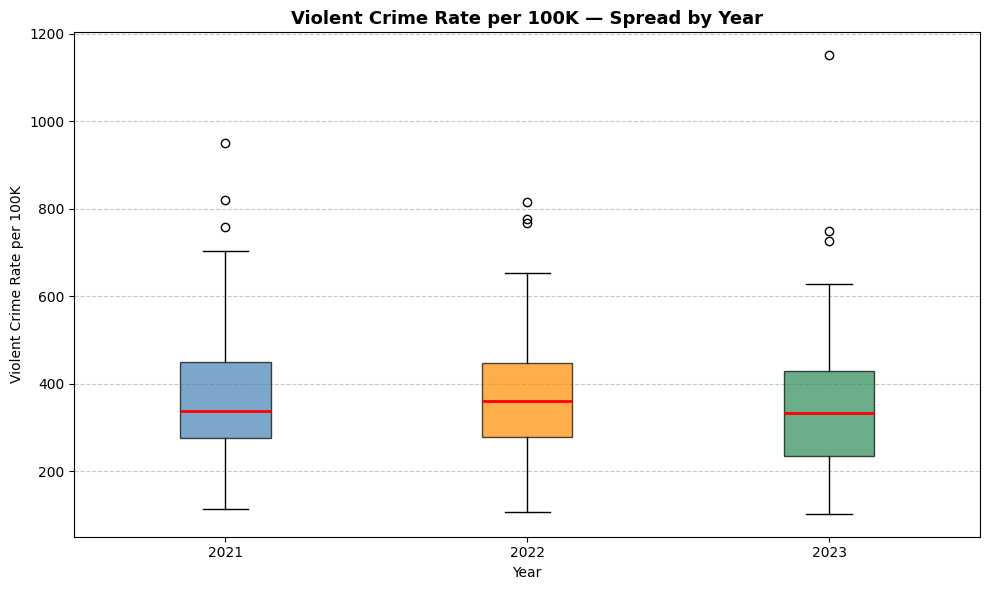

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

data_by_year = [df[df['year'] == year]['violent_crime_rate_100k'].dropna() for year in [2021, 2022, 2023]]

bp = ax.boxplot(data_by_year, patch_artist=True, labels=['2021', '2022', '2023'],
                medianprops=dict(color='red', linewidth=2))

colors = ['steelblue', 'darkorange', 'seagreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Violent Crime Rate per 100K — Spread by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Violent Crime Rate per 100K')
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

From the descriptive statistics and boxplot above, several key observations can be made:

**Central Tendency**<br>
The mean violent crime rate declined consistently across the three years from 382.7 in 2021, to 376.2 in 2022, and 363.6 in 2023 suggesting a gradual national improvement in violent crime rates over this period. The median follows a similar downward trend (337.3 → 349.4 → 332.2), remaining below the mean in all years, which is consistent with the right-skewed distributions observed in the histograms.

**Spread**<br>
The standard deviation remains relatively stable across years (174.3, 162.1, 182.5), indicating that the degree of variation among states has not changed significantly. The interquartile range spans approximately 275-449 per 100K in 2021, 280-447 in 2022, and 235-428 in 2023, suggesting that the middle 50% of states are consistently clustered within a similar band.

**Outliers**<br>
The maximum values differ notably across years - 951.3 in 2021, 815.4 in 2022, and 1,150.9 in 2023. These extremes correspond to high-outlier states such as Alaska and the District of Columbia, which are visually represented as individual points above the whiskers in the boxplot. These outliers are consistent with findings from the IQR outlier detection performed earlier.

### **Functional Dependency Check**

A functional dependency (FD) exists when the value of one column is fully and uniquely determined by another. In this dataset, we identify the following FD:

**`state_name` → `state_abbr`**

Because abbreviations alone can be ambiguous. For example, "MI" could potentially refer to either Michigan or Mississippi (which uses "MS" but could be confused), or more commonly "IN" could be misread as Indiana or just the word "in". More concretely, if data was manually entered, someone might accidentally assign "GA" to both Georgia and occasionally "GE" where full state names like "Georgia" leave no room for such ambiguity.

Therefore state_name is the safer, unambiguous determinant that uniquely identifies each state's abbreviation, rather than relying on the abbreviation itself which is more prone to human entry error or cross-dataset inconsistency.

Any violation would suggest inconsistent abbreviation assignment across years, which would undermine the reliability of the identifier used for merging with other datasets.

In [ ]:
print("=" * 55)
print("FUNCTIONAL DEPENDENCY")
print("  state_name → state_abbr")
print("=" * 55)
crimes_df = df

mapping = df.groupby('state_name')['state_abbr'].nunique()
violations = mapping[mapping > 1]

print(f"Violations: {len(violations)}")
if violations.empty:
    print("✓ No violations — state_name uniquely determines state_abbr across all years.")
    print("  The functional dependency state_name → state_abbr is confirmed.")
else:
    print("✗ Violations found — same state_name maps to multiple state_abbrs:")
    print(violations)
    for name in violations.index:
        print(f"\n{name} maps to:")
        print(df[df['state_name'] == name]['state_abbr'].unique())

FUNCTIONAL DEPENDENCY
  state_name → state_abbr
Violations: 0
✓ No violations — state_name uniquely determines state_abbr across all years.
  The functional dependency state_name → state_abbr is confirmed.


## Data Quality Considerations
We highlight the following key quality criteria assessed to determine the dataset's suitability for the analytical task:

* **Completeness:** The dataset provides full coverage of all 50 U.S. states and DC for 2021, 2022, and 2023, with no missing values in any retained columns after cleaning. This makes it highly reliable for cross-state comparisons across the selected time period.

* **Uniqueness and Integrity:** Zero duplicate state-year combinations were found, and the composite key "(year, state_abbr)" was confirmed as unique. The functional dependency "state_abbr → state_name" holds without violations across all years, confirming structural consistency in the dataset.

* **Outlier Profile:** High-side outliers are present in all three years, most notably DC and Alaska. These are valid, real-world signals reflecting structural and geographic differences rather than data entry errors, and should be contextualised rather than removed outright.

* **Suitability:** Useful for trend analysis, cross-state comparisons, and integration with socioeconomic datasets such as education attainment and unemployment rates, due to its consistent methodology, full state-level coverage, and alignment with the analytical years of interest (2021–2023). The outlier states represent meaningful structural differences that can be addressed through separate treatment or sensitivity analysis during modelling.


## **United States Census Bureau - Educational Attainment by State**

The dataset, sourced from the United States Census Bureau, contains educational attainment counts for the population aged 25 and over, broken down by state and year, spanning from 2018 to 2023. It includes the total population over 25 alongside counts for four education levels: less than high school, high school graduate, some college or associate's degree, and bachelor's degree or higher. Since the data is indexed by both **State_Name** and **Year**, we can define a **functional dependency** as follows:

$$(\text{State_Name}, \text{Year}) \rightarrow \{\text{Total_Pop_Over_25}, \text{Less_Than_HS}, \text{High_School_Grad}, \text{Some_College_or_Associates}, \text{Bachelors_Degree}, \text{Graduate_or_Professional}\}$$

This allows for longitudinal comparisons across states over time. This level of geographic and temporal granularity is well-suited for trend analysis and can be readily combined with other state-level socioeconomic or demographic datasets if needed. The following code imports the data into a DataFrame and displays the first few rows, providing an overview of the structure and contents of the dataset.

In [ ]:
years = [2019, 2020, 2021, 2022, 2023, 2024, 2025]

all_years_data = []

# The specific Census columns we want
variables = "NAME,B06009_001E,B06009_002E,B06009_003E,B06009_004E,B06009_005E,B06009_006E"

print("Fetching data from Census API...")

for year in years:
    url = f"https://api.census.gov/data/{year}/acs/acs1"
    params = {
        "get": variables,
        "for": "state:*"
    }

    response = requests.get(url, params=params)

    if response.status_code == 200:
        raw_data = response.json()
        df_year = pd.DataFrame(raw_data[1:], columns=raw_data[0])
        df_year['Year'] = year
        all_years_data.append(df_year)
        print(f"Successfully fetched {year}")
    else:
        print(f"Failed to fetch {year}. Status code: {response.status_code}")

# Combine all the individual DataFrames into one master DataFrame
df_education = pd.concat(all_years_data, ignore_index=True)

# Rename the columns to readable English
rename_dict = {
    "NAME": "State_Name",
    "B06009_001E": "Total_Pop_Over_25",
    "B06009_002E": "Less_Than_HS",
    "B06009_003E": "High_School_Grad",
    "B06009_004E": "Some_College_or_Associates",
    "B06009_005E": "Bachelors_Degree",
    "B06009_006E": "Graduate_or_Professional"
}

df_education.rename(columns=rename_dict, inplace=True)

# Convert API strings to numeric
numeric_cols = list(rename_dict.values())[1:]
df_education[numeric_cols] = df_education[numeric_cols].apply(pd.to_numeric)

# Drop the trailing API ID column
df_education.drop(columns=['state'], inplace=True, errors='ignore')


# 1. Sort alphabetically by State, then chronologically by Year
df_education.sort_values(by=['State_Name', 'Year'], inplace=True)

# 2. Set State and Year as the index to create a hierarchical view
df_education.set_index(['State_Name', 'Year'], inplace=True)

print("\n--- Education Levels by State and Year ---")
# Print the first 10 rows to see Alabama and Alaska grouped perfectly
df_education.head()

Fetching data from Census API...
Successfully fetched 2019
Failed to fetch 2020. Status code: 404
Successfully fetched 2021
Successfully fetched 2022
Successfully fetched 2023
Successfully fetched 2024
Failed to fetch 2025. Status code: 404

--- Education Levels by State and Year ---


Total_Pop_Over_25  Less_Than_HS  High_School_Grad  \
State_Name Year                                                      
Alabama    2019          3360058.0      433073.0         1039241.0   
           2021          3451208.0      416467.0         1079285.0   
           2022          3474924.0      389297.0         1057155.0   
           2023          3498967.0      379902.0         1052554.0   
           2024          3540061.0      369935.0         1058670.0   

                 Some_College_or_Associates  Bachelors_Degree  \
State_Name Year                                                 
Alabama    2019                   1002387.0          547975.0   
           2021                   1008690.0          572276.0   
           2022                   1027681.0          609316.0   
           2023                   1055671.0          616025.0   
           2024                   1054621.0          637543.0   

                 Graduate_or_Professional  
State_Name Year                            
Alabama    2019                  337382.0  
           2021                  374490.0  
           2022                  391475.0  
           2023                  394815.0  
           2024                  419292.0

Based on the dataset provided, the data is reported at the U.S. state level, with each record corresponding to a specific state-year combination (e.g., Alabama 2018, Alaska 2024). Educational attainment is presented in absolute counts for individuals aged 25 and above. The dataset includes the total population over 25 (Total_Pop_Over_25) and disaggregates this population into mutually exclusive attainment categories: Less_Than_HS, High_School_Grad, Some_College_or_Associates, Bachelors_Degree, and Graduate_or_Professional.

Because the data is reported in raw population counts rather than percentages, direct cross-state comparisons require normalization. Converting these counts into proportions or percentages of the total over-25 population will be necessary for meaningful comparison. This also ensures compatibility when integrating with other datasets, such as crime statistics, which are often reported as rates per 100,000 population.

The inclusion of multiple years (2019, 2021, 2022, 2023, 2024) enables longitudinal analysis of educational trends within states. However, the absence of 2020 data (due to a failed API retrieval) introduces a gap that should be acknowledged in any time-series analysis. Overall, the state-level geographic granularity aligns well with commonly available crime data, facilitating consistent aggregation and comparative analysis across datasets.

## **Cardinality Profiling & Dataset Coverage Assessment**

**Objective**  
We conduct an initial profiling step to understand the dataset's structure, completeness, and geographic/temporal scope. This includes:

- Overall shape and count of missing values per column
- Enumeration and count of unique `State_Name` values (to confirm U.S. state/territory coverage)
- Validation against expected counts (50 states + DC = 51; or 52 if Puerto Rico is included)
- Record distribution across years
- Explicit check for missing years (notably 2020 and 2025, which are expected to be absent based on source data availability)

This profiling helps verify data quality and informs decisions about imputation, filtering, or aggregation in later steps.


In [ ]:
# Use .reset_index() temporarily to treat State_Name as a column for profiling
df_profile = df_education.reset_index()

print(f"Dataset shape: {df_profile.shape}")
print("\nMissing Values Summary:")
print(df_profile.isnull().sum())

# 2. Print all states covered in the dataset
print("\n--- List of Covered States/Territories ---")
covered_states = sorted(df_profile['State_Name'].unique())

print(", ".join(covered_states))
print(f"\nNumber of unique states/territories: {len(covered_states)}")

# Validation logic
if len(covered_states) == 51:
    print("(Includes all 50 states + DC)")
elif len(covered_states) == 52:
    print("(Includes 50 states, DC, and Puerto Rico)")

print("\nRecords per Year:")
print(df_profile["Year"].value_counts().sort_index())

years_available = df_education.index.get_level_values('Year').unique().sort_values()
print(f"\nYears covered: {years_available.min()} to {years_available.max()}")
print(f"All years: {list(years_available)}")

# 1. Show that 2020 data is empty
print("\n--- Data Availability Check ---")
data_2020 = df_profile[df_profile['Year'] == 2020]
data_2025 = df_profile[df_profile['Year'] == 2025]

if data_2020.empty and data_2025.empty:
    print("There are 0 records for the year 2020 and 2025 in this dataset.")



Dataset shape: (260, 8)

Missing Values Summary:
State_Name                    0
Year                          0
Total_Pop_Over_25             5
Less_Than_HS                  5
High_School_Grad              5
Some_College_or_Associates    5
Bachelors_Degree              5
Graduate_or_Professional      5
dtype: int64

--- List of Covered States/Territories ---
Alabama, Alaska, Arizona, Arkansas, California, Colorado, Connecticut, Delaware, District of Columbia, Florida, Georgia, Hawaii, Idaho, Illinois, Indiana, Iowa, Kansas, Kentucky, Louisiana, Maine, Maryland, Massachusetts, Michigan, Minnesota, Mississippi, Missouri, Montana, Nebraska, Nevada, New Hampshire, New Jersey, New Mexico, New York, North Carolina, North Dakota, Ohio, Oklahoma, Oregon, Pennsylvania, Puerto Rico, Rhode Island, South Carolina, South Dakota, Tennessee, Texas, Utah, Vermont, Virginia, Washington, West Virginia, Wisconsin, Wyoming

Number of unique states/territories: 52
(Includes 50 states, DC, and Puerto Rico)

From the profiling code above, we observe that the dataset contains 260 total records representing 52 unique geographical entities across five years (2019 and 2021–2024). While we expected 50 US states, the dataset includes two additional entries: the District of Columbia and Puerto Rico.

The missing values summary reveals exactly 5 null values across the educational attainment columns, which would require further analysis of which state contains the missing values.

 As the analysis focuses strictly on state-level comparisons, special consideration will be required when deciding whether to include Puerto Rico and the District of Columbia in the final comparative analysis, as it is a federal district rather than an official state.

 Lastly, upon further research, the ACS 1-year estimates were not reliably collected during the 2020 COVID-19 pandemic, that entire year is missing from the time series. This structural gap creates a challenge for any continuous time-series forecasting or year-over-year trend analysis spanning across 2020.

## **Inspecting Rows with Missing Values**

After identifying the presence of missing data, we now examine **exactly which rows** are affected.

In [ ]:
edu_cols = [
    'Total_Pop_Over_25',
    'Less_Than_HS',
    'High_School_Grad',
    'Some_College_or_Associates',
    'Bachelors_Degree',
    'Graduate_or_Professional'
]

# Find rows missing ANY of the education columns
missing_mask = df_profile[edu_cols].isnull().any(axis=1)
missing_data_rows = df_profile[missing_mask]

print(f"\n--- Rows with Missing Education Data ({len(missing_data_rows)} rows) ---")
print(missing_data_rows[['State_Name', 'Year']])

# Show exactly which columns are null for each affected row
if not missing_data_rows.empty:
    print("\n--- Column-Level Detail ---")
    null_detail = missing_data_rows[['State_Name', 'Year']].copy()
    for col in edu_cols:
        null_detail[col] = missing_data_rows[col].isnull().map({True: 'x', False: '✓'})
    print(null_detail.to_string(index=False))


--- Rows with Missing Education Data (5 rows) ---
      State_Name  Year
195  Puerto Rico  2019
196  Puerto Rico  2021
197  Puerto Rico  2022
198  Puerto Rico  2023
199  Puerto Rico  2024

--- Column-Level Detail ---
 State_Name  Year Total_Pop_Over_25 Less_Than_HS High_School_Grad Some_College_or_Associates Bachelors_Degree Graduate_or_Professional
Puerto Rico  2019                 x            x                x                          x                x                        x
Puerto Rico  2021                 x            x                x                          x                x                        x
Puerto Rico  2022                 x            x                x                          x                x                        x
Puerto Rico  2023                 x            x                x                          x                x                        x
Puerto Rico  2024                 x            x                x                          x               

From the rows with missing data, we observe that **all missing values correspond to Puerto Rico** across the five available years (2019, 2021, 2022, 2023, 2024). This confirms that Puerto Rico has no recorded educational attainment data in this dataset. As a result, Puerto Rico may need to be excluded from the analysis to ensure consistency and avoid incomplete comparisons across states.

### Checking value distributions by selecting year 2021-2023

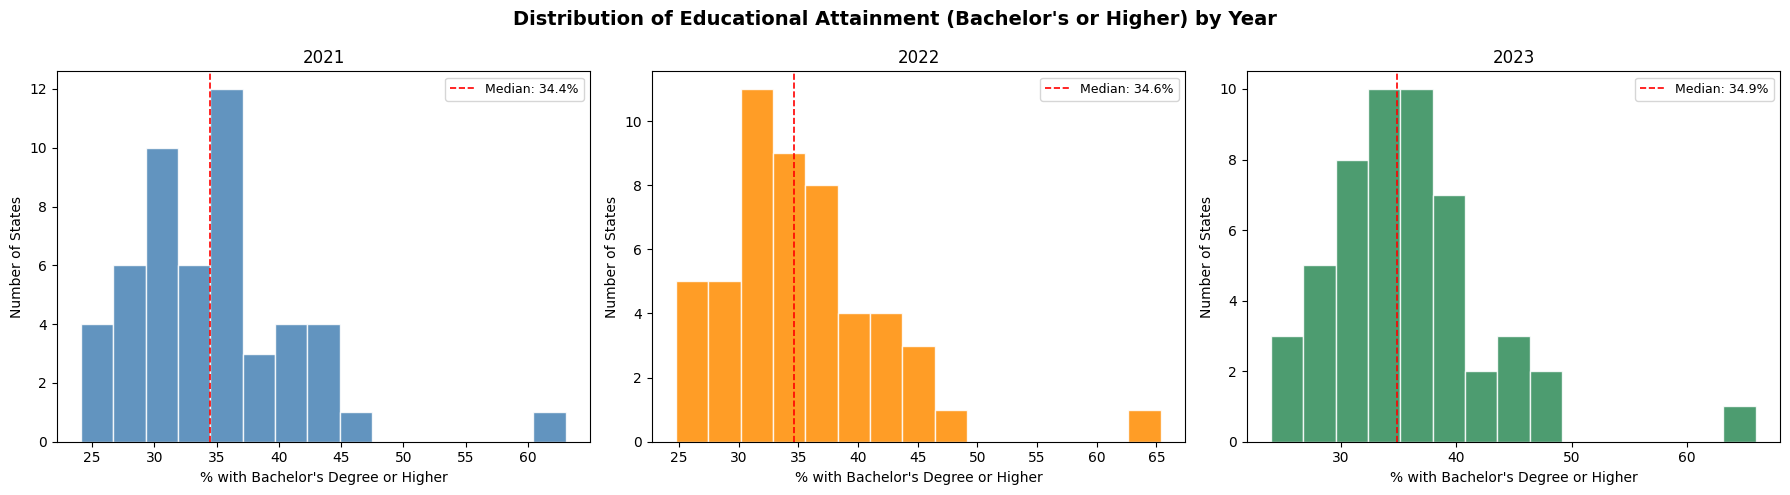

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribution of Educational Attainment (Bachelor's or Higher) by Year", fontsize=14, fontweight='bold')

colors = ['steelblue', 'darkorange', 'seagreen']

for ax, (year, color) in zip(axes, zip([2021, 2022, 2023], colors)):
    df_year = df_education.reset_index()
    df_year = df_year[df_year['Year'] == year].copy()
    df_year['Pct_Bachelors_Higher'] = (
        (df_year['Bachelors_Degree'] + df_year['Graduate_or_Professional'])
        / df_year['Total_Pop_Over_25'] * 100
    )

    subset = df_year['Pct_Bachelors_Higher'].dropna()

    ax.hist(subset, bins=15, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{year}', fontsize=12)
    ax.set_xlabel("% with Bachelor's Degree or Higher", fontsize=10)
    ax.set_ylabel('Number of States', fontsize=10)
    ax.axvline(subset.median(), color='red', linestyle='--', linewidth=1.2,
               label=f'Median: {subset.median():.1f}%')
    ax.legend(fontsize=9)
    ax.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
for year in [2021, 2022, 2023]:
    df_year = df_education.reset_index()
    df_year = df_year[df_year['Year'] == year].copy()
    df_year['Pct_Bachelors_Higher'] = (
        (df_year['Bachelors_Degree'] + df_year['Graduate_or_Professional'])
        / df_year['Total_Pop_Over_25'] * 100
    )

    max_idx = df_year['Pct_Bachelors_Higher'].idxmax()
    min_idx = df_year['Pct_Bachelors_Higher'].idxmin()

    print(f"--- {year} ---")
    print(f"  Highest: {df_year.loc[max_idx, 'State_Name']} ({df_year.loc[max_idx, 'Pct_Bachelors_Higher']:.2f}%)")
    print(f"  Lowest:  {df_year.loc[min_idx, 'State_Name']} ({df_year.loc[min_idx, 'Pct_Bachelors_Higher']:.2f}%)")
    print(f"  Median:  {df_year['Pct_Bachelors_Higher'].median():.2f}%\n")

--- 2021 ---
  Highest: District of Columbia (63.05%)
  Lowest:  West Virginia (24.12%)
  Median:  34.45%

--- 2022 ---
  Highest: District of Columbia (65.37%)
  Lowest:  Mississippi (24.76%)
  Median:  34.60%

--- 2023 ---
  Highest: District of Columbia (65.94%)
  Lowest:  West Virginia (23.99%)
  Median:  34.92%



We conducted value distribution profiling to examine the spread of educational attainment across states. From this analysis, the histogram shows the distribution of the percentage of the population with at least a bachelor’s degree across US states. Most states cluster between approximately 28% and 40%, indicating moderate variation in educational attainment across the majority of states. This spread suggests that the dataset captures sufficient variability to support comparative analysis with state-level crime rates. Additionally, we identified a clear outlier: the state with the highest percentage of individuals holding a bachelor’s degree or higher is the District of Columbia (~65%). As a result, special consideration is required when deciding whether to include this observation or to analyze it separately.

### Uniqueness for key discovery and functional dependency discovery

In [ ]:
df_profile = df_education.reset_index()

edu_cols = [
    'Total_Pop_Over_25',
    'Less_Than_HS',
    'High_School_Grad',
    'Some_College_or_Associates',
    'Bachelors_Degree',
    'Graduate_or_Professional'
]

# --- Check 1: Duplicate (State_Name, Year) combinations ---
duplicates = df_profile[df_profile.duplicated(subset=['State_Name', 'Year'], keep=False)]

print("=== FD Validation: (State_Name, Year) → Education Columns ===\n")
print(f"Total Records        : {len(df_profile)}")
print(f"Unique (State, Year) : {df_profile[['State_Name', 'Year']].drop_duplicates().shape[0]}")
print(f"Duplicate Keys Found : {len(duplicates)}")

if duplicates.empty:
    print("\n✓ No duplicate (State_Name, Year) keys — key uniqueness confirmed.")
else:
    print("\n Duplicate keys found — FD may be violated!")
    print(duplicates[['State_Name', 'Year'] + edu_cols].sort_values(['State_Name', 'Year']))

# --- Check 2: For any duplicate keys, do the values conflict? ---
print("\n=== Check 2: Value Consistency for Same Key ===")
conflicts = (
    df_profile.groupby(['State_Name', 'Year'])[edu_cols]
    .nunique()
    .gt(1)
    .any(axis=1)
)

conflicting_keys = conflicts[conflicts].index
if conflicting_keys.empty:
    print("✓ No conflicting values for any (State_Name, Year) pair.")
else:
    print(f"X {len(conflicting_keys)} key(s) have conflicting values:\n")
    for state, year in conflicting_keys:
        print(f"  {state} - {year}")
        print(df_profile[(df_profile['State_Name'] == state) &
                         (df_profile['Year'] == year)][['State_Name', 'Year'] + edu_cols])

# --- Verdict ---
print("\n=== Verdict ===")
if duplicates.empty and conflicting_keys.empty:
    print("✓ FD (State_Name, Year) → {Education Columns} is VALID.")
    print("   Each (State_Name, Year) pair uniquely determines all education attribute values.")
else:
    print("X FD is INVALID — duplicate or conflicting records exist.")

=== FD Validation: (State_Name, Year) → Education Columns ===

Total Records        : 260
Unique (State, Year) : 260
Duplicate Keys Found : 0

✓ No duplicate (State_Name, Year) keys — key uniqueness confirmed.

=== Check 2: Value Consistency for Same Key ===
✓ No conflicting values for any (State_Name, Year) pair.

=== Verdict ===
✓ FD (State_Name, Year) → {Education Columns} is VALID.
   Each (State_Name, Year) pair uniquely determines all education attribute values.


## Functional Dependency: `(State_Name, Year) → {Education Columns}`

**Status: Valid**

---

### What This Means
Every unique combination of `State_Name` and `Year` maps to exactly **one set** of education
attribute values. For example, *"California, 2021"* always maps to one unique set of population
and attainment figures — never conflicting or duplicated.

The full set of dependent attributes:
- `Total_Pop_Over_25`
- `Less_Than_HS`
- `High_School_Grad`
- `Some_College_or_Associates`
- `Bachelors_Degree`
- `Graduate_or_Professional`

---

### Validation Results

| Check | Result |
|---|---|
| Total Records | 260 |
| Unique `(State_Name, Year)` pairs | 260 |
| Duplicate keys | 0 |
| Conflicting values | 0 |

The fact that **Total Records = Unique (State_Name, Year) pairs = 260** is the strongest
confirmation — every row in the dataset is uniquely identified by its state and year combination.

---

### Why It Holds
Education attainment figures are **surveyed and reported per state per year** by the U.S.
Census Bureau (ACS). Each state receives exactly one set of estimates per survey year,
making `(State_Name, Year)` a **natural composite key** for this dataset.

The 260 records align with **52 states/territories × 5 years** (with some records missing
for certain years as identified in the null analysis), confirming no accidental duplication
occurred during data collection or merging.

---

### Data quality considerations

We highlight the following quality criteria that were assessed (among others) to determine the suitability of the dataset for the analytical task:

- Completeness: Mostly covers all US states for 2019, 2021, 2022, 2023 and 2024, excluding 2020 due to pandemic-related data collection gaps. No missing values in critical fields despite 5 null values in the numeric columns, specifically associated with Puerto Rico.
* **Uniqueness and Integrity:** Zero duplicate state-year combinations were found, and the composite key "(state_name, year)" was confirmed as unique. The functional dependency holds without violations across all years, confirming structural consistency in the dataset.

- Interpretability: Variables are simple, raw counts of individuals across five distinct education levels with low risk of misinterpretation. We can easily transform these raw counts into percentages to allow for fair, state-to-state comparisons against other metrics like crime or unemployment rates.

- Provenance: Despite US States Census Bureau being generally considered a credible source, source documentation is limited, with unclear details on collection methodology and quality checks, presenting a potential accuracy risk.

- Suitability: Despite provenance concerns, the dataset’s coverage and clarity make it fit for purpose, with the caveat that findings depend on data accuracy.

Despite these limitations, the dataset aligns well with the analytical requirements of this project and was therefore selected for use. Nevertheless, we acknowledge that any inaccuracies in the educational attainment data may influence the results of subsequent analyses and models.

### Conclusion for U.S. Census dataset

In conclusion, the U.S. Census education dataset is highly suitable for this project, provided that specific data cleaning steps are taken. It offers authoritative, multi-year snapshots that align with standard economic reporting. If selected for final use, the analyst must take note of two critical actions: first, filtering out Puerto Rico to resolve missing value issues, and second, deciding on a treatment for D.C. to ensure that its outlier status does not invalidate the correlations drawn for the 50 traditional states.

## **USDA ERS - County-Level Data Sets**

The dataset, downloaded from the U.S. Department of Agriculture's Economic Research Service (ERS) county-level data sets on February 13, 2026, includes annual Civilian labor force, Employed, Unemployed, and Unemployment rate figures from 2000 through 2023 (with some entries extending into 2023 as shown). It covers the United States as a whole, all states, and individual counties (including municipios in Puerto Rico), with FIPS codes, state abbreviations, and area names for precise geographic identification and aggregation at national, state, or county levels. This level of geographic granularity and long time series is well-suited for longitudinal trend analysis, regional comparisons, and integration with other socioeconomic or demographic datasets at matching geographic resolutions. The following code imports the data into a DataFrame and provides an overview of the structure and contents of the dataset.

In [ ]:
UMEMPLOYMENT_PATH = "/content/drive/MyDrive/Unemployment2023.csv"
df = pd.read_csv(UMEMPLOYMENT_PATH)
#df = pd.read_csv("Unemployment2023.csv")
# Preview the data
df

,FIPS_Code,State,Area_Name,Attribute,Value
0,0,US,United States,Civilian_labor_force_2000,142601576.0
1,0,US,United States,Employed_2000,136904853.0
2,0,US,United States,Unemployed_2000,5696723.0
3,0,US,United States,Unemployment_rate_2000,4.0
4,0,US,United States,Civilian_labor_force_2001,143786537.0
...,...,...,...,...,...
329721,72153,PR,"Yauco Municipio, PR",Unemployment_rate_2022,10.3
329722,72153,PR,"Yauco Municipio, PR",Civilian_labor_force_2023,10488.0
329723,72153,PR,"Yauco Municipio, PR",Employed_2023,9278.0
329724,72153,PR,"Yauco Municipio, PR",Unemployed_2023,1210.0


Looking at this dataset,  We also observe that the Area_Name field is redundant for our analytical purposes, as we are comparing across states rather than named areas, and this field requires cleaning to ensure consistent state-level identification. Furthermore, the FIPS_Code structure presents a data integrity challenge, as the numeric codes reset approximately every 1,000 entries, which could lead to misidentification if not properly normalized during the data preparation phase. However, we observe that for each of the states covered, the labor force characteristics are represented through multiple related attributes, civilian labor force, employed, unemployed, and unemployment rate, measured annually from 2000 to 2023. This would require further cleaning as the main statistic we are analysing is the unemployment rate. The combination of absolute counts and percentage rates provides comprehensive coverage of employment conditions but requires careful selection when integrating with other datasets, such as economic indicators or demographic statistics, which may use different base years or geographic classifications. The geographic granularity spanning national, state, and territorial levels is well-suited for our analysis, though the inclusion of Puerto Rico introduces important considerations for consistent cross-jurisdictional comparison.

After analysing the dataset, we can define a **functional dependency** as follows:

$$(\text{State_Name}, \text{Attribute}) \rightarrow \text{Value}$$

### Cardinality Profiling & Dataset Coverage Assessment
Exploring the states and date range covered in the dataset

- Enumeration and count of unique `State_Name` values (to confirm U.S. state/territory coverage)
- Record distribution across years

In [ ]:
df = pd.read_csv(UMEMPLOYMENT_PATH)
#df = pd.read_csv("Unemployment2023.csv")
# Filter for state-level data
df_states = df[(df['FIPS_Code'] % 1000 == 0)]

# Get unique states
states = sorted(df_states['State'].unique())

# Extract date range from Attribute column
years = set()
for attr in df['Attribute'].unique():
    match = re.search(r'_(\d{4})$', attr)
    if match:
        years.add(int(match.group(1)))

years_sorted = sorted(years)
date_range = f"{min(years_sorted)}-{max(years_sorted)}" if years_sorted else "N/A"

print(f"Number of States: {len(states)}")
print(f"Date Range: {date_range}")
print(f"States: {states}")


Number of States: 53
Date Range: 2000-2023
States: ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'US', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']


Examining the state and date coverage, we observe a total of 53 entries, which exceeds the expected 50 states. One entry represents the entire United States, likely capturing national aggregates rather than state-level data; this record can be removed during cleaning, as our analysis focuses on subnational comparisons. Additionally, the District of Columbia is included despite its status as a federal district rather than a state, warranting careful consideration regarding its inclusion in comparative analyses. Puerto Rico (PR), an unincorporated territory of the United States, is also present and requires similar deliberation on whether to retain or exclude it from the final dataset.

The dataset covers 24 years of data which is a broad coverage with respect to our analysis

#### Next, we analyse the number of null/missing values for unemployment rate for each state from 2018 - 2023 ####

In [ ]:
df = pd.read_csv(UMEMPLOYMENT_PATH)
#df = pd.read_csv("Unemployment2023.csv")
# Filter for state-level data excluding
df_states = df[(df['FIPS_Code'] % 1000 == 0)]

# Filter for unemployment rate attributes 2018-2023
unemp_cols = [f'Unemployment_rate_{year}' for year in range(2018, 2024)]
df_unemp = df_states[df_states['Attribute'].isin(unemp_cols)].copy()

# Pivot to get states as rows, years as columns
df_pivot = df_unemp.pivot_table(index='State', columns='Attribute', values='Value', aggfunc='first')

# Rename columns to just the year for readability
df_pivot.columns = [col.split('_')[-1] for col in df_pivot.columns]
df_pivot.columns.name = None

# Add null count summary column
df_pivot['Missing_Years'] = df_pivot.isnull().sum(axis=1)

# Replace NaN with 'X' and actual values with '✓' for the availability view
df_availability = df_pivot.drop(columns='Missing_Years').copy()
df_availability = df_availability.map(lambda x: 'X' if pd.isnull(x) else '✓')
df_availability['Missing_Count'] = df_pivot['Missing_Years']
df_availability['Status'] = df_availability['Missing_Count'].map(
    lambda x: 'Complete' if x == 0 else f'{x} year(s) missing'
)

print("=== Unemployment Rate Data Availability by State (2018-2023) ===\n")
print(df_availability.to_string())

print("\n=== Summary ===")
print(f"  Total States       : {len(df_pivot)}")
print(f"  Complete States    : {(df_pivot['Missing_Years'] == 0).sum()}")
print(f"  Incomplete States  : {(df_pivot['Missing_Years'] > 0).sum()}")
print(f"  Total Missing Vals : {df_pivot['Missing_Years'].sum()}")

# Show only incomplete states if any
incomplete = df_availability[df_availability['Missing_Count'] > 0]
if not incomplete.empty:
    print("\n=== States with Missing Data ===\n")
    print(incomplete.to_string())

=== Unemployment Rate Data Availability by State (2018-2023) ===

      2018 2019 2020 2021 2022 2023  Missing_Count             Status
State                                                                
AK       ✓    ✓    ✓    ✓    ✓    ✓              0           Complete
AL       ✓    ✓    ✓    ✓    ✓    ✓              0           Complete
AR       ✓    ✓    ✓    ✓    ✓    ✓              0           Complete
AZ       ✓    ✓    ✓    ✓    ✓    ✓              0           Complete
CA       ✓    ✓    ✓    ✓    ✓    ✓              0           Complete
CO       ✓    ✓    ✓    ✓    ✓    ✓              0           Complete
CT       ✓    ✓    ✓    ✓    ✓    ✓              0           Complete
DC       ✓    ✓    ✓    ✓    ✓    ✓              0           Complete
DE       ✓    ✓    ✓    ✓    ✓    ✓              0           Complete
FL       ✓    ✓    ✓    ✓    ✓    ✓              0           Complete
GA       ✓    ✓    ✓    ✓    ✓    ✓              0           Complete
HI       ✓    ✓    ✓    

Overall, after filtering the dataset from 2018 onwards, the dataset is highly complete with only 1 null value out of 312 (99.68% non-null), with essentially full coverage across the U.S. states, across all 6 years wtih only a single isolated missing value in Puerto Rico. This minimal level of missingness should have negligible impact on most state-level or national analyses, though the specific missing attribute for PR should be noted (and potentially imputed or excluded) when conducting Puerto Rico-specific or cross-territory comparisons. The data appears clean and reliable for exploratory data analysis (EDA), especially when paired with other state- or county-level datasets like crime statistics.

### Checking value distributions

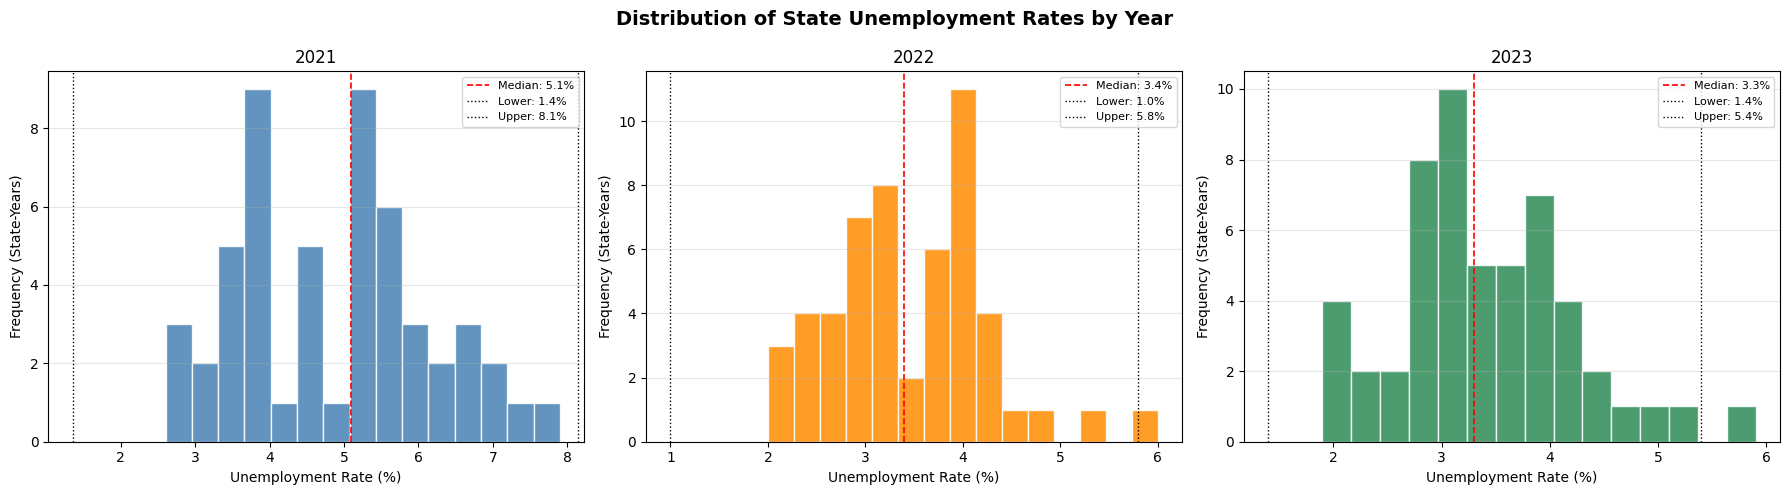

--- 2021 ---
  Records Analyzed : 53
  Lower Bound      : 1.35%
  Upper Bound      : 8.15%
  Outliers Found   : 0

--- 2022 ---
  Records Analyzed : 53
  Lower Bound      : 1.00%
  Upper Bound      : 5.80%
  Outliers Found   : 1
State   Area_Name  Value
   PR Puerto Rico    6.0

--- 2023 ---
  Records Analyzed : 53
  Lower Bound      : 1.40%
  Upper Bound      : 5.40%
  Outliers Found   : 1
State   Area_Name  Value
   PR Puerto Rico    5.9



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribution of State Unemployment Rates by Year", fontsize=14, fontweight='bold')

colors = ['steelblue', 'darkorange', 'seagreen']

for ax, (year, color) in zip(axes, zip([2021, 2022, 2023], colors)):
    subset = df_unemp[df_unemp['Attribute'] == f'Unemployment_rate_{year}']['Value'].dropna()

    Q1, Q3 = subset.quantile(0.25), subset.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    ax.hist(subset, bins=15, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{year}', fontsize=12)
    ax.set_xlabel('Unemployment Rate (%)', fontsize=10)
    ax.set_ylabel('Frequency (State-Years)', fontsize=10)
    ax.axvline(subset.median(), color='red', linestyle='--', linewidth=1.2,
               label=f'Median: {subset.median():.1f}%')
    ax.axvline(lower, color='black', linestyle=':', linewidth=1,
               label=f'Lower: {lower:.1f}%')
    ax.axvline(upper, color='black', linestyle=':', linewidth=1,
               label=f'Upper: {upper:.1f}%')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --- Detect Outliers per Year (2021-2023) ---
for year in [2021, 2022, 2023]:
    subset = df_unemp[df_unemp['Attribute'] == f'Unemployment_rate_{year}'].copy()
    subset['Value'] = pd.to_numeric(subset['Value'], errors='coerce')
    subset = subset.dropna(subset=['Value'])

    Q1, Q3 = subset['Value'].quantile(0.25), subset['Value'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = subset[(subset['Value'] < lower_bound) | (subset['Value'] > upper_bound)]

    print(f"--- {year} ---")
    print(f"  Records Analyzed : {len(subset)}")
    print(f"  Lower Bound      : {lower_bound:.2f}%")
    print(f"  Upper Bound      : {upper_bound:.2f}%")
    print(f"  Outliers Found   : {len(outliers)}")

    if not outliers.empty:
        print(outliers[['State', 'Area_Name', 'Value']].sort_values('Value', ascending=False).to_string(index=False))
    print()

Outlier detection was performed on the unemployment rate values using IQR for each year separately.

- In 2021: Analyzed 53 records, lower bound 1.35%, upper bound 8.15% → **0 outliers**.
- In 2022: Analyzed 53 records, lower bound 1.00%, upper bound 5.80% → **1 outlier**: Puerto Rico (PR) at 6.0%.
- In 2023: Analyzed 53 records, lower bound 1.40%, upper bound 5.40% → **1 outlier**: Puerto Rico (PR) at 5.9%.

Key observations from the outliers:

- Puerto Rico consistently shows the highest unemployment rate among all states and territories in this period, with annual averages of ~6.0% in 2022 and ~5.9% in 2023 (per BLS and FRED data). This reflects PR's structurally higher unemployment baseline compared to the mainland U.S., influenced by ongoing economic challenges, limited federal integration in some programs, slower recovery dynamics, and reliance on sectors sensitive to external shocks.
- No widespread outliers appear in these years. Most states/areas stayed within tight IQR bounds, reflecting a relatively uniform labor market recovery across the U.S. by 2022–2023.

As a result, special consideration is recommended when deciding whether to include Puerto Rico observations in aggregate mainland-focused analyses or to treat it separately (e.g., as a distinct territory group or in subgroup reporting), since its rates are systematically higher and frequently appear as statistical outliers relative to the other 52 areas.

### FD Validation: (State, Attribute) → Value

In [ ]:
print("=== FD Validation: (State, Attribute) → Value ===\n")

# --- Check 1: Duplicate (State, Attribute) keys ---
dup_mask = df_unemp.duplicated(subset=['State', 'Attribute'], keep=False)
duplicates = df_unemp[dup_mask].sort_values(['State', 'Attribute'])

print(f"Total Records           : {len(df_unemp)}")
print(f"Unique (State, Attr)    : {df_unemp[['State', 'Attribute']].drop_duplicates().shape[0]}")
print(f"Duplicate Keys Found    : {len(duplicates)}")

if duplicates.empty:
    print("\n✓ No duplicate (State, Attribute) keys — key uniqueness confirmed.")
else:
    print("\nX Duplicate keys found — FD may be violated!")
    print(duplicates[['State', 'Attribute', 'Value']].to_string(index=False))

# --- Check 2: Conflicting values for same (State, Attribute) key ---
print("\n=== Check 2: Value Consistency for Same Key ===")
conflicts = (
    df_unemp.groupby(['State', 'Attribute'])['Value']
    .nunique()
    .gt(1)
)
conflicting_keys = conflicts[conflicts].index

if conflicting_keys.empty:
    print("✓ No conflicting values for any (State, Attribute) pair.")
else:
    print(f"X {len(conflicting_keys)} key(s) have conflicting values:\n")
    for state, attr in conflicting_keys:
        print(f"  {state} — {attr}")
        print(df_unemp[(df_unemp['State'] == state) &
                       (df_unemp['Attribute'] == attr)][['State', 'Attribute', 'Value']]
                       .to_string(index=False))

# --- Check 3: Data type validation ---
print("\n=== Check 3: Numeric Value Validation ===")
df_unemp['Value_num'] = pd.to_numeric(df_unemp['Value'], errors='coerce')
non_numeric = df_unemp[df_unemp['Value_num'].isna()][['State', 'Attribute', 'Value']]

print(f"Non-numeric Value rows  : {len(non_numeric)}")
if not non_numeric.empty:
    print(non_numeric.head(10).to_string(index=False))
else:
    print("✓ All Value entries are numeric.")

# --- Verdict ---
print("\n=== Verdict ===")
if duplicates.empty and conflicting_keys.empty:
    print(" FD (State, Attribute) → Value is VALID.")
    print("   Each (State, Attribute) pair uniquely determines its Value.")
else:
    print("X FD is INVALID — duplicate or conflicting records exist.")

=== FD Validation: (State, Attribute) → Value ===

Total Records           : 317
Unique (State, Attr)    : 317
Duplicate Keys Found    : 0

✓ No duplicate (State, Attribute) keys — key uniqueness confirmed.

=== Check 2: Value Consistency for Same Key ===
✓ No conflicting values for any (State, Attribute) pair.

=== Check 3: Numeric Value Validation ===
Non-numeric Value rows  : 0
✓ All Value entries are numeric.

=== Verdict ===
 FD (State, Attribute) → Value is VALID.
   Each (State, Attribute) pair uniquely determines its Value.


Further analysis show that there were no duplicates, formatting, or uniqueness issues. All unemployment rate entries are properly formatted as numeric values (or can be coerced to numeric without error), with no text, blanks, or invalid characters present. Additionally, $$(\text{State_Name}, \text{Attribute}) \rightarrow \text{Value}$$

is a valid FD

###Data quality considerations
We highlight the following key quality criteria assessed to determine the dataset's suitability for the analytical task:

- Completeness: Near-perfect coverage across 52 entities (50 states + DC + Puerto Rico) with 6 labor indicators each; only 1 missing value in Puerto Rico (~0.32% of expected points)
* Uniqueness and Integrity: Zero duplicate state-attribute combinations were found, and the composite key "(state_name, attribute)" was confirmed as unique. The functional dependency holds without violations across all years, confirming structural consistency in the dataset.
- Suitability: Excellent for EDA, trend analysis, cross-state comparisons, and integration with datasets like crime statistics due to multi-level geography, 2000–2023 coverage, standardized metrics, and minimal issues. The 2020 outliers represent a meaningful structural break that can be handled via modeling adjustments (e.g., period indicators).

Despite a trivial completeness gap in Puerto Rico, the dataset is highly reliable and well-aligned with project needs. These minor limitations are unlikely to meaningfully affect state-level findings or socioeconomic correlations.

## **Profiling US Population Race Demographic by State**


The dataset is from the KFF, formerly the Kaiser Family Foundation, contains **10 columns**, covers 1 year with **70 records per year**, representing the entire U.S., all 50 U.S. states and Puerto Rico. The **unique key** of the table is the **"Location"** column which refers to which state the record belongs to. We are only interested in the records of the 50 states.

To run the code please download the files under Population Demographic Data Sources in the data souces tabble and save them in Google Drive under MyDrive as 2023_race, 2022_race, 2021_race respectively.

**Missing Values**
In the dataset, for the recrrds which we are interested in, there are null values in some of the columns except for the "Location". This is expected as in the U.S., not all states have people from every racial demographic. The fix for this would be to populate the null values with 0.

**State Coverage**
The dataset covers all 50 U.S. states and Puerto Rico (51 entities total), with no missing state abbreviations detected. Coverage is consistent across all other years, confirming balanced panel structure.

**Duplicate Check**
Upon initial inspection, no duplicate states were found, meaning each of the 50 U.S. states have their own unique rows.

Since the data for the different years are in different datasets, we will need to check each dataset of each year like before to ensure consistency.

In [ ]:
df_raw_popn_demographic_2023 = pd.read_csv('/content/drive/MyDrive/2023_race.csv', skiprows=2)
"""
from google.colab import files
uploaded = files.upload()
df_raw_popn_demographic_2023 = pd.read_csv("2023_race.csv", skiprows = 2)
df_raw_popn_demographic_2023
"""
#check for any issues with the data
print(f"Dataset shape: {df_raw_popn_demographic_2023.shape}")

print("\nMissing Values Summary:")
print(df_raw_popn_demographic_2023.isnull().sum())
print("\nDuplicated Rows Summary:")
df_raw_popn_demographic_2023[df_raw_popn_demographic_2023['Location'].duplicated()]

Dataset shape: (70, 10)

Missing Values Summary:
Location                                4
White                                  17
Black                                  17
Hispanic                               17
Asian                                  18
American Indian or Alaska Native       24
Native Hawaiian or Pacific Islander    51
Multiple Races                         17
Total                                  17
Footnotes                              69
dtype: int64

Duplicated Rows Summary:


,Location,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Total,Footnotes
57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_raw_popn_demographic_2023

,Location,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Total,Footnotes
0,United States,0.572,0.116,0.195,0.059,0.005,0.002,0.050,1.0,1.0
1,Alabama,0.636,0.250,0.058,0.016,0.003,NaN,0.038,1.0,NaN
2,Alaska,0.574,0.023,0.074,0.061,0.141,0.014,0.112,1.0,NaN
3,Arizona,0.523,0.044,0.317,0.035,0.031,0.002,0.048,1.0,NaN
4,Arkansas,0.673,0.141,0.092,0.017,0.004,0.004,0.070,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...
65,*N/A*: Estimates with relative standard errors...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,Persons of Hispanic origin may be of any race;...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,Footnotes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We drop the "Footnotes" column as it does not contain relevant information that we want. We also slice the table so as to extract out the relevant rows, which are the rows that give us the population demographic of each state.

In [ ]:
#want the first 53 rows
df_popn_demo_23 = df_raw_popn_demographic_2023.iloc[1:52]
df_popn_demo_23 = df_popn_demo_23.drop(columns=["Footnotes"])
df_popn_demo_23

,Location,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Total
1,Alabama,0.636,0.250,0.058,0.016,0.003,NaN,0.038,1.0
2,Alaska,0.574,0.023,0.074,0.061,0.141,0.014,0.112,1.0
3,Arizona,0.523,0.044,0.317,0.035,0.031,0.002,0.048,1.0
4,Arkansas,0.673,0.141,0.092,0.017,0.004,0.004,0.070,1.0
5,California,0.333,0.050,0.406,0.156,0.003,0.003,0.050,1.0
6,Colorado,0.647,0.036,0.227,0.032,0.003,0.001,0.053,1.0
7,Connecticut,0.614,0.098,0.187,0.047,0.001,NaN,0.052,1.0
8,Delaware,0.582,0.213,0.111,0.043,0.001,NaN,0.051,1.0
9,District of Columbia,0.367,0.409,0.123,0.038,NaN,NaN,0.063,1.0
10,Florida,0.503,0.142,0.276,0.029,0.001,0.001,0.049,1.0


Check if "Location" column can be out key. To be a key, it must be unique for all rows and but not be NULL.

In [ ]:
df_popn_demo_23['Location'].is_unique and df_popn_demo_23['Location'].notna().all()

np.True_

In [ ]:
#check that the total for each row is still 1
df_popn_demo_23_checker = df_popn_demo_23
df_popn_demo_23_checker['total_checker'] = df_popn_demo_23_checker.iloc[:, 1:8].sum(axis=1)
df_popn_demo_23_checker[df_popn_demo_23_checker['total_checker'] != 1].sort_values(by='total_checker', ascending=True)

,Location,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Total,total_checker
30,New Hampshire,0.865,0.012,0.045,0.026,NaN,NaN,0.049,1.0,0.997
17,Kansas,0.730,0.048,0.137,0.026,0.004,NaN,0.053,1.0,0.998
46,Vermont,0.892,0.013,0.024,0.016,NaN,NaN,0.053,1.0,0.998
40,Rhode Island,0.676,0.046,0.182,0.032,NaN,NaN,0.062,1.0,0.998
41,South Carolina,0.620,0.240,0.074,0.017,0.002,NaN,0.046,1.0,0.999
2,Alaska,0.574,0.023,0.074,0.061,0.141,0.014,0.112,1.0,0.999
15,Indiana,0.752,0.087,0.088,0.026,0.001,NaN,0.045,1.0,0.999
6,Colorado,0.647,0.036,0.227,0.032,0.003,0.001,0.053,1.0,0.999
24,Minnesota,0.757,0.068,0.064,0.052,0.006,NaN,0.052,1.0,0.999
36,Ohio,0.758,0.117,0.048,0.025,0.001,NaN,0.050,1.0,0.999


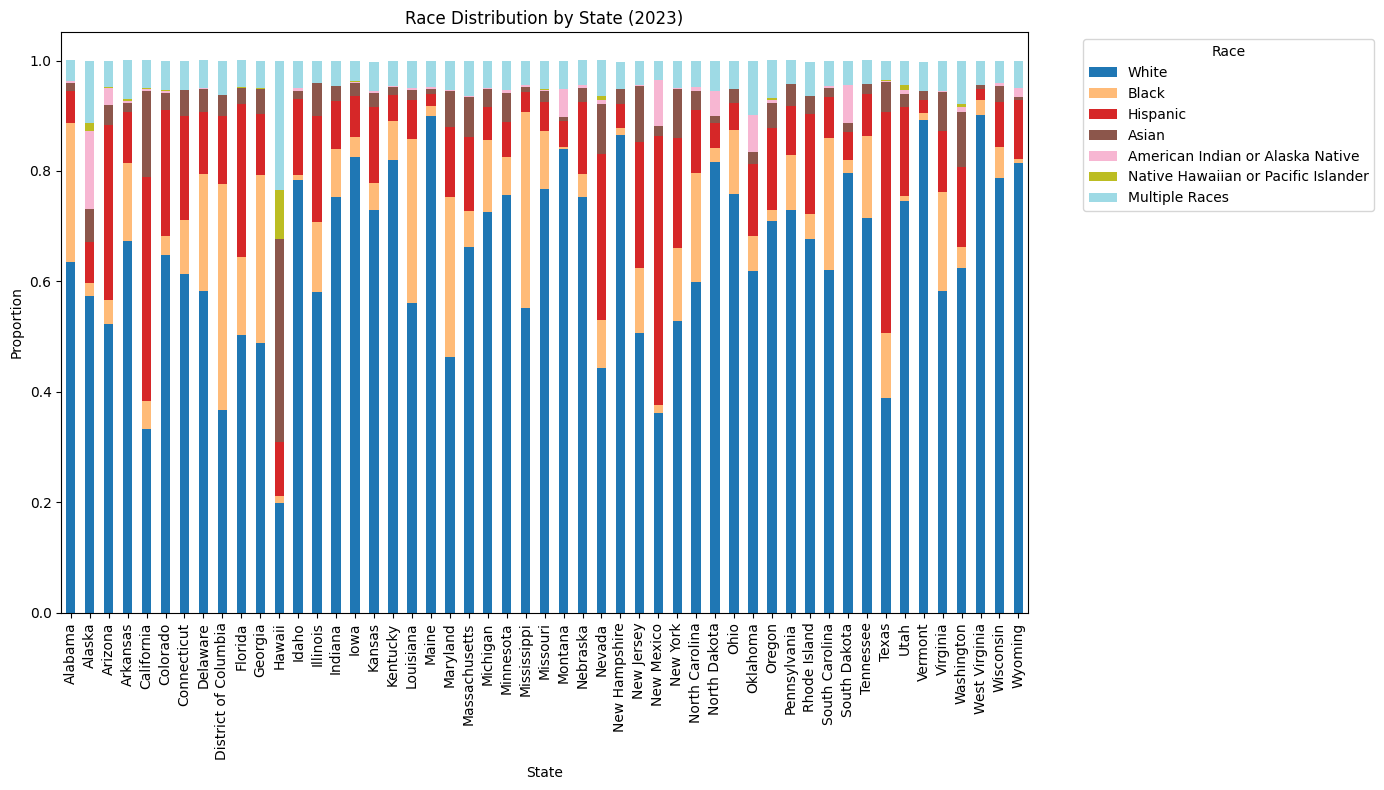

In [ ]:
race_cols = ['White', 'Black', 'Hispanic', 'Asian', 'American Indian or Alaska Native', 'Native Hawaiian or Pacific Islander', 'Multiple Races']
#set the index to the Location
df_popn_demo_23_plot = df_popn_demo_23.set_index('Location')
df_popn_demo_23_plot[race_cols].plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    colormap='tab20'
)

plt.title('Race Distribution by State (2023)')
plt.xlabel('State')
plt.ylabel('Proportion')
plt.legend(title='Race', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [ ]:
df_raw_popn_demographic_2022 = pd.read_csv('/content/drive/MyDrive/2022_race.csv', skiprows=2)
#df_raw_popn_demographic_2022 = pd.read_csv("2022_race.csv", skiprows = 2)
df_raw_popn_demographic_2021 = pd.read_csv('/content/drive/MyDrive/2021_race.csv', skiprows=2)
#df_raw_popn_demographic_2021 = pd.read_csv("2021_race.csv", skiprows=2)

In [ ]:
#check for 2022 dataset
print(f"Dataset shape: {df_raw_popn_demographic_2022.shape}")

print("\nMissing Values Summary:")
print(df_raw_popn_demographic_2022.isnull().sum())
print("\nDuplicated Rows Summary:")
df_raw_popn_demographic_2022[df_raw_popn_demographic_2022['Location'].duplicated()]

Dataset shape: (70, 10)

Missing Values Summary:
Location                                4
White                                  17
Black                                  17
Hispanic                               17
Asian                                  17
American Indian or Alaska Native       22
Native Hawaiian or Pacific Islander    45
Multiple Races                         17
Total                                  17
Footnotes                              69
dtype: int64

Duplicated Rows Summary:


,Location,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Total,Footnotes
57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_popn_demo_22 = df_raw_popn_demographic_2022.iloc[1:52]
df_popn_demo_22 = df_popn_demo_22.drop(columns=["Footnotes"])
df_popn_demo_22

,Location,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Total
1,Alabama,0.645,0.252,0.048,0.014,0.002,NaN,0.039,1.0
2,Alaska,0.577,0.028,0.073,0.061,0.128,0.016,0.116,1.0
3,Arizona,0.518,0.043,0.325,0.035,0.033,0.001,0.044,1.0
4,Arkansas,0.677,0.141,0.085,0.015,0.004,0.004,0.074,1.0
5,California,0.337,0.051,0.404,0.153,0.002,0.003,0.049,1.0
6,Colorado,0.650,0.036,0.226,0.031,0.004,0.001,0.052,1.0
7,Connecticut,0.620,0.097,0.183,0.047,0.001,NaN,0.052,1.0
8,Delaware,0.590,0.211,0.103,0.041,0.001,NaN,0.054,1.0
9,District of Columbia,0.363,0.422,0.119,0.039,NaN,NaN,0.055,1.0
10,Florida,0.508,0.144,0.273,0.028,0.001,0.000,0.046,1.0


In [ ]:
df_popn_demo_22['Location'].is_unique and df_popn_demo_22['Location'].notna().all()
print("\nCheck for row totals:")
df_popn_demo_22_checker = df_popn_demo_22
df_popn_demo_22_checker['total_checker'] = df_popn_demo_22_checker.iloc[:, 1:8].sum(axis=1)
df_popn_demo_22_checker[df_popn_demo_22_checker['total_checker'] != 1].sort_values(by='total_checker', ascending=True)


Check for row totals:


,Location,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Total,total_checker
42,South Dakota,0.801,0.019,0.046,0.014,0.072,NaN,0.045,1.0,0.997
35,North Dakota,0.828,0.026,0.044,0.012,0.039,NaN,0.048,1.0,0.997
9,District of Columbia,0.363,0.422,0.119,0.039,NaN,NaN,0.055,1.0,0.998
46,Vermont,0.904,0.008,0.022,0.015,NaN,NaN,0.049,1.0,0.998
40,Rhode Island,0.680,0.045,0.179,0.032,NaN,NaN,0.062,1.0,0.998
2,Alaska,0.577,0.028,0.073,0.061,0.128,0.016,0.116,1.0,0.999
34,North Carolina,0.609,0.200,0.104,0.031,0.008,0.001,0.046,1.0,0.999
37,Oklahoma,0.628,0.065,0.122,0.023,0.069,NaN,0.092,1.0,0.999
32,New Mexico,0.347,0.015,0.505,0.016,0.081,NaN,0.035,1.0,0.999
28,Nebraska,0.759,0.042,0.123,0.023,0.005,NaN,0.047,1.0,0.999


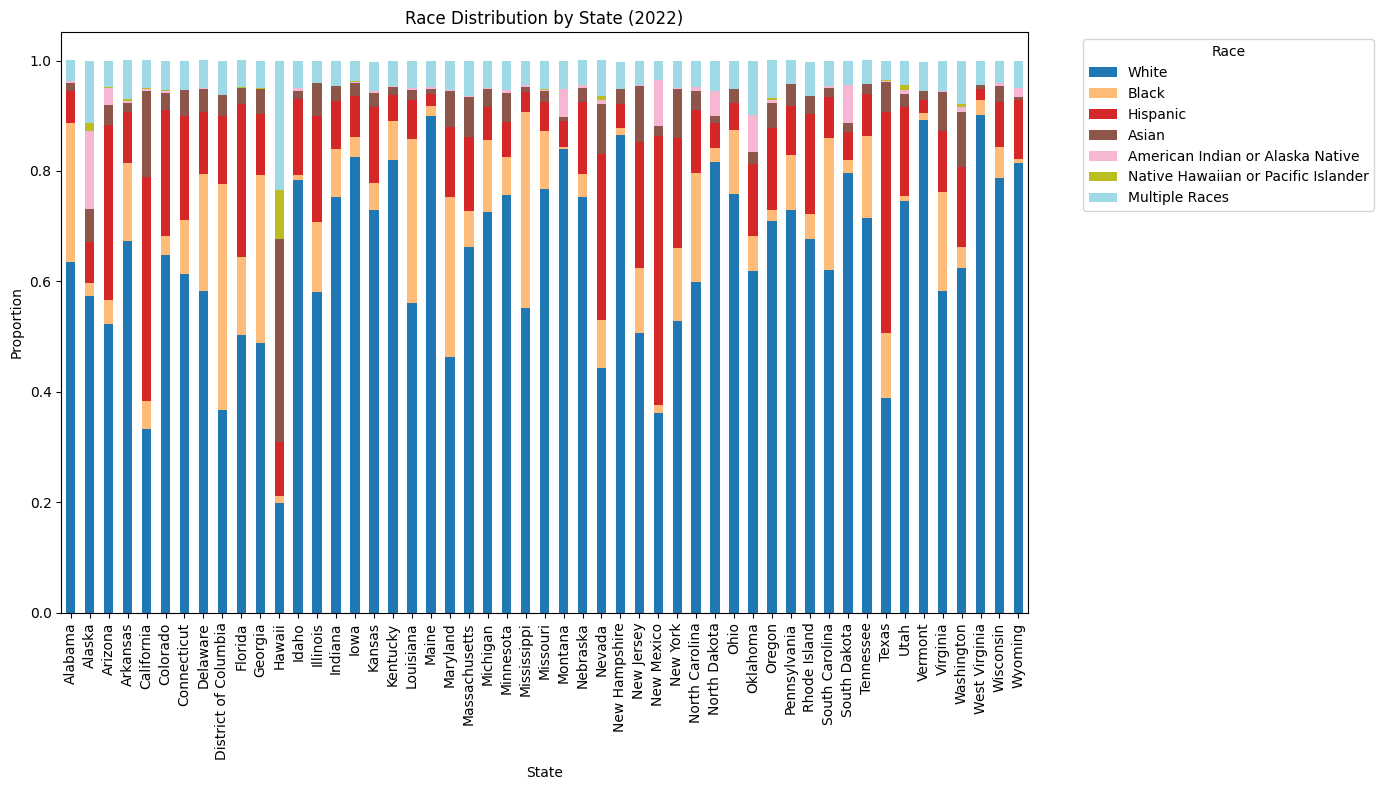

In [ ]:
df_popn_demo_22_plot = df_popn_demo_23.set_index('Location')
df_popn_demo_22_plot[race_cols].plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    colormap='tab20'
)

plt.title('Race Distribution by State (2022)')
plt.xlabel('State')
plt.ylabel('Proportion')
plt.legend(title='Race', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [ ]:
#check for 2021 dataset
print(f"Dataset shape: {df_raw_popn_demographic_2021.shape}")

print("\nMissing Values Summary:")
print(df_raw_popn_demographic_2021.isnull().sum())
print("\nDuplicated Rows Summary:")
df_raw_popn_demographic_2021[df_raw_popn_demographic_2021['Location'].duplicated()]

Dataset shape: (70, 10)

Missing Values Summary:
Location                                4
White                                  17
Black                                  17
Hispanic                               17
Asian                                  18
American Indian or Alaska Native       24
Native Hawaiian or Pacific Islander    44
Multiple Races                         17
Total                                  17
Footnotes                              69
dtype: int64

Duplicated Rows Summary:


,Location,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Total,Footnotes
57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_popn_demo_21 = df_raw_popn_demographic_2021.iloc[1:52]
df_popn_demo_21 = df_popn_demo_21.drop(columns=["Footnotes"])
df_popn_demo_21

,Location,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Total
1,Alabama,0.644,0.255,0.047,0.013,0.004,NaN,0.037,1.0
2,Alaska,0.579,0.026,0.067,0.070,0.138,0.015,0.105,1.0
3,Arizona,0.521,0.041,0.324,0.033,0.033,0.002,0.047,1.0
4,Arkansas,0.683,0.144,0.083,0.014,0.004,0.004,0.068,1.0
5,California,0.342,0.051,0.403,0.151,0.002,0.003,0.047,1.0
6,Colorado,0.653,0.036,0.222,0.031,0.003,0.002,0.053,1.0
7,Connecticut,0.628,0.097,0.178,0.047,0.001,NaN,0.049,1.0
8,Delaware,0.595,0.203,0.102,0.041,NaN,NaN,0.057,1.0
9,District of Columbia,0.359,0.431,0.115,0.038,NaN,NaN,0.055,1.0
10,Florida,0.512,0.144,0.270,0.028,0.001,0.000,0.046,1.0


In [ ]:
df_popn_demo_21['Location'].is_unique and df_popn_demo_21['Location'].notna().all()
print("\nCheck for row totals:")
df_popn_demo_21_checker = df_popn_demo_21
df_popn_demo_21_checker['total_checker'] = df_popn_demo_21_checker.iloc[:, 1:8].sum(axis=1)
df_popn_demo_21_checker[df_popn_demo_21_checker['total_checker'] != 1].sort_values(by='total_checker', ascending=True)


Check for row totals:


,Location,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Total,total_checker
35,North Dakota,0.827,0.029,0.039,0.014,0.043,NaN,0.044,1.0,0.996
40,Rhode Island,0.689,0.043,0.174,0.030,0.002,NaN,0.060,1.0,0.998
9,District of Columbia,0.359,0.431,0.115,0.038,NaN,NaN,0.055,1.0,0.998
8,Delaware,0.595,0.203,0.102,0.041,NaN,NaN,0.057,1.0,0.998
42,South Dakota,0.802,0.020,0.040,0.015,0.076,NaN,0.045,1.0,0.998
21,Maryland,0.481,0.286,0.111,0.068,0.001,0.000,0.052,1.0,0.999
12,Hawaii,0.196,0.013,0.109,0.375,NaN,0.097,0.209,1.0,0.999
15,Indiana,0.767,0.086,0.077,0.023,0.001,NaN,0.045,1.0,0.999
32,New Mexico,0.348,0.016,0.503,0.014,0.081,NaN,0.037,1.0,0.999
37,Oklahoma,0.629,0.065,0.119,0.023,0.069,0.001,0.093,1.0,0.999


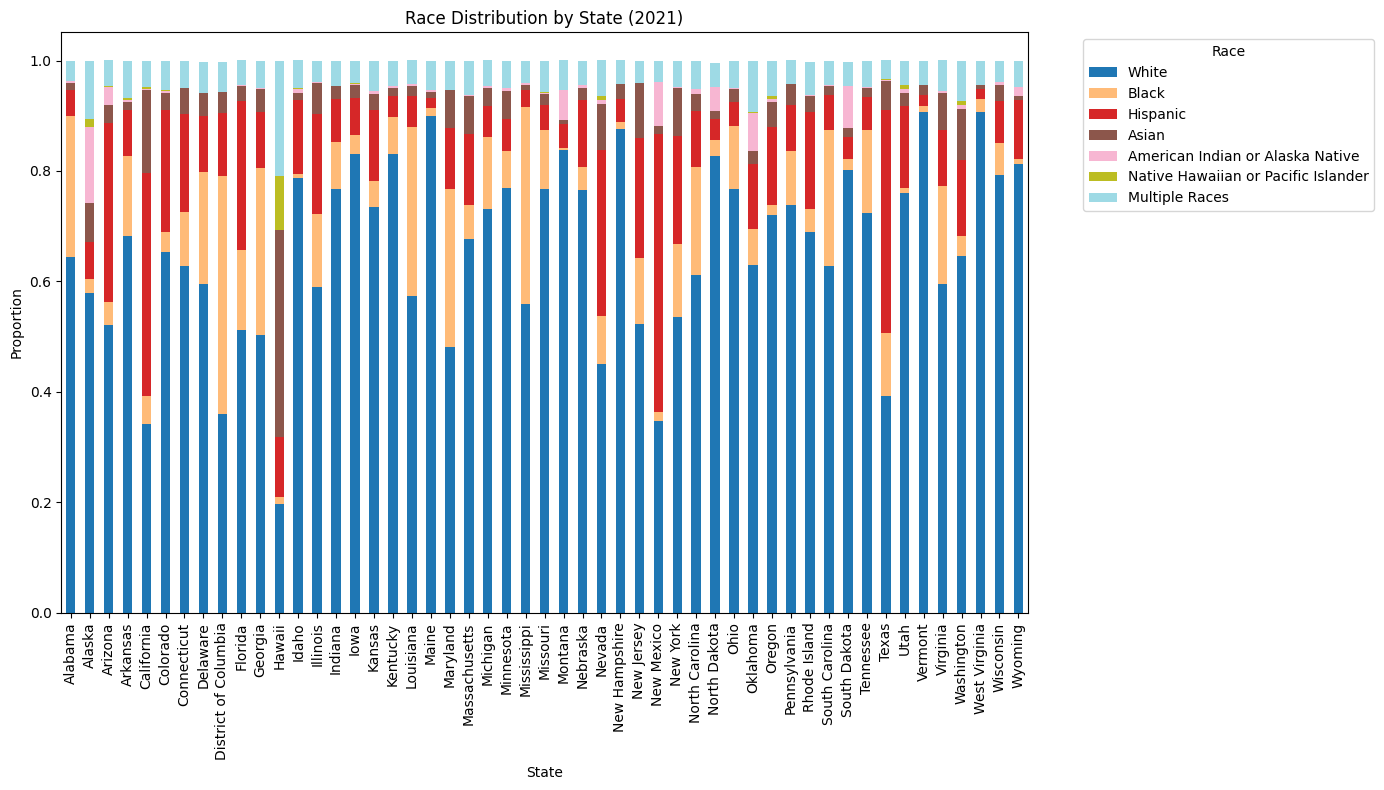

In [ ]:
df_popn_demo_21_plot = df_popn_demo_21.set_index('Location')
df_popn_demo_21_plot[race_cols].plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    colormap='tab20'
)

plt.title('Race Distribution by State (2021)')
plt.xlabel('State')
plt.ylabel('Proportion')
plt.legend(title='Race', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

###Data Quality Considerations

We highlight the following key quality criteria assessed to determine the dataset's suitability for the analytical task:

**Completeness**: Complete coverage across 51 entities (50 states + DC) with regards to the population dmeographics in each state. Majority of the states having a majority of those who are of the white race also aligns with what is known about the U.S. Each state's racial demographic also adds up to 1 which is expected as the values in each row are a percentage of the total population of each state. Each state's racial demographic adding up to 1 shows completeness where no race is accidentally left out or counted multiple times.

**Uniqueness and Integrity**: Zero duplicate states were found, the key "Location" was confirmed as unique.

**Suitability**: Excellent for EDA, trend analysis, cross-state comparisons, and integration with datasets like crime statistics due to multi-level geography, 2021–2023 coverage, standardized metrics, and minimal issues.
The dataset is highly reliable and well-aligned with project needs.

# **Data Preparation (Process)**

As part of data preparation, we executed a structured pipeline consisting of transformation, integration, and data structuring

### **Data Structuring of DS1**


### **Intrarecord (operations within a single row)**

## Reordering Attributes - Intrarecord
We reorder the columns into a more logical sequence, placing the key identifier columns (`year`, `state_name`) first, followed by the population and crime metrics. Additionally, rows are sorted first by year (2021 → 2022 → 2023) and then alphabetically by state name within each year. This improves readability and ensures that records are consistently ordered before any subsequent operations are applied.

In [ ]:
# Reorder columns into a logical sequence
crimes_df = crimes_df[['year', 'state_abbr', 'state_name', 'population',
         'violent_crime', 'violent_crime_rate_100k', '%violent_crime_100k']]

# Reorder rows by year first, then alphabetically by state
crimes_df = crimes_df.sort_values(['year', 'state_name']).reset_index(drop=True)

print("Reordered columns:")
print(crimes_df.columns.tolist())
print(f"\nFirst few rows (should start from 2021):")
crimes_df.head()

Reordered columns:
['year', 'state_abbr', 'state_name', 'population', 'violent_crime', 'violent_crime_rate_100k', '%violent_crime_100k']

First few rows (should start from 2021):


,year,state_abbr,state_name,population,violent_crime,violent_crime_rate_100k,%violent_crime_100k
0,2021,AL,Alabama,5049846,17590,348.327454,0.348327
1,2021,AK,Alaska,734182,5573,759.076087,0.759076
2,2021,AZ,Arizona,7264877,30922,425.636938,0.425637
3,2021,AR,Arkansas,3028122,21271,702.448580,0.702449
4,2021,CA,California,39142991,188343,481.166603,0.481167


### **Interrecord - Aggregation**

We aggregate the data across all three years (2021–2023) at the state level, collapsing the 3 rows per state into a single summary row per state. This produces four summary metrics for each state across the full period:

- `total_violent_crimes_2021_2023` — total number of violent crimes reported across all three years combined
- `avg_rate_per_100k_2021_2023` — average violent crime rate per 100K population across the three years, providing a stable, multi-year measure of a state's overall crime level
- `min_rate_per_100k_2021_2023` — the lowest rate recorded across the three years, indicating the state's best performing year
- `max_rate_per_100k_2021_2023` — the highest rate recorded across the three years, indicating the state's worst performing year

This aggregated view is particularly useful for ranking states by their overall violent crime levels over the 2021–2023 period, and for identifying states that experienced the greatest range between their best and worst year.

In [ ]:
# Aggregate per state across 2021-2023
agg_by_state = crimes_df.groupby(['state_abbr', 'state_name']).agg(
    total_violent_crimes_2021_2023 = ('violent_crime', 'sum'),
    avg_rate_per_100k_2021_2023    = ('violent_crime_rate_100k', 'mean'),
    min_rate_per_100k_2021_2023    = ('violent_crime_rate_100k', 'min'),
    max_rate_per_100k_2021_2023    = ('violent_crime_rate_100k', 'max'),
).round(2).reset_index()

print("--- Aggregated Statistics per State across 2021-2023 ---")
print(agg_by_state.sort_values('avg_rate_per_100k_2021_2023', ascending=False).to_string(index=False))

--- Aggregated Statistics per State across 2021-2023 ---
state_abbr           state_name  total_violent_crimes_2021_2023  avg_rate_per_100k_2021_2023  min_rate_per_100k_2021_2023  max_rate_per_100k_2021_2023
        DC District of Columbia                           19654                       972.51                       815.42                      1150.86
        NM           New Mexico                           49634                       782.31                       749.35                       820.81
        AK               Alaska                           16527                       750.82                       726.34                       767.06
        AR             Arkansas                           60182                       658.52                       619.87                       702.45
        TN            Tennessee                          136526                       645.79                       628.21                       671.79
        LA            Louisiana      

## **Interrecord Structuring - Pivot**

---



We pivot the dataset from long format (3 rows per state, one per year) to wide format (1 row per state, with each year as its own column). This reshaping allows for direct year-by-year comparison of each state's violent crime rate across 2021, 2022, and 2023 in a single row.

An additional column `change_2021_to_2023` is derived from the pivoted data, representing the difference in violent crime rate between 2021 and 2023 for each state. A negative value indicates an improvement (rate decreased) while a positive value indicates a worsening (rate increased) over the period. This complements the aggregation above - while aggregation summarises each state's overall performance across all three years, the pivot preserves the exact value for each individual year, revealing the trajectory and direction of change that summary statistics alone cannot capture.

In [ ]:
# Pivot: states as rows, years as columns
crimes_df_pivot = crimes_df.pivot(index=['state_abbr', 'state_name'],
                    columns='year',
                    values='violent_crime_rate_100k').round(2)

# Rename columns
crimes_df_pivot.columns = [f'rate_{yr}' for yr in crimes_df_pivot.columns]
crimes_df_pivot = crimes_df_pivot.reset_index()

# Create year-over-year change column
crimes_df_pivot['change_2021_to_2023'] = (crimes_df_pivot['rate_2023'] - crimes_df_pivot['rate_2021']).round(2)

print("--- Pivot Table: Violent Crime Rate per 100K by State and Year ---")
print(crimes_df_pivot.sort_values('rate_2023', ascending=False).to_string(index=False))

--- Pivot Table: Violent Crime Rate per 100K by State and Year ---
state_abbr           state_name  rate_2021  rate_2022  rate_2023  change_2021_to_2023
        DC District of Columbia     951.27     815.42    1150.86               199.59
        NM           New Mexico     820.81     776.78     749.35               -71.46
        AK               Alaska     759.08     767.06     726.34               -32.74
        TN            Tennessee     671.79     637.38     628.21               -43.58
        AR             Arkansas     702.45     653.23     619.87               -82.58
        LA            Louisiana     662.75     639.70     548.02              -114.73
        CA           California     481.17     503.56     508.24                27.07
        CO             Colorado     480.37     500.37     473.99                -6.38
        SC       South Carolina     513.84     499.01     471.05               -42.79
        MO             Missouri     524.29     494.35     458.66         

## **Data Enriching**

## **Z-score and P-value Analysis**

To further quantify how statistically significant each state's violent crime rate is relative to the national average, we compute the corresponding two-tailed p-value from each state's z-score. A p-value below 0.05 confirms that the state's crime rate is statistically significantly different from the national mean at the 95% confidence level.

In [ ]:
from scipy import stats

# Z-score normalisation (per year)
crimes_df['violent_crime_rate_zscore'] = crimes_df.groupby('year')['violent_crime_rate_100k'].transform(
    lambda x: stats.zscore(x)).round(4)

# Two-tailed p-value from z-score
crimes_df['violent_crime_rate_pvalue'] = crimes_df['violent_crime_rate_zscore'].apply(
    lambda z: round(2 * (1 - stats.norm.cdf(abs(z))), 4))

# Flag significant states
crimes_df['significant'] = crimes_df['violent_crime_rate_pvalue'] < 0.05

print("--- Z-score and P-value Preview ---")
print(crimes_df[['year', 'state_abbr', 'state_name',
          'violent_crime_rate_100k',
          '%violent_crime_100k',
          'violent_crime_rate_zscore',
          'violent_crime_rate_pvalue',
          'significant']]
      .sort_values(['year', 'violent_crime_rate_zscore'], ascending=[True, False])
      .to_string(index=False))

print("\n--- Statistically Significant States (p < 0.05) ---")
sig = crimes_df[crimes_df['significant'] == True]
print(sig[['year', 'state_abbr', 'state_name',
           'violent_crime_rate_100k',
           '%violent_crime_100k',
           'violent_crime_rate_zscore',
           'violent_crime_rate_pvalue']]
      .sort_values(['year', 'violent_crime_rate_zscore'], ascending=[True, False])
      .to_string(index=False))

--- Z-score and P-value Preview ---
 year state_abbr           state_name  violent_crime_rate_100k  %violent_crime_100k  violent_crime_rate_zscore  violent_crime_rate_pvalue  significant
 2021         DC District of Columbia               951.268782             0.951269                     3.2953                     0.0010         True
 2021         NM           New Mexico               820.814891             0.820815                     2.5392                     0.0111         True
 2021         AK               Alaska               759.076087             0.759076                     2.1814                     0.0292         True
 2021         AR             Arkansas               702.448580             0.702449                     1.8532                     0.0639        False
 2021         TN            Tennessee               671.794518             0.671795                     1.6756                     0.0938        False
 2021         LA            Louisiana               662.74

| Z-score | P-value | Meaning |
|---|---|---|
| > +2 | < 0.05 | Significantly **higher** crime than US average |
| < -2 | < 0.05 | Significantly **lower** crime than US average |
| -2 to +2 | > 0.05 | Not significantly different from US average |

In our dataset, only high-side outliers (z > +2) were observed - specifically the District of Columbia, Alaska, and New Mexico consistently across all three years. No states recorded a z-score below -2, indicating that while some states have notably lower crime rates (e.g. Maine, New Hampshire, Connecticut), their rates are not statistically significantly different from the national mean at the 95% confidence level.

## **Structuring of DS2**

**Dropping irrelevant columns from DS2 (Education level dataset)**

Perform intrarecord data structuring by removing attributes related to lower education levels.
These columns (Less_Than_HS, High_School_Grad, Some_College_or_Associates) are considered irrelevant at this stage, because our analysis focuses on more advanced education, which is a more suitable indicator for educational level

In [ ]:
# --- CREATE A REFINED COPY ---
df_education_refined = df_education.copy()

# Reset index on the new dataframe
df_education_refined.reset_index(inplace=True)

# --- DROP IRRELEVANT COLUMNS ---
cols_to_drop = ["Less_Than_HS", "High_School_Grad", "Some_College_or_Associates"]

# Drop columns safely
df_education_refined.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Sort and set index
df_education_refined.sort_values(by=['State_Name', 'Year'], inplace=True)
df_education_refined.set_index(['State_Name', 'Year'], inplace=True)

print("\n--- Refined Education Dataset ---")
print(df_education_refined.head(10))


--- Refined Education Dataset ---
                 Total_Pop_Over_25  Bachelors_Degree  Graduate_or_Professional
State_Name Year                                                               
Alabama    2019          3360058.0          547975.0                  337382.0
           2021          3451208.0          572276.0                  374490.0
           2022          3474924.0          609316.0                  391475.0
           2023          3498967.0          616025.0                  394815.0
           2024          3540061.0          637543.0                  419292.0
Alaska     2019           484058.0           89583.0                   56574.0
           2021           485779.0          101422.0                   57868.0
           2022           489218.0           94168.0                   55478.0
           2023           493892.0           99091.0                   60116.0
           2024           497924.0           97736.0                   65357.0


We drop "Less than HS," "High School Grad," and "Some College," columns as we are effectively focusing our analysis on the highly educated segment of the population. This simplifies the feature space to focus on the specific variables (Bachelors and Graduate degrees) that we hypothesize have the strongest correlation with state-level crime.

#### **Intrarecord structuring (Combining attributes)**
Here we combine Bachelor's and Graduate degrees into a single raw count

In [ ]:
df_education_refined['Bachelors_or_Higher_Count'] = df_education_refined['Bachelors_Degree'] + df_education_refined['Graduate_or_Professional']

#### **Data Enrichment (Generic Derivation)**
Here we calculate the percentage relative to the total population over 25

In [ ]:
df_education_refined['Bachelors_or_Higher_Pct'] = (df_education_refined['Bachelors_or_Higher_Count'] / df_education_refined['Total_Pop_Over_25'] * 100).round(2)

columns_to_drop = ['Bachelors_Degree', 'Graduate_or_Professional', 'Bachelors_or_Higher_Count', 'Total_Pop_Over_25']
df_education_refined.drop(columns=columns_to_drop, inplace=True, errors='ignore')

print("\n--- Final Normalized Education Dataset ---")
print(df_education_refined)


--- Final Normalized Education Dataset ---
                 Bachelors_or_Higher_Pct
State_Name Year                         
Alabama    2019                    26.35
           2021                    27.43
           2022                    28.80
           2023                    28.89
           2024                    29.85
...                                  ...
Wyoming    2019                    29.13
           2021                    29.24
           2022                    29.56
           2023                    30.43
           2024                    32.28

[260 rows x 1 columns]


To enable equitable comparisons across states with vastly different population sizes, we combined the Bachelor’s Degree and Graduate or Professional Degree attributes into a single new "Bachelor's or Higher" attribute. We then normalized this combined count by dividing it by the Total Population Over 25 to derive a percentage. This transformation shifts our feature from an absolute volume—which is inherently biased toward more populous states—to a standardized proportion. This ensures that the educational attainment metric is statistically robust and ready for correlation analysis against state-level crime and unemployment rates.

We filter records by removing rows from 2024 and 2019 for equitable comparison with other datasets

In [ ]:
# Filter directly using the index level
df_education_refined_final = df_education_refined[df_education_refined.index.get_level_values('Year') != 2024]
df_education_refined_final = df_education_refined_final[df_education_refined_final.index.get_level_values('Year') != 2019]
df_education_refined_final

Bachelors_or_Higher_Pct
State_Name Year                         
Alabama    2021                    27.43
           2022                    28.80
           2023                    28.89
Alaska     2021                    32.79
           2022                    30.59
...                                  ...
Wisconsin  2022                    33.23
           2023                    33.75
Wyoming    2021                    29.24
           2022                    29.56
           2023                    30.43

[156 rows x 1 columns]

At this stage, we exclude rows that represent territory-level summaries, as the focus of the analysis is on state variation in education level.

**Rows removed**:
- "Puerto Rico" (territory-level aggregate)

In [ ]:
# Drop Puerto Rico from the State_Name index level
df_education_refined_final = df_education_refined_final.drop(index='Puerto Rico', level='State_Name', errors='ignore')

## **Structuring of DS3**

**Dropping irrelevant columns from DS3 (Unemployment level dataset)**

Here we perform intrarecord data structuring

-  We remove irrelavant rows which are the labor force characteristics: civilian labor force, employed and unemployed measured annually, as the main statistic we are analysing is the unemployment rate.

- We also remove rows pertaining to years that we will not cover in this project, mainly years before 2019. Addtionally, we remove records from 2020 as we do not have the data in DS2 due to Covid-19 pandemic

In [ ]:
years = [2019, 2021, 2022, 2023]  # 2019 to 2023 inclusive

# Create list of target attribute names
target_attributes = [f"Unemployment_rate_{year}" for year in years]

# Filter rows that match any of the 2019–2023 unemployment rates
df_unemp = df[df['Attribute'].isin(target_attributes)].copy()

# Preview
print("Filtered unemployment rates (2019–2023):")
print(df_unemp)

print("\nRemaining / captured attributes:")
print(sorted(df_unemp['Attribute'].unique()))

print("\nNumber of rows:", len(df_unemp))

Filtered unemployment rates (2019–2023):
        FIPS_Code State              Area_Name               Attribute  Value
79              0    US          United States  Unemployment_rate_2019    3.7
87              0    US          United States  Unemployment_rate_2021    5.4
91              0    US          United States  Unemployment_rate_2022    3.7
95              0    US          United States  Unemployment_rate_2023    3.6
176          1000    AL                Alabama  Unemployment_rate_2019    3.2
...           ...   ...                    ...                     ...    ...
329630      72151    PR  Yabucoa Municipio, PR  Unemployment_rate_2023    8.4
329713      72153    PR    Yauco Municipio, PR  Unemployment_rate_2019   14.6
329717      72153    PR    Yauco Municipio, PR  Unemployment_rate_2021   11.7
329721      72153    PR    Yauco Municipio, PR  Unemployment_rate_2022   10.3
329725      72153    PR    Yauco Municipio, PR  Unemployment_rate_2023   11.5

[13091 rows x 5 column

Since we are only analysing state-level data, we perform interrecord data structuring via record-based filtering. We notice that FIPS numeric codes reset approximately every 1,000 entries for each state and thus we will extract the state-level data as follows

In [ ]:
df_unemp = df_unemp[(df_unemp['FIPS_Code'] % 1000 == 0)]

Additionally, we perform attribute-based filtering by removing columns that are irrelavent in our analysis

In [ ]:
columns_to_drop = ['FIPS_Code', 'Area_Name']
df_new = df_unemp.drop(columns=columns_to_drop)


In [ ]:
df_new

,State,Attribute,Value
79,US,Unemployment_rate_2019,3.7
87,US,Unemployment_rate_2021,5.4
91,US,Unemployment_rate_2022,3.7
95,US,Unemployment_rate_2023,3.6
176,AL,Unemployment_rate_2019,3.2
...,...,...,...
319898,WY,Unemployment_rate_2023,2.9
322303,PR,Unemployment_rate_2019,8.3
322307,PR,Unemployment_rate_2021,7.9
322311,PR,Unemployment_rate_2022,6.0


At this stage, we exclude rows that represent country-level or territory-level summaries, as the focus of the analysis is on state variation in unemployment rates.

**Rows removed**:
- "United States" (national aggregate)
- "Puerto Rico" (territory-level aggregate)

In [ ]:
df_clean = df_new[(df_new['State'] != "US") & (df_new['State'] != "PR")].copy()

In [ ]:
df_clean

,State,Attribute,Value
176,AL,Unemployment_rate_2019,3.2
184,AL,Unemployment_rate_2021,3.4
188,AL,Unemployment_rate_2022,2.5
192,AL,Unemployment_rate_2023,2.5
7041,AK,Unemployment_rate_2019,5.6
...,...,...,...
312528,WI,Unemployment_rate_2023,3.0
319882,WY,Unemployment_rate_2019,3.7
319890,WY,Unemployment_rate_2021,4.5
319894,WY,Unemployment_rate_2022,3.4


**Intrarecord structuring (Creating attributes)**

Now we perform intrarecord structing by creating new attributes from extracted values from existing columns. In the code below, we extract the year from the Attribute column and create a new "Year" attribute, allowing for easier analysis.

In [ ]:
# 1. Extract the 4-digit number from the string
df_clean['Year'] = df_clean['Attribute'].str.extract(r'(\d{4})')

# 2. IMPORTANT: Convert it from a string ("2019") to an integer (2019)
df_clean['Year'] = pd.to_numeric(df_clean['Year'])

df_clean.drop(columns=['Attribute'], inplace=True)
# Rename 'Value' to 'Unemployment_Rate'
df_clean.rename(columns={'Value': 'Unemployment_Rate'}, inplace=True)

 Again, we perform intrarecord structing by creating new attributes from extracted values from existing columns. In the code below, we created a new column for the full state_name, which allows us to combine our tables for final data analysis

In [ ]:
# Mapping dictionary for US State Abbreviations to Full Names
state_map = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'DC': 'District of Columbia',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois',
    'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana',
    'ME': 'Maine', 'MD': 'Maryland', 'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota',
    'MS': 'Mississippi', 'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma', 'OR': 'Oregon',
    'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina', 'SD': 'South Dakota',
    'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont', 'VA': 'Virginia',
    'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming'
}

# Create the State_Name column
df_clean['State_Name'] = df_clean['State'].map(state_map)

# Check for any unmapped states (like PR or US if they weren't filtered out)
display(df_clean.head())

,State,Unemployment_Rate,Year,State_Name
176,AL,3.2,2019,Alabama
184,AL,3.4,2021,Alabama
188,AL,2.5,2022,Alabama
192,AL,2.5,2023,Alabama
7041,AK,5.6,2019,Alaska


**Intrarecord structuring (Reorder attributes)**

Lastly, we reorder the attributes to enable easier comparison with other datasets

In [ ]:
df_unemployment_rate_refined_final = df_clean[df_clean.columns.tolist()[0:1] + df_clean.columns.tolist()[3:4] + df_clean.columns.tolist()[2:3] +  df_clean.columns.tolist()[1:2]]

In [ ]:

df_education_refined_final

Bachelors_or_Higher_Pct
State_Name Year                         
Alabama    2021                    27.43
           2022                    28.80
           2023                    28.89
Alaska     2021                    32.79
           2022                    30.59
...                                  ...
Wisconsin  2022                    33.23
           2023                    33.75
Wyoming    2021                    29.24
           2022                    29.56
           2023                    30.43

[153 rows x 1 columns]

In [ ]:
df_unemployment_rate_refined_final

,State,State_Name,Year,Unemployment_Rate
176,AL,Alabama,2019,3.2
184,AL,Alabama,2021,3.4
188,AL,Alabama,2022,2.5
192,AL,Alabama,2023,2.5
7041,AK,Alaska,2019,5.6
...,...,...,...,...
312528,WI,Wisconsin,2023,3.0
319882,WY,Wyoming,2019,3.7
319890,WY,Wyoming,2021,4.5
319894,WY,Wyoming,2022,3.4


## **Structuring of DS4**

DS4 is the dataset for population demographic in terms of race in each of the U.S. states in a year.

The null values due to the dataset leaving cells blank if that state does not have a population of people from those races. As such for consistency, we shall set the nulls to 0. We also only want the first 53 rows as those are rows with population demographic data.

Below, we see that each location has total of 1 which is what is expected as the numerical values are a percentage of the total population in the respective states.

In [ ]:
df_popn_demo_23 = df_popn_demo_23.fillna(0)
df_popn_demo_23
#repeat for the other years

,Location,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Total,total_checker
1,Alabama,0.636,0.250,0.058,0.016,0.003,0.000,0.038,1.0,1.001
2,Alaska,0.574,0.023,0.074,0.061,0.141,0.014,0.112,1.0,0.999
3,Arizona,0.523,0.044,0.317,0.035,0.031,0.002,0.048,1.0,1.000
4,Arkansas,0.673,0.141,0.092,0.017,0.004,0.004,0.070,1.0,1.001
5,California,0.333,0.050,0.406,0.156,0.003,0.003,0.050,1.0,1.001
6,Colorado,0.647,0.036,0.227,0.032,0.003,0.001,0.053,1.0,0.999
7,Connecticut,0.614,0.098,0.187,0.047,0.001,0.000,0.052,1.0,0.999
8,Delaware,0.582,0.213,0.111,0.043,0.001,0.000,0.051,1.0,1.001
9,District of Columbia,0.367,0.409,0.123,0.038,0.000,0.000,0.063,1.0,1.000
10,Florida,0.503,0.142,0.276,0.029,0.001,0.001,0.049,1.0,1.001


In [ ]:
#check that the total for each row is still 1
df_popn_demo_23_checker = df_popn_demo_23
df_popn_demo_23_checker['total_checker'] = df_popn_demo_23_checker.iloc[:, 1:8].sum(axis=1)
df_popn_demo_23_checker[df_popn_demo_23_checker['total_checker'] != 1]

,Location,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Total,total_checker
1,Alabama,0.636,0.250,0.058,0.016,0.003,0.000,0.038,1.0,1.001
2,Alaska,0.574,0.023,0.074,0.061,0.141,0.014,0.112,1.0,0.999
3,Arizona,0.523,0.044,0.317,0.035,0.031,0.002,0.048,1.0,1.000
4,Arkansas,0.673,0.141,0.092,0.017,0.004,0.004,0.070,1.0,1.001
5,California,0.333,0.050,0.406,0.156,0.003,0.003,0.050,1.0,1.001
6,Colorado,0.647,0.036,0.227,0.032,0.003,0.001,0.053,1.0,0.999
7,Connecticut,0.614,0.098,0.187,0.047,0.001,0.000,0.052,1.0,0.999
8,Delaware,0.582,0.213,0.111,0.043,0.001,0.000,0.051,1.0,1.001
10,Florida,0.503,0.142,0.276,0.029,0.001,0.001,0.049,1.0,1.001
15,Indiana,0.752,0.087,0.088,0.026,0.001,0.000,0.045,1.0,0.999


In [ ]:
df_popn_demo_22 = df_popn_demo_22.fillna(0)
df_popn_demo_22

,Location,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Total,total_checker
1,Alabama,0.645,0.252,0.048,0.014,0.002,0.000,0.039,1.0,1.000
2,Alaska,0.577,0.028,0.073,0.061,0.128,0.016,0.116,1.0,0.999
3,Arizona,0.518,0.043,0.325,0.035,0.033,0.001,0.044,1.0,0.999
4,Arkansas,0.677,0.141,0.085,0.015,0.004,0.004,0.074,1.0,1.000
5,California,0.337,0.051,0.404,0.153,0.002,0.003,0.049,1.0,0.999
6,Colorado,0.650,0.036,0.226,0.031,0.004,0.001,0.052,1.0,1.000
7,Connecticut,0.620,0.097,0.183,0.047,0.001,0.000,0.052,1.0,1.000
8,Delaware,0.590,0.211,0.103,0.041,0.001,0.000,0.054,1.0,1.000
9,District of Columbia,0.363,0.422,0.119,0.039,0.000,0.000,0.055,1.0,0.998
10,Florida,0.508,0.144,0.273,0.028,0.001,0.000,0.046,1.0,1.000


In [ ]:
df_popn_demo_21 = df_popn_demo_21.fillna(0)
df_popn_demo_21

,Location,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Total,total_checker
1,Alabama,0.644,0.255,0.047,0.013,0.004,0.000,0.037,1.0,1.000
2,Alaska,0.579,0.026,0.067,0.070,0.138,0.015,0.105,1.0,1.000
3,Arizona,0.521,0.041,0.324,0.033,0.033,0.002,0.047,1.0,1.001
4,Arkansas,0.683,0.144,0.083,0.014,0.004,0.004,0.068,1.0,1.000
5,California,0.342,0.051,0.403,0.151,0.002,0.003,0.047,1.0,0.999
6,Colorado,0.653,0.036,0.222,0.031,0.003,0.002,0.053,1.0,1.000
7,Connecticut,0.628,0.097,0.178,0.047,0.001,0.000,0.049,1.0,1.000
8,Delaware,0.595,0.203,0.102,0.041,0.000,0.000,0.057,1.0,0.998
9,District of Columbia,0.359,0.431,0.115,0.038,0.000,0.000,0.055,1.0,0.998
10,Florida,0.512,0.144,0.270,0.028,0.001,0.000,0.046,1.0,1.001


## **Data Integration & Cleaning Strategy**

### **1. Dataset Roles & Synergy**
To perform a holistic socio-economic analysis of violent crime, we integrated four distinct data streams:
- **Violent Crime (DS1):** Provides our target variable, normalized as a rate per 100k population to ensure equitable comparison across states of different sizes.
- **Educational Attainment (DS2):** Tracks the percentage of degree holders (Bachelor's or higher), serving as a proxy for long-term economic opportunity and social mobility.
- **Unemployment (DS3):** Captures annual state-level economic stress and immediate financial hardship.
- **Racial Demographics (DS4):** Provides a breakdown of population composition by race, allowing us to examine demographic correlations while controlling for socio-economic variables.

### **2. Justification of Data Cleaning Decisions**
- **Exclusion of Puerto Rico:** Puerto Rico was removed from the final merged dataset because the Census Bureau API did not provide consistent educational attainment data for the territory across the required years. To maintain a standardized panel for all predictive models, we focused exclusively on the 50 U.S. states and the District of Columbia.
- **Handling of DC and Alaska:** These entities were identified as statistical outliers with significantly higher crime rates. However, they are **retained** in the analysis because they represent real structural and geographic variations (e.g., DC’s unique urban density and Alaska's isolation). We addressed their outlier status by using **log-transformations** in our linear models

### Merging the 4 dataframes together for data analysis

In [ ]:
def merge_year_data(year, race_df):
    # 1. Filter Crime Data
    crime = crimes_df[crimes_df['year'] == year].copy()

    # 2. Prepare Race Data
    race = race_df.rename(columns={'Location': 'state_name'}).copy()

    # 3. Filter Unemployment Data
    unemp = df_unemployment_rate_refined_final[df_unemployment_rate_refined_final['Year'] == year].copy()

    # 4. Filter Education Data
    edu = df_education_refined_final.xs(year, level='Year').reset_index()
    edu.rename(columns={'State_Name': 'state_name'}, inplace=True)

    # Merge Process
    merged = pd.merge(crime, race, on='state_name', how='inner')
    merged = pd.merge(merged, unemp[['State_Name', 'Unemployment_Rate']],
                      left_on='state_name', right_on='State_Name', how='inner').drop(columns=['State_Name'])
    merged = pd.merge(merged, edu, on='state_name', how='inner')

    # Drop specified columns
    cols_to_drop = [
        'violent_crime_rate_zscore', 'violent_crime_rate_pvalue', 'significant',
        'state_name', 'population', 'violent_crime', 'Total', 'total_checker'
    ]
    return merged.drop(columns=cols_to_drop, errors='ignore')


In [ ]:
# Perform merges for 2022 and 2023
merged_2021_final = merge_year_data(2021, df_popn_demo_21)
merged_2022_final = merge_year_data(2022, df_popn_demo_22)
merged_2023_final = merge_year_data(2023, df_popn_demo_23)

print(f"2021 Merged Shape: {merged_2021_final.shape}")
print(f"2022 Merged Shape: {merged_2022_final.shape}")
print(f"2023 Merged Shape: {merged_2023_final.shape}")

display(merged_2021_final.head(3))
display(merged_2022_final.head(3))
display(merged_2023_final.head(3))

2021 Merged Shape: (51, 13)
2022 Merged Shape: (50, 13)
2023 Merged Shape: (51, 13)


,year,state_abbr,violent_crime_rate_100k,%violent_crime_100k,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Unemployment_Rate,Bachelors_or_Higher_Pct
0,2021,AL,348.327454,0.348327,0.644,0.255,0.047,0.013,0.004,0.000,0.037,3.4,27.43
1,2021,AK,759.076087,0.759076,0.579,0.026,0.067,0.070,0.138,0.015,0.105,6.4,32.79
2,2021,AZ,425.636938,0.425637,0.521,0.041,0.324,0.033,0.033,0.002,0.047,5.1,32.43


,year,state_abbr,violent_crime_rate_100k,%violent_crime_100k,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Unemployment_Rate,Bachelors_or_Higher_Pct
0,2022,AL,438.129743,0.438130,0.645,0.252,0.048,0.014,0.002,0.000,0.039,2.5,28.80
1,2022,AK,767.057034,0.767057,0.577,0.028,0.073,0.061,0.128,0.016,0.116,4.2,30.59
2,2022,AZ,446.176397,0.446176,0.518,0.043,0.325,0.035,0.033,0.001,0.044,3.8,32.97


,year,state_abbr,violent_crime_rate_100k,%violent_crime_100k,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Unemployment_Rate,Bachelors_or_Higher_Pct
0,2023,AL,403.937149,0.403937,0.636,0.250,0.058,0.016,0.003,0.000,0.038,2.5,28.89
1,2023,AK,726.337117,0.726337,0.574,0.023,0.074,0.061,0.141,0.014,0.112,4.2,32.24
2,2023,AZ,408.849328,0.408849,0.523,0.044,0.317,0.035,0.031,0.002,0.048,3.9,33.52


### **Identifying the Missing State in 2022**

To ensure our analysis is consistent, we need to find which state or territory is missing from the 2022 merged dataset compared to the 2021 and 2023 datasets.

In [ ]:
states_2021 = set(merged_2021_final['state_abbr'])
states_2022 = set(merged_2022_final['state_abbr'])
states_2023 = set(merged_2023_final['state_abbr'])

missing_in_2022 = (states_2021 | states_2023) - states_2022

print(f"States in 2021: {len(states_2021)}")
print(f"States in 2022: {len(states_2022)}")
print(f"States in 2023: {len(states_2023)}")
print(f"\nEntity missing in 2022: {missing_in_2022}")

States in 2021: 51
States in 2022: 50
States in 2023: 51

Entity missing in 2022: {'ND'}


Since the 2022 data for North Dakota is missing we try to impute the missing 2022 data for North Dakota by averaging its 2021 and 2023 values for each relevant column. Then we add this imputed row to the merged_2022_final DataFrame.

In [ ]:

# --- IMPUTATION FOR NORTH DAKOTA (ND) IN 2022 ---
# 1. Extract ND data from 2021 and 2023
nd_2021 = merged_2021_final[merged_2021_final['state_abbr'] == 'ND'].copy()
nd_2023 = merged_2023_final[merged_2023_final['state_abbr'] == 'ND'].copy()

print("--- North Dakota (ND) 2021 Data ---")
display(nd_2021)
print("\n--- North Dakota (ND) 2023 Data ---")
display(nd_2023)

# Check if data exists for both years
if not nd_2021.empty and not nd_2023.empty:
    # Initialize an empty DataFrame for the imputed 2022 data
    imputed_nd_2022 = pd.DataFrame(columns=merged_2022_final.columns)

    # Populate fixed columns
    imputed_nd_2022.loc[0, 'year'] = 2022
    imputed_nd_2022.loc[0, 'state_abbr'] = 'ND'

    # Impute numerical columns by averaging 2021 and 2023 values
    # Exclude 'year' and 'state_abbr' from imputation columns
    numerical_cols = merged_2022_final.select_dtypes(include=np.number).columns.drop('year', errors='ignore')

    for col in numerical_cols:
        imputed_nd_2022.loc[0, col] = (nd_2021[col].iloc[0] + nd_2023[col].iloc[0]) / 2

    # For categorical/object columns (like race proportions), if they are the same in 2021 and 2023, take either.
    # If different, a more complex imputation strategy might be needed, but for proportions, average is usually fine.
    object_cols = merged_2022_final.select_dtypes(include='object').columns.drop('state_abbr', errors='ignore')
    for col in object_cols:
        if col in nd_2021.columns and col in nd_2023.columns:
            # Assuming race proportions are numerical and handled by numerical_cols already. Re-check if needed.
            # If there are actual string/object columns that need imputation, this part needs adjustment.
            imputed_nd_2022.loc[0, col] = (nd_2021[col].iloc[0] + nd_2023[col].iloc[0]) / 2

    # Ensure correct data types for the imputed row before concatenation
    for col in merged_2022_final.columns:
        if col in imputed_nd_2022.columns:
            imputed_nd_2022[col] = imputed_nd_2022[col].astype(merged_2022_final[col].dtype)

    print("\n--- Imputed North Dakota (ND) 2022 Data ---")
    display(imputed_nd_2022)

    # Add the imputed row to merged_2022_final
    merged_2022_final = pd.concat([merged_2022_final, imputed_nd_2022], ignore_index=True)
    print("North Dakota (ND) for 2022 has been imputed and added.")
else:
    print("Cannot impute North Dakota for 2022: data for 2021 or 2023 is missing.")

# Re-check shapes after imputation
print(f"\n2021 Merged Shape: {merged_2021_final.shape}")
print(f"2022 Merged Shape (after imputation): {merged_2022_final.shape}")
print(f"2023 Merged Shape: {merged_2023_final.shape}")

--- North Dakota (ND) 2021 Data ---


,year,state_abbr,violent_crime_rate_100k,%violent_crime_100k,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Unemployment_Rate,Bachelors_or_Higher_Pct
34,2021,ND,276.37306,0.276373,0.827,0.029,0.039,0.014,0.043,0.0,0.044,3.0,31.74



--- North Dakota (ND) 2023 Data ---


,year,state_abbr,violent_crime_rate_100k,%violent_crime_100k,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Unemployment_Rate,Bachelors_or_Higher_Pct
34,2023,ND,267.372175,0.267372,0.816,0.026,0.044,0.014,0.045,0.0,0.054,1.9,33.55



--- Imputed North Dakota (ND) 2022 Data ---


,year,state_abbr,violent_crime_rate_100k,%violent_crime_100k,White,Black,Hispanic,Asian,American Indian or Alaska Native,Native Hawaiian or Pacific Islander,Multiple Races,Unemployment_Rate,Bachelors_or_Higher_Pct
0,2022,ND,271.872618,0.271873,0.8215,0.0275,0.0415,0.014,0.044,0.0,0.049,2.45,32.645


North Dakota (ND) for 2022 has been imputed and added.

2021 Merged Shape: (51, 13)
2022 Merged Shape (after imputation): (51, 13)
2023 Merged Shape: (51, 13)


The imputation was performed using the average of the 2021 and 2023 values for each relevant column, and the imputed row has been added to the merged_2022_final DataFrame.

# **Data Analysis (Analyze)**

In this section, we moved beyond data preparation to explore the actual drivers of violent crime across U.S. states. The analysis included:

1.  **Descriptive Visualization:** We mapped the distributions of violent crime rates per 100k for the years 2021-2023, identifying correlations of the different factors with crime.
2.  **Diagnostics Analytics:** We examined the direct relationships between crime and socio-economic factors through hypothesis testing.
3.  **Diagnostics Analytics:** We analyzed how racial compositions correlate with crime rates, noting that these associations often serve as proxies for deeper systemic and structural inequalities.
4.  **Diagnostics Analytics:** Using **Ordinary Least Squares (OLS) Regression** and **Random Forest Feature Importance**, we disentangled these variables.
5. **Predictive Analytics:** Using Linear Regression Models we aim to quantify how an increase in 1% of socio-economic factors would  lead to an increase in crime rates

In [ ]:
race_cols = ['White', 'Black', 'Hispanic', 'Asian', 'American Indian or Alaska Native', 'Native Hawaiian or Pacific Islander', 'Multiple Races']
education_col = 'Bachelors_or_Higher_Pct'
unemployment_col = 'Unemployment_Rate'

# Combine the merged datasets for all available years (2021-2023)
all_years_combined = pd.concat([merged_2021_final, merged_2022_final, merged_2023_final], ignore_index=True)

Here, we merged all our datasets into a single dataset to allow for more meaningful cross-state analysis

# **Descriptive Analysis**

In [ ]:
# Pull the top 20 states and years with the highest crime rate
top_20_crime = all_years_combined.nlargest(10, 'violent_crime_rate_100k')[['year', 'state_abbr', 'violent_crime_rate_100k']]

print("--- Top 20 States and Years with Highest Violent Crime Rates ---")
print(top_20_crime.to_string(index=False))

--- Top 20 States and Years with Highest Violent Crime Rates ---
 year state_abbr  violent_crime_rate_100k
 2023         DC              1150.857473
 2021         DC               951.268782
 2021         NM               820.814891
 2022         DC               815.417615
 2022         NM               776.778414
 2022         AK               767.057034
 2021         AK               759.076087
 2023         NM               749.348151
 2023         AK               726.337117
 2021         AR               702.448580


Based on this descriptive analysis, the District of Columbia (DC) consistently ranks as the entity with the highest violent crime rate across all three years (2021-2023), peaking at approximately 1,151 per 100k in 2023. Other states consistently appearing in the top 10 include New Mexico (NM) and Alaska (AK), highlighting significant geographical and structural outliers in the data. This sets the stage for our further investigation into whether unemployment, education, or demographics correlate with these high figures.

## **Descriptive Analysis per Factor VS Crime rates**

We will now examine the relationships between violent crime rates and socio-economic factors for each year individually. This will allow us to observe any year-over-year trends or changes in these correlations.

# **Factor 1: Unemployment Rate**

--- Crime Rate vs. Unemployment Rate (2021) ---


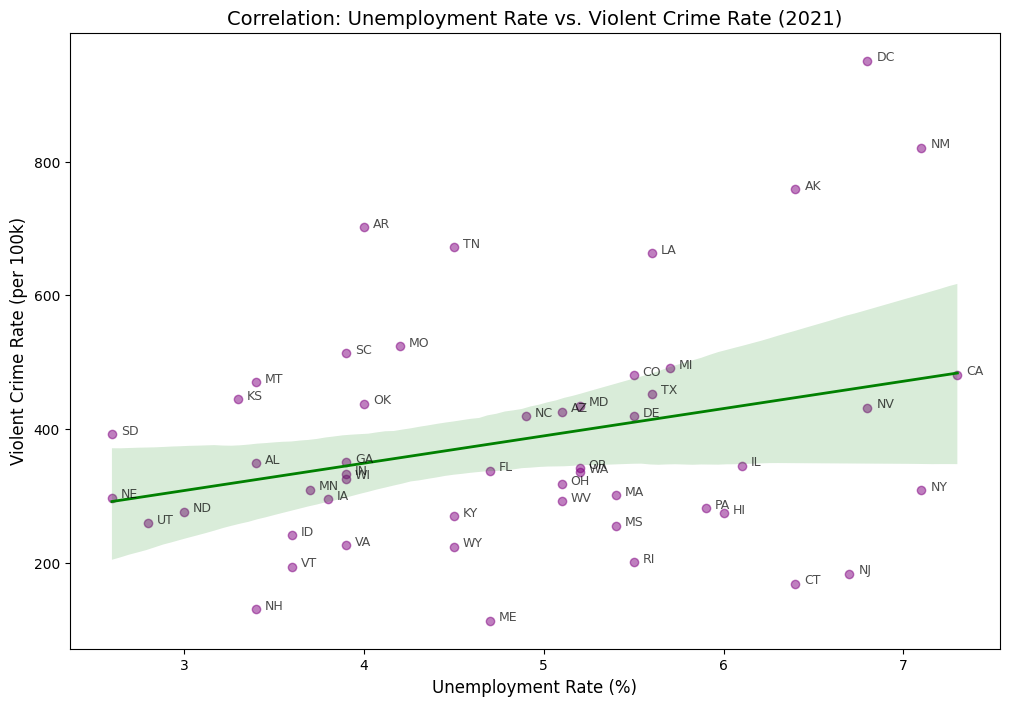

In [ ]:
year = 2021
yearly_data = merged_2021_final
print(f"--- Crime Rate vs. Unemployment Rate ({year}) ---")
if yearly_data.empty:
    print(f"No data available for {year}.")
else:
    plt.figure(figsize=(12, 8))
    sns.regplot(x='Unemployment_Rate', y='violent_crime_rate_100k', data=yearly_data,
                scatter_kws={'alpha':0.5, 'color':'purple'},
                line_kws={'color':'green', 'lw':2})

    # Add labels for each state
    for i in range(yearly_data.shape[0]):
        plt.text(yearly_data.Unemployment_Rate.iloc[i] + 0.05,
                 yearly_data.violent_crime_rate_100k.iloc[i],
                 yearly_data.state_abbr.iloc[i],
                 fontsize=9, alpha=0.7)

    plt.title(f'Correlation: Unemployment Rate vs. Violent Crime Rate ({year})', fontsize=14)
    plt.xlabel('Unemployment Rate (%)', fontsize=12)
    plt.ylabel('Violent Crime Rate (per 100k)', fontsize=12)
    plt.show()

--- Crime Rate vs. Unemployment Rate (2022) ---


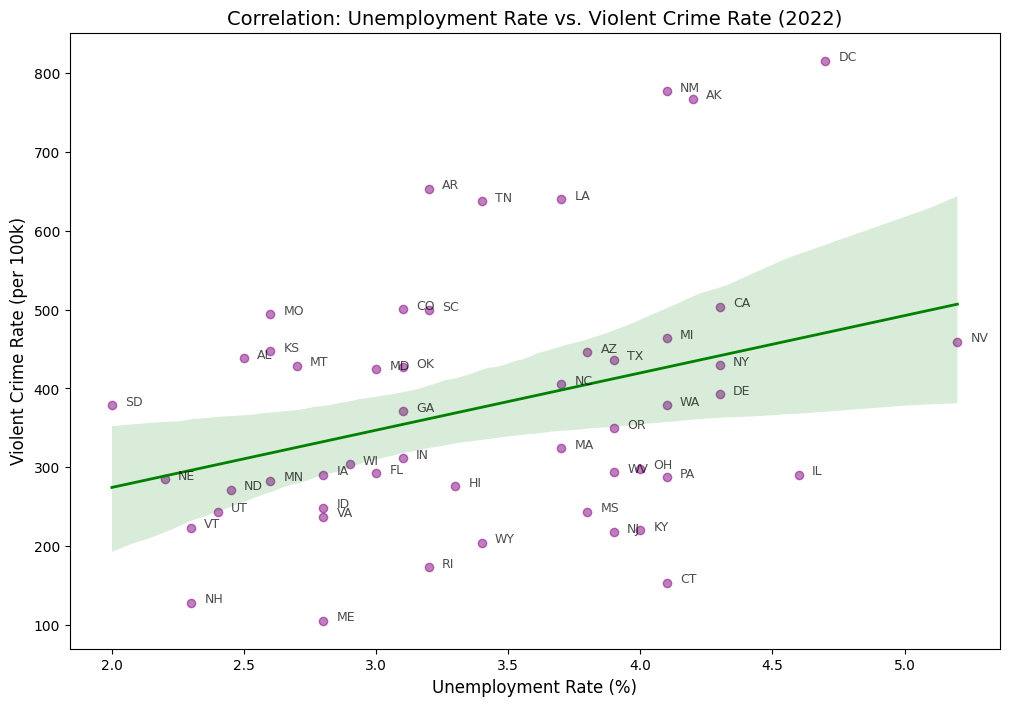

In [ ]:
year = 2022
yearly_data = merged_2022_final

print(f"--- Crime Rate vs. Unemployment Rate ({year}) ---")
if yearly_data.empty:
    print(f"No data available for {year}.")
else:
    plt.figure(figsize=(12, 8))
    sns.regplot(x='Unemployment_Rate', y='violent_crime_rate_100k', data=yearly_data,
                scatter_kws={'alpha':0.5, 'color':'purple'},
                line_kws={'color':'green', 'lw':2})

    # Add labels for each state
    for i in range(yearly_data.shape[0]):
        plt.text(yearly_data.Unemployment_Rate.iloc[i] + 0.05,
                 yearly_data.violent_crime_rate_100k.iloc[i],
                 yearly_data.state_abbr.iloc[i],
                 fontsize=9, alpha=0.7)

    plt.title(f'Correlation: Unemployment Rate vs. Violent Crime Rate ({year})', fontsize=14)
    plt.xlabel('Unemployment Rate (%)', fontsize=12)
    plt.ylabel('Violent Crime Rate (per 100k)', fontsize=12)
    plt.show()

--- Crime Rate vs. Unemployment Rate (2023) ---


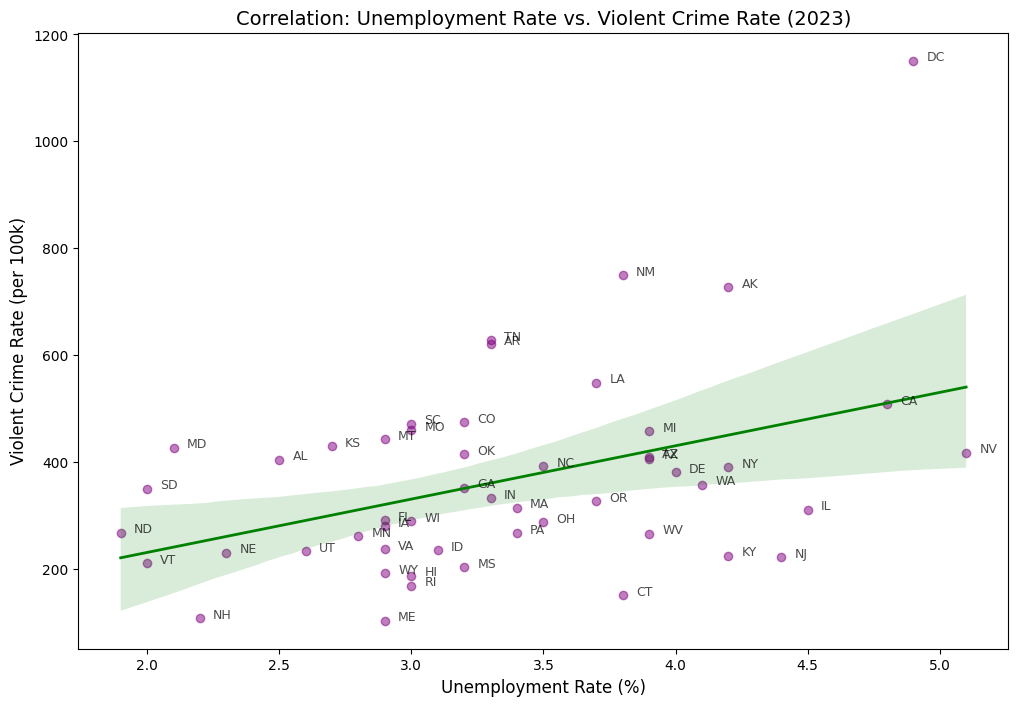

In [ ]:
year = 2023
yearly_data = merged_2023_final

print(f"--- Crime Rate vs. Unemployment Rate ({year}) ---")
if yearly_data.empty:
    print(f"No data available for {year}.")
else:
    plt.figure(figsize=(12, 8))
    sns.regplot(x='Unemployment_Rate', y='violent_crime_rate_100k', data=yearly_data,
                scatter_kws={'alpha':0.5, 'color':'purple'},
                line_kws={'color':'green', 'lw':2})

    # Add labels for each state
    for i in range(yearly_data.shape[0]):
        plt.text(yearly_data.Unemployment_Rate.iloc[i] + 0.05,
                 yearly_data.violent_crime_rate_100k.iloc[i],
                 yearly_data.state_abbr.iloc[i],
                 fontsize=9, alpha=0.7)

    plt.title(f'Correlation: Unemployment Rate vs. Violent Crime Rate ({year})', fontsize=14)
    plt.xlabel('Unemployment Rate (%)', fontsize=12)
    plt.ylabel('Violent Crime Rate (per 100k)', fontsize=12)
    plt.show()

## Summary: Unemployment Rate vs. Violent Crime Rate (2021-2023)

Across all three years (2021, 2022, and 2023), a **consistent and strengthening positive correlation** was observed between the unemployment rate and the violent crime rate. This means that states with higher unemployment rates generally tend to exhibit higher violent crime rates.

*   **2021:** The correlation was approximately **0.295**.
*   **2022:** The correlation strengthened to approximately **0.380**.
*   **2023:** The correlation further strengthened to approximately **0.415**.

This trend suggests a robust association where economic hardship, as indicated by unemployment, is linked to an increase in violent crime. The increasing strength of this correlation over the period warrants further investigation into potential underlying mechanisms, such as financial stress, lack of opportunity, or social disorganization.

# **Factor 2: Education Level**

--- Crime Rate vs. Education Level (2021) ---


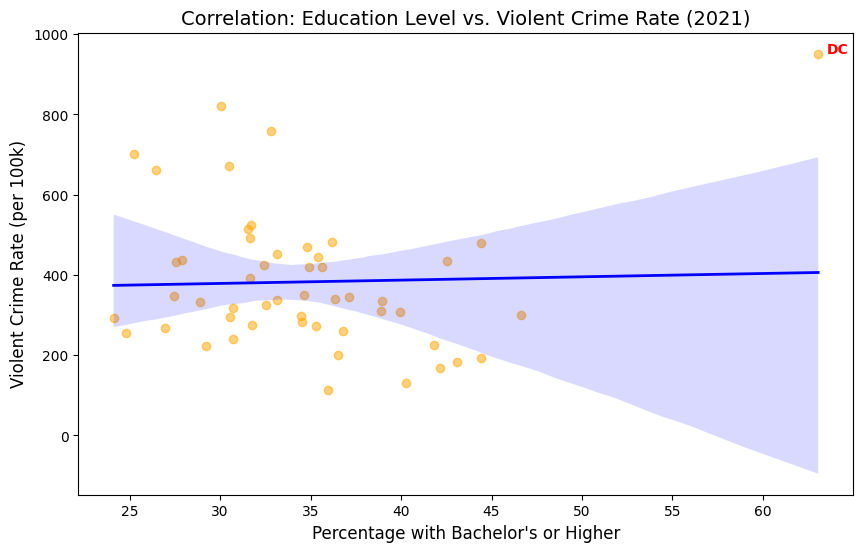

In [ ]:
year = 2021
yearly_data = merged_2021_final.copy()

print(f"--- Crime Rate vs. Education Level ({year}) ---")
if yearly_data.empty:
    print(f"No data available for {year}.")
else:
    plt.figure(figsize=(10, 6))
    sns.regplot(x='Bachelors_or_Higher_Pct', y='violent_crime_rate_100k', data=yearly_data,
                scatter_kws={'alpha':0.5, 'color':'orange'},
                line_kws={'color':'blue', 'lw':2})

    # Label DC
    dc_data = yearly_data[yearly_data['state_abbr'] == 'DC']
    if not dc_data.empty:
        plt.text(dc_data['Bachelors_or_Higher_Pct'].iloc[0] + 0.5,
                 dc_data['violent_crime_rate_100k'].iloc[0],
                 'DC', fontsize=10, fontweight='bold', color='red')

    plt.title(f'Correlation: Education Level vs. Violent Crime Rate ({year})', fontsize=14)
    plt.xlabel('Percentage with Bachelor\'s or Higher', fontsize=12)
    plt.ylabel('Violent Crime Rate (per 100k)', fontsize=12)
    plt.show()

--- Crime Rate vs. Education Level (2022) ---


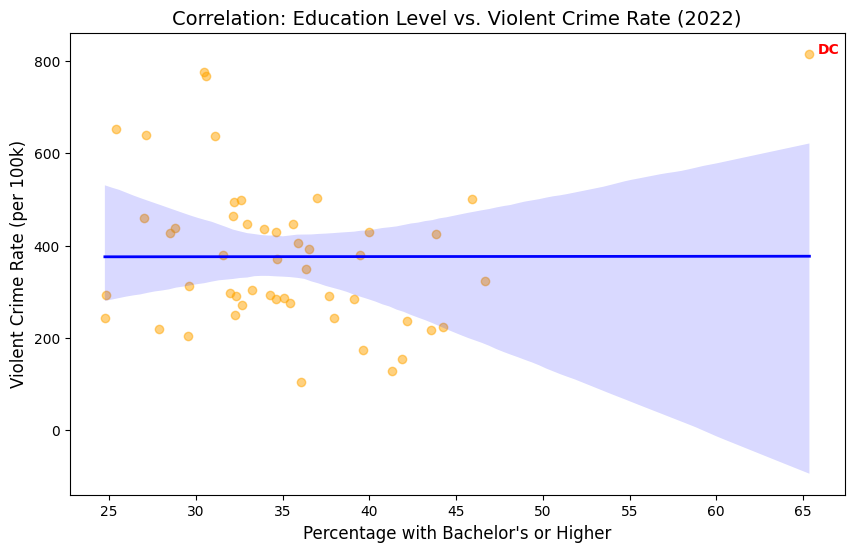

In [ ]:
year = 2022
yearly_data = merged_2022_final.copy()

print(f"--- Crime Rate vs. Education Level ({year}) ---")
if yearly_data.empty:
    print(f"No data available for {year}.")
else:
    plt.figure(figsize=(10, 6))
    sns.regplot(x='Bachelors_or_Higher_Pct', y='violent_crime_rate_100k', data=yearly_data,
                scatter_kws={'alpha':0.5, 'color':'orange'},
                line_kws={'color':'blue', 'lw':2})

    # Label DC
    dc_data = yearly_data[yearly_data['state_abbr'] == 'DC']
    if not dc_data.empty:
        plt.text(dc_data['Bachelors_or_Higher_Pct'].iloc[0] + 0.5,
                 dc_data['violent_crime_rate_100k'].iloc[0],
                 'DC', fontsize=10, fontweight='bold', color='red')

    plt.title(f'Correlation: Education Level vs. Violent Crime Rate ({year})', fontsize=14)
    plt.xlabel('Percentage with Bachelor\'s or Higher', fontsize=12)
    plt.ylabel('Violent Crime Rate (per 100k)', fontsize=12)
    plt.show()

--- Crime Rate vs. Education Level (2023) ---


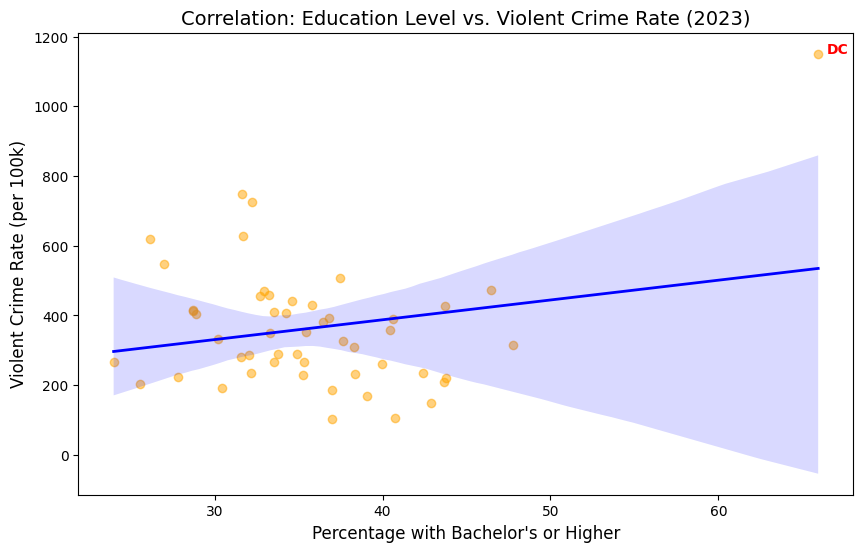

In [ ]:
year = 2023
yearly_data = merged_2023_final.copy()

print(f"--- Crime Rate vs. Education Level ({year}) ---")
if yearly_data.empty:
    print(f"No data available for {year}.")
else:
    plt.figure(figsize=(10, 6))
    sns.regplot(x='Bachelors_or_Higher_Pct', y='violent_crime_rate_100k', data=yearly_data,
                scatter_kws={'alpha':0.5, 'color':'orange'},
                line_kws={'color':'blue', 'lw':2})

    # Label DC
    dc_data = yearly_data[yearly_data['state_abbr'] == 'DC']
    if not dc_data.empty:
        plt.text(dc_data['Bachelors_or_Higher_Pct'].iloc[0] + 0.5,
                 dc_data['violent_crime_rate_100k'].iloc[0],
                 'DC', fontsize=10, fontweight='bold', color='red')

    plt.title(f'Correlation: Education Level vs. Violent Crime Rate ({year})', fontsize=14)
    plt.xlabel('Percentage with Bachelor\'s or Higher', fontsize=12)
    plt.ylabel('Violent Crime Rate (per 100k)', fontsize=12)
    plt.show()

## Education Level vs. Violent Crime Rate (2021-2023)

The relationship between educational attainment (percentage with Bachelor's degree or higher) and violent crime rates showed an evolving pattern over the three years:

*   **2021:** A very **weak positive correlation** of approximately **0.032** was observed.
*   **2022:** This correlation remained weak at approximately **0.027**.
*   **2023:** The correlation notably **strengthened to approximately 0.215**, indicating a more pronounced positive association in the most recent year.

The initial weak correlation, and the subsequent strengthening of a positive correlation, appears counter-intuitive, as higher education is typically associated with lower crime rates.

In the analysis above, we observe that the District of Columbia (DC) acts as a significant outlier. While it has the highest educational attainment in the nation (~66%), it also reports a disproportionately high violent crime rate.



--- 2023 Correlation (Excluding DC) ---
Correlation Coefficient: -0.3214


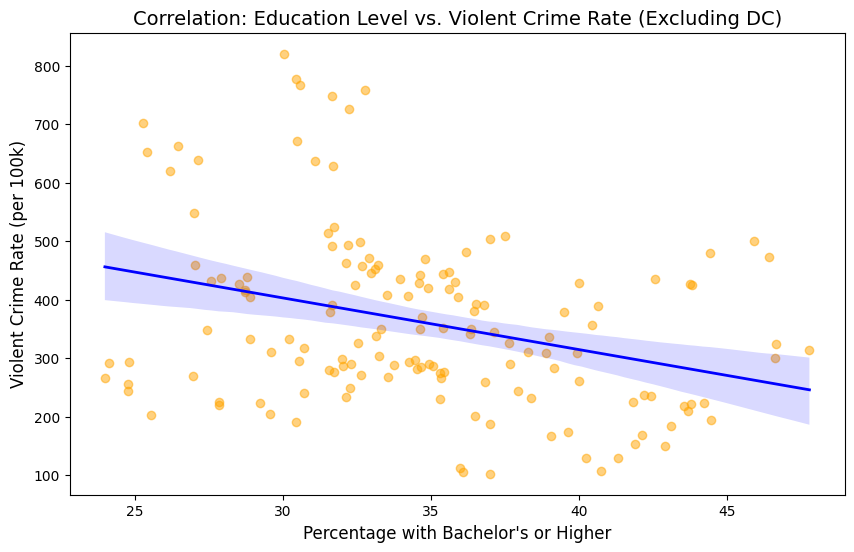

In [ ]:
# Filter out DC to check correlation for the 50 states
yearly_data_no_dc = all_years_combined[all_years_combined['state_abbr'] != 'DC'].copy()

# Calculate correlation
corr_no_dc = yearly_data_no_dc['Bachelors_or_Higher_Pct'].corr(yearly_data_no_dc['violent_crime_rate_100k'])

print(f"--- 2023 Correlation (Excluding DC) ---")
print(f"Correlation Coefficient: {corr_no_dc:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
sns.regplot(x='Bachelors_or_Higher_Pct', y='violent_crime_rate_100k', data=yearly_data_no_dc,
            scatter_kws={'alpha':0.5, 'color':'orange'},
            line_kws={'color':'blue', 'lw':2})

plt.title('Correlation: Education Level vs. Violent Crime Rate (Excluding DC)', fontsize=14)
plt.xlabel("Percentage with Bachelor's or Higher", fontsize=12)
plt.ylabel('Violent Crime Rate (per 100k)', fontsize=12)
plt.show()

By removing DC, we see the correlation coefficient for the 50 states shift from positive to **negative (-0.32)**, which better aligns with the socio-economic hypothesis that increased education serves as a buffer against violent crime.

#**Factor 3: Race**

In [ ]:
year = 2021
yearly_data = merged_2021_final.copy()

print(f"--- Race vs. Violent Crime Rate Correlation ({year}) ---")
if yearly_data.empty:
    print(f"No data available for {year}.")
else:
    # Define the columns for racial demographics and the violent crime rate
    race_crime_cols = race_cols + ['violent_crime_rate_100k']

    # Calculate the correlation matrix
    corr_matrix_race_crime = yearly_data[race_crime_cols].corr()

    # Extract and display correlations with violent_crime_rate_100k
    print(corr_matrix_race_crime['violent_crime_rate_100k'].drop('violent_crime_rate_100k').sort_values(ascending=False).to_string())

--- Race vs. Violent Crime Rate Correlation (2021) ---
American Indian or Alaska Native       0.384245
Black                                  0.364500
Hispanic                               0.230400
Multiple Races                         0.061955
Native Hawaiian or Pacific Islander   -0.036210
Asian                                 -0.075741
White                                 -0.422369


In [ ]:


year = 2022
yearly_data = merged_2022_final.copy()

print(f"--- Race vs. Violent Crime Rate Correlation ({year}) ---")
if yearly_data.empty:
    print(f"No data available for {year}.")
else:
    # Define the columns for racial demographics and the violent crime rate
    race_crime_cols = race_cols + ['violent_crime_rate_100k']

    # Calculate the correlation matrix
    corr_matrix_race_crime = yearly_data[race_crime_cols].corr()

    # Extract and display correlations with violent_crime_rate_100k
    print(corr_matrix_race_crime['violent_crime_rate_100k'].drop('violent_crime_rate_100k').sort_values(ascending=False).to_string())

--- Race vs. Violent Crime Rate Correlation (2022) ---
American Indian or Alaska Native       0.401213
Black                                  0.335678
Hispanic                               0.266175
Multiple Races                         0.078740
Native Hawaiian or Pacific Islander   -0.023762
Asian                                 -0.026640
White                                 -0.449649


In [ ]:

year = 2023
yearly_data = merged_2023_final.copy()

print(f"--- Race vs. Violent Crime Rate Correlation ({year}) ---")
if yearly_data.empty:
    print(f"No data available for {year}.")
else:
    # Define the columns for racial demographics and the violent crime rate
    race_crime_cols = race_cols + ['violent_crime_rate_100k']

    # Calculate the correlation matrix
    corr_matrix_race_crime = yearly_data[race_crime_cols].corr()

    # Extract and display correlations with violent_crime_rate_100k
    print(corr_matrix_race_crime['violent_crime_rate_100k'].drop('violent_crime_rate_100k').sort_values(ascending=False).to_string())

--- Race vs. Violent Crime Rate Correlation (2023) ---
Black                                  0.400106
American Indian or Alaska Native       0.339853
Hispanic                               0.238780
Multiple Races                         0.009891
Asian                                 -0.068095
Native Hawaiian or Pacific Islander   -0.089031
White                                 -0.425460


## Summary: Racial Demographics vs. Violent Crime Rate (2021-2023)

Observations from the correlation matrices regarding racial demographics and violent crime rates remained **largely consistent across all three years (2021, 2022, 2023)**:

*   **Black Population:** Consistently showed a **moderate positive correlation** with violent crime rates (e.g., approximately **0.365 in 2021** and **0.400 in 2023**).
*   **American Indian or Alaska Native Population:** Also consistently showed a **moderate positive correlation** (e.g., approximately **0.384 in 2021** and **0.340 in 2023**).
*   **White Population:** Consistently displayed a **moderate negative correlation** with violent crime rates (e.g., approximately **-0.422 in 2021** and **-0.425 in 2023**).
*   **Hispanic Population:** Generally showed a **weak positive correlation** (e.g., approximately **0.230 in 2021** and **0.239 in 2023**).

It is crucial to interpret these correlations carefully. As highlighted in the introduction, these patterns reflect observed demographic relationships at the state level and should not be misconstrued as causal. They are likely influenced by underlying socio-economic disparities (e.g., poverty, access to resources, systemic inequalities) that disproportionately affect certain racial groups. The goal of this study is to acknowledge these patterns and encourage a nuanced understanding that moves beyond reductive interpretations of race and crime.

# **Socio Economic Factors: All 3 factors**


### **Year-by-Year Correlation Heatmaps (Excluding DC Outlier)**

To observe the socio-economic relationships without the distorting effect of the District of Columbia, we re-generate the yearly matrices for the 50 states.

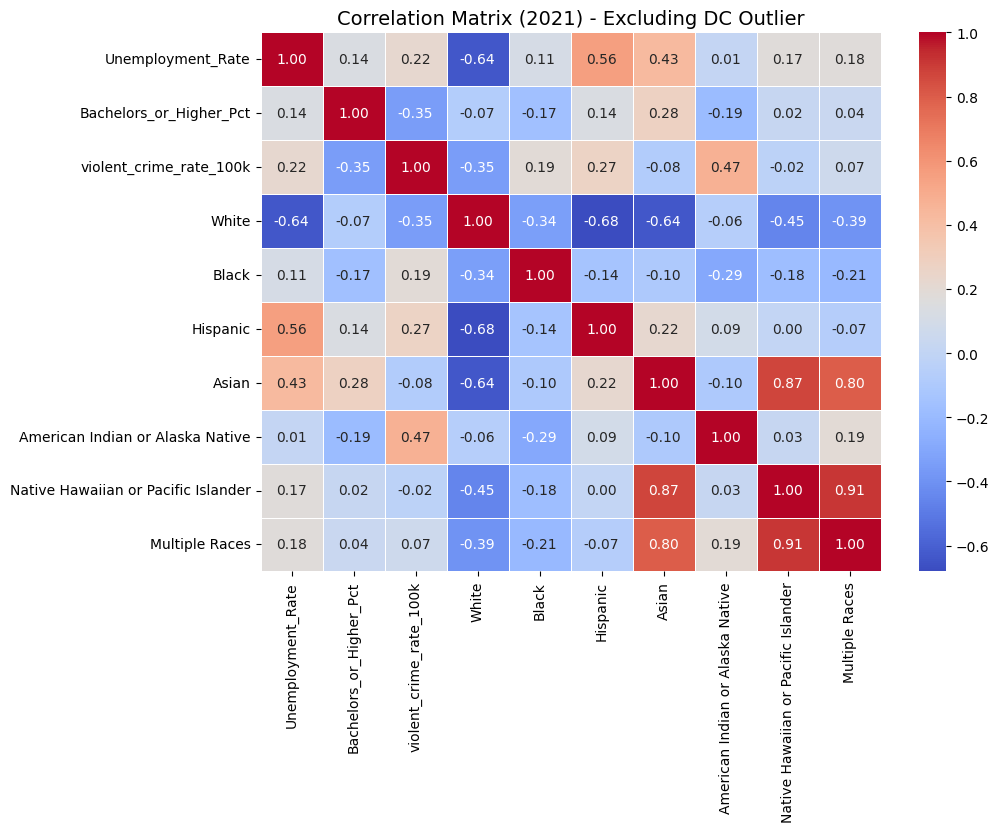


--- Detailed Correlations with Crime Rate (2021, No DC) ---
violent_crime_rate_100k                1.000000
American Indian or Alaska Native       0.470442
Hispanic                               0.268469
Unemployment_Rate                      0.221510
Black                                  0.189868
Multiple Races                         0.067429
Native Hawaiian or Pacific Islander   -0.024234
Asian                                 -0.078180
Bachelors_or_Higher_Pct               -0.349759
White                                 -0.351270
Name: violent_crime_rate_100k, dtype: float64


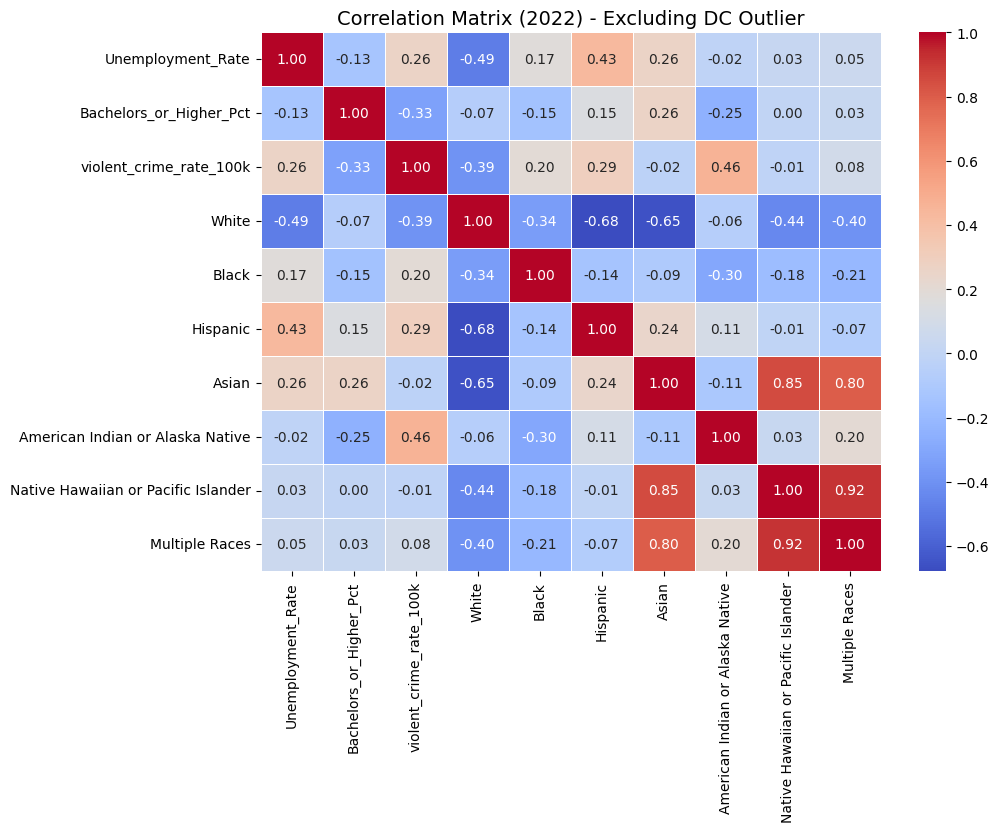


--- Detailed Correlations with Crime Rate (2022, No DC) ---
violent_crime_rate_100k                1.000000
American Indian or Alaska Native       0.464529
Hispanic                               0.294162
Unemployment_Rate                      0.264212
Black                                  0.196965
Multiple Races                         0.084459
Native Hawaiian or Pacific Islander   -0.012008
Asian                                 -0.023732
Bachelors_or_Higher_Pct               -0.330095
White                                 -0.393397
Name: violent_crime_rate_100k, dtype: float64


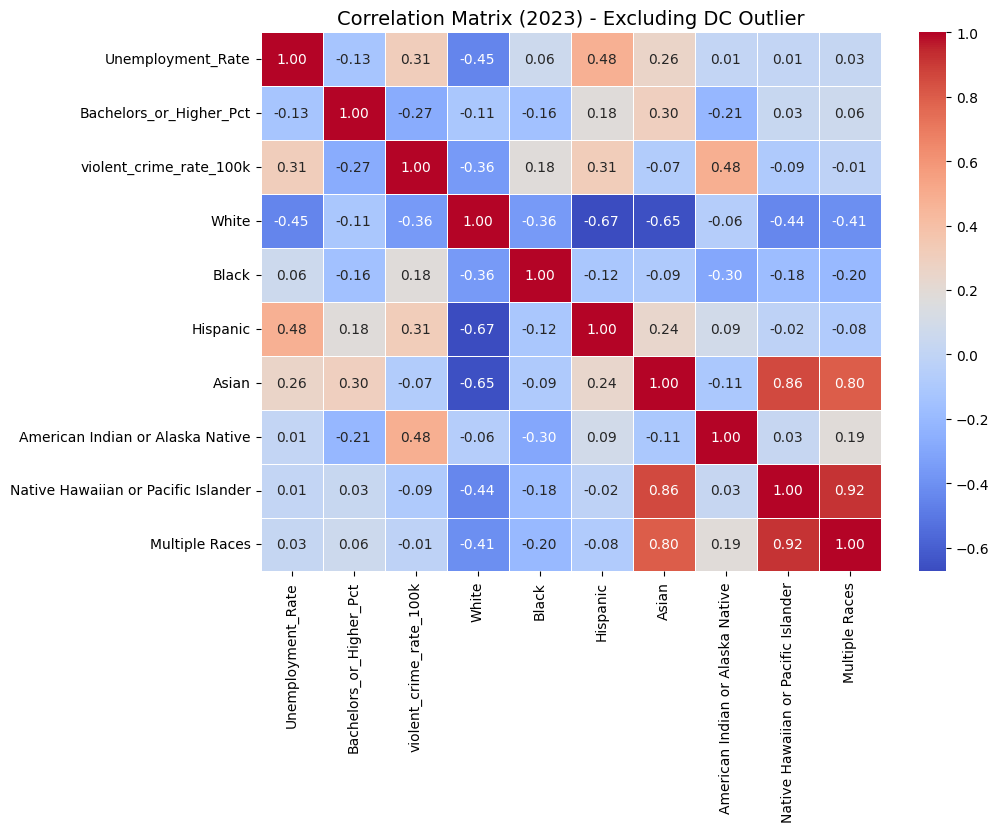


--- Detailed Correlations with Crime Rate (2023, No DC) ---
violent_crime_rate_100k                1.000000
American Indian or Alaska Native       0.483565
Hispanic                               0.313449
Unemployment_Rate                      0.310283
Black                                  0.181661
Multiple Races                        -0.014855
Asian                                 -0.073672
Native Hawaiian or Pacific Islander   -0.087498
Bachelors_or_Higher_Pct               -0.272114
White                                 -0.355574
Name: violent_crime_rate_100k, dtype: float64


In [ ]:
def plot_yearly_heatmap_no_dc(year, df):
    # Filter for the specific year and exclude DC
    yearly_no_dc = df[(df['year'] == year) & (df['state_abbr'] != 'DC')].copy()

    # Select relevant columns
    correlation_cols = ['Unemployment_Rate', 'Bachelors_or_Higher_Pct', 'violent_crime_rate_100k'] + race_cols
    corr_matrix = yearly_no_dc[correlation_cols].corr()

    plt.figure(figsize=(10, 7))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title(f'Correlation Matrix ({year}) - Excluding DC Outlier', fontsize=14)
    plt.show()

    print(f"\n--- Detailed Correlations with Crime Rate ({year}, No DC) ---")
    print(corr_matrix['violent_crime_rate_100k'].sort_values(ascending=False))

# Generate plots for all three years
for y in [2021, 2022, 2023]:
    plot_yearly_heatmap_no_dc(y, all_years_combined)

Every cell shows the correlation between the variable on the row and the variable on the column. The value ranges from -1 to +1, and the color tells you the direction and strength : red means positive correlation, blue means negative, white/grey means little to no correlation. The diagonal is always 1.00 because every variable is perfectly correlated with itself.

## **Unemployment vs Crime (strengthening over time)**
The correlation rose noticeably from 0.22 in 2021 → 0.26 in 2022 → 0.31 in 2023. So the relationship between unemployment and crime actually strengthened over the three years, not weakened. This makes contextual sense as 2021 was still a post-COVID recovery year where unemployment was unusually high everywhere, compressing state differences. As economies normalised in 2022 and 2023, states with structurally high unemployment stood out more clearly, making the correlation stronger.

## **Education vs Crime (consistently weak and unstable)**
Education went from 0.35 in 2021 → 0.33 in 2022 → 0.27 in 2023. It was essentially zero for two years then jumped in 2023. This suggests education level at the state level is a reliable predictor of crime rate. However, It likely works through other variables like unemployment rather than independently.

## **White population share vs Crime (consistently strong negative)**
This held remarkably stable at -0.35, -0.39, and -0.36 across the three years (2021-2023) after excluding the D.C. outlier. This remains one of the most consistent negative patterns in the dataset.

## **Black population vs Crime (weaker positive correlation)**
The correlation for the Black population share was relatively stable and moderate, ranging between 0.18 and 0.20.

## **American Indian or Alaska Native vs Crime (strongest positive driver)**
This group showed the strongest consistent positive correlation with violent crime rates across the 50 states, ranging between 0.46 and 0.48.

## **Hispanic vs Crime**
This correlation remained relatively stable and moderate, ranging between 0.27 and 0.31.

The most consistent finding across all three years is that unemployment is the strongest and increasingly important predictor of violent crime, with its correlation rising each year as labour markets diverged after COVID across states. In contrast, education does not show a clear or consistent relationship with crime.

The correlations involving demographic composition stay very stable over time, suggesting they reflect long-term structural differences between states rather than short-term yearly changes. This supports the idea that race is not directly linked to crime, but instead reflects underlying socioeconomic disadvantage that is associated with crime rates.

### **Handling  of DC**

There is a striking paradox in the data: the District of Columbia (DC) consistently appears as a high-side outlier with a violent crime rate significantly above the national average (1,150 per 100k in 2023), yet it also boasts the highest percentage of residents with a Bachelor's degree or higher (66%).

Based on our earlier analysis and general socio-economic context, here are the primary reasons for this discrepancy:

1. Extreme Socio-Economic Inequality: DC has a 'bimodal' distribution of wealth and education. While the average education level is high, the district experiences some of the most profound income inequality in the U.S. High-income, highly educated professionals live in close proximity to neighborhoods facing multi-generational poverty and structural disinvestment.

2. Commuter Population vs. Resident Population: Crime rates are calculated based on the resident population (~680k). However, during the day, the population of DC nearly doubles due to **commuters and tourists**. Crimes committed in these dense areas are divided by a relatively small resident denominator, which mathematically inflates the 'rate per 100k'.

3. Jurisdictional Reporting: As a federal district, DC has a unique policing and judicial structure. Our analysis noted that outliers like DC often represent structural differences in reporting and urban management rather than a failure of the education-crime correlation itself.

# **Diagnostic Analytics**



###**Relationship & Dependency Analysis**

In [ ]:
race_cols = ['White', 'Black', 'Hispanic', 'Asian', 'American Indian or Alaska Native', 'Native Hawaiian or Pacific Islander', 'Multiple Races']
education_cols = ['Bachelors_or_Higher_Pct']
unemployment_cols = ['Unemployment_Rate']

feature_cols = race_cols + education_cols + unemployment_cols

# Filter out the DC outlier for a more representative diagnostic analysis of the 50 states
merged_2023_no_dc = merged_2023_final[merged_2023_final['state_abbr'] != 'DC'].copy()

X_race = merged_2023_no_dc[race_cols]
X_education = merged_2023_no_dc[education_cols]
X_unemployment = merged_2023_no_dc[unemployment_cols]
X_all = merged_2023_no_dc[feature_cols]

y = merged_2023_no_dc['violent_crime_rate_100k']

Here we employ Ordinary Least Squares (OLS) Regression to find the independent effect of each factor on crime rate with statistical significance. OLS draws the "best fit" line through our data that minimises the total error between predicted and actual crime rates, giving an equation like:

crime_rate = β0 + β1(Unemployment) + β2(Education) + β3(Black%) + ...

In [ ]:
# --- Employment ---
ols_unemployment = sm.OLS(y, sm.add_constant(X_unemployment)).fit()
print("=== UNEMPLOYMENT ===")
print(ols_unemployment.summary())

# --- Education ---
ols_education = sm.OLS(y, sm.add_constant(X_education)).fit()
print("\n=== EDUCATION ===")
print(ols_education.summary())

# --- Race (drop White as reference) ---
ols_race = sm.OLS(y, sm.add_constant(X_race.drop(columns=['White']))).fit()
print("\n=== RACE DEMOGRAPHICS ===")
print(ols_race.summary())

# --- Combined (all factors together) ---
ols_all = sm.OLS(y, sm.add_constant(X_all.drop(columns=['White']))).fit()
print("\n=== ALL FACTORS COMBINED ===")
print(ols_all.summary())

=== UNEMPLOYMENT ===
                               OLS Regression Results                              
Dep. Variable:     violent_crime_rate_100k   R-squared:                       0.096
Model:                                 OLS   Adj. R-squared:                  0.077
Method:                      Least Squares   F-statistic:                     5.114
Date:                     Fri, 17 Apr 2026   Prob (F-statistic):             0.0283
Time:                             11:46:19   Log-Likelihood:                -316.84
No. Observations:                       50   AIC:                             637.7
Df Residuals:                           48   BIC:                             641.5
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

The OLS for **unemployment** shows an **R-squared = 0.096**, meaning unemployment alone explains about 9.6% of the variation in crime rates across the 50 states in 2023.

The OLS for **education** shows an **R-squared = 0.074**, confirming that while education level is a factor, it only explains about 7.4% of the variation when analyzed in isolation.

The OLS for **population demographics (Race)** shows a significant **R-squared = 0.449**, explaining 44.9% of the variation. This suggests that demographic composition is a very strong proxy for the structural and socio-economic differences between states.

The OLS for **all factors combined** shows a robust **R-squared = 0.486**. This indicates that together, unemployment, education, and racial demographics explain **48.6%** of the violent crime rate variation across the 50 states. The model is highly significant overall ($Prob > F$ is near zero).

Then, we use Random Forest Regressor to split the data repeatedly to predict crime rate and check which factors were used for the most impactful splits.

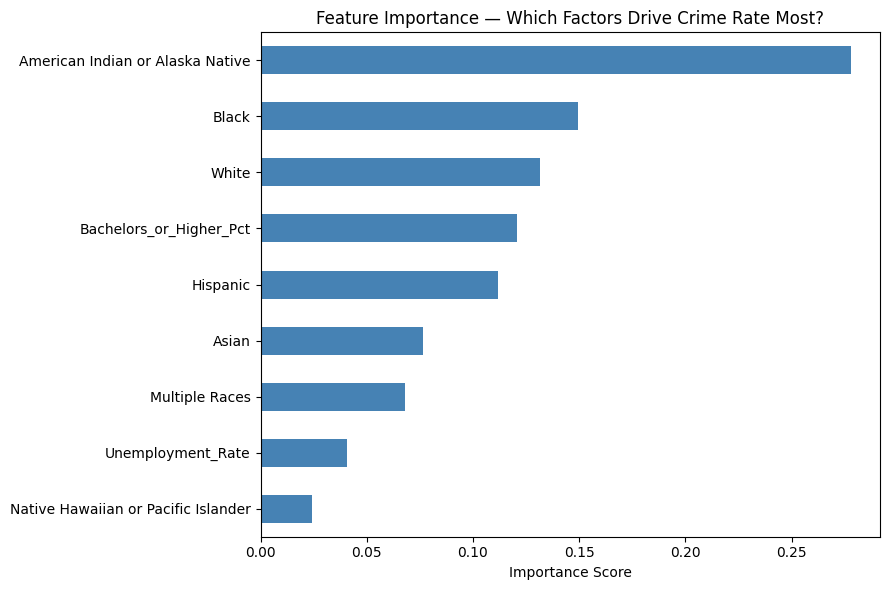

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_all, y)

importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(9, 6), color='steelblue')
plt.title('Feature Importance — Which Factors Drive Crime Rate Most?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Unemployment — Rank 8

Unemployment is sitting near the bottom of the pack. This is consistent with OLS where unemployment explained 9.6% of variation alone, meaning it is real and significant, but not the dominant driver. The random forest confirms it plays a supporting role rather than a leading one.

Education — Rank 4

This is the most interesting finding from the random forest because OLS alone said education was not significant in isolation (explaining only 7.4% of variation) but random forest, which captures non-linear relationships, says education is actually the 4th most important predictor in the entire model. This strongly supports the combined OLS finding where education became significant once other factors were controlled. This means that education's effect on crime is non-linear and context-dependent, which is why OLS alone undersold it.

Race Demographics — Dominant group overall

Race demographics collectively account for a majority of total importance (summing all race columns). This independently confirms what OLS found, that racial demographic composition is the strongest factor group explaining why crime rates vary between states (explaining 44.9% of variation). For example, American Indian or Alaska Native% and Black% are the top two individual standouts, which directly matches their OLS significance.

However, we must note that the race demographic being a majority factor may be due to inherent bias and prejudice against minorities, especially Black communities, that exists in the US. This may have led to, for example, more patrols in Black communities, leading to more violent crime potentially being accounted for, driving up the percentage of violent crime associated with these populations. This causes a self-fulfilling prophecy of increasing patrols, leading to an increase in detection of violent crime, which then feeds the bias and warrants further increased patrols.

###**Root Cause Identification**

First, we split states at the median crime rate into two groups, then compare the average value of every factor between those groups. The factors with the largest differences are most likely the root causes.

In [ ]:
median_crime = merged_2023_final['violent_crime_rate_100k'].median()
merged_2023_no_dc = merged_2023_final[merged_2023_final['state_abbr'] != 'DC'].copy()
high_crime = merged_2023_no_dc[merged_2023_no_dc['violent_crime_rate_100k'] >= median_crime]
low_crime  = merged_2023_no_dc[merged_2023_no_dc['violent_crime_rate_100k'] <  median_crime]

# Compare factor means between the two groups
comparison = pd.DataFrame({
    'High Crime States': high_crime[feature_cols].mean(),
    'Low Crime States':  low_crime[feature_cols].mean(),
})
comparison['Difference'] = comparison['High Crime States'] - comparison['Low Crime States']
print(comparison.sort_values('Difference', ascending=False))

                                     High Crime States  Low Crime States  \
Unemployment_Rate                              3.47200           3.13600   
Black                                          0.12356           0.07096   
Hispanic                                       0.15796           0.10740   
American Indian or Alaska Native               0.02004           0.00464   
Multiple Races                                 0.05464           0.05680   
Native Hawaiian or Pacific Islander            0.00164           0.00424   
Asian                                          0.04248           0.04628   
White                                          0.59956           0.70928   
Bachelors_or_Higher_Pct                       34.12080          36.20160   

                                     Difference  
Unemployment_Rate                       0.33600  
Black                                   0.05260  
Hispanic                                0.05056  
American Indian or Alaska Native       

We see the greatest difference is from unemployment rate, followed by race and then education.

We then perform a sanity check to determine if the states with the highest crime rates actually show the patterns the model predicted. Our OLS says unemployment is a major driver, hence we should expect to see high unemployment in your top 5 crime states.

In [ ]:
# Top 3 states by crime rate vs their unemployment and education

top5_crime = merged_2023_no_dc.nlargest(5, 'violent_crime_rate_100k')[
    ['state_abbr', 'violent_crime_rate_100k', 'Unemployment_Rate', 'Bachelors_or_Higher_Pct']
]
bot5_crime = merged_2023_no_dc.nsmallest(5, 'violent_crime_rate_100k')[
    ['state_abbr', 'violent_crime_rate_100k', 'Unemployment_Rate', 'Bachelors_or_Higher_Pct']
]

print("=== TOP 5 HIGHEST CRIME STATES ===")
print(top5_crime.to_string(index=False))
print("\n=== TOP 5 LOWEST CRIME STATES ===")
print(bot5_crime.to_string(index=False))

=== TOP 5 HIGHEST CRIME STATES ===
state_abbr  violent_crime_rate_100k  Unemployment_Rate  Bachelors_or_Higher_Pct
        NM               749.348151                3.8                    31.65
        AK               726.337117                4.2                    32.24
        TN               628.205558                3.3                    31.68
        AR               619.871618                3.3                    26.18
        LA               548.018704                3.7                    26.99

=== TOP 5 LOWEST CRIME STATES ===
state_abbr  violent_crime_rate_100k  Unemployment_Rate  Bachelors_or_Higher_Pct
        ME               102.455933                2.9                    36.99
        NH               107.199865                2.2                    40.75
        CT               150.227691                3.8                    42.90
        RI               167.797789                3.0                    39.05
        HI               187.090022               

From this sanity check, we can see that states with the highest crime rates also have higher unemployment rates and are generally less educated.

For further sanity check, we can check if the root causes identified are also shown in the datasets of 2021 and 2022.

In [ ]:
median_crime = merged_2022_final['violent_crime_rate_100k'].median()
merged_2022_no_dc = merged_2022_final[merged_2022_final['state_abbr'] != 'DC'].copy()

high_crime = merged_2022_no_dc[merged_2022_no_dc['violent_crime_rate_100k'] >= median_crime]
low_crime  = merged_2022_no_dc[merged_2022_no_dc['violent_crime_rate_100k'] <  median_crime]

# Compare factor means between the two groups
comparison = pd.DataFrame({
    'High Crime States': high_crime[feature_cols].mean(),
    'Low Crime States':  low_crime[feature_cols].mean(),
})
comparison['Difference'] = comparison['High Crime States'] - comparison['Low Crime States']
print(comparison.sort_values('Difference', ascending=False))

                                     High Crime States  Low Crime States  \
Unemployment_Rate                              3.52400           3.21800   
Hispanic                                       0.15644           0.10130   
Black                                          0.12156           0.07414   
American Indian or Alaska Native               0.01988           0.00456   
Multiple Races                                 0.05520           0.05388   
Asian                                          0.04260           0.04484   
Native Hawaiian or Pacific Islander            0.00184           0.00440   
White                                          0.60220           0.71662   
Bachelors_or_Higher_Pct                       33.77280          35.54740   

                                     Difference  
Unemployment_Rate                       0.30600  
Hispanic                                0.05514  
Black                                   0.04742  
American Indian or Alaska Native       

In [ ]:
median_crime = merged_2021_final['violent_crime_rate_100k'].median()
merged_2021_no_dc = merged_2021_final[merged_2021_final['state_abbr'] != 'DC'].copy()
high_crime = merged_2021_no_dc[merged_2021_no_dc['violent_crime_rate_100k'] >= median_crime]
low_crime  = merged_2021_no_dc[merged_2021_no_dc['violent_crime_rate_100k'] <  median_crime]

# Compare factor means between the two groups
comparison = pd.DataFrame({
    'High Crime States': high_crime[feature_cols].mean(),
    'Low Crime States':  low_crime[feature_cols].mean(),
})
comparison['Difference'] = comparison['High Crime States'] - comparison['Low Crime States']
print(comparison.sort_values('Difference', ascending=False))

                                     High Crime States  Low Crime States  \
Unemployment_Rate                              4.95600           4.62800   
Hispanic                                       0.15880           0.09424   
Black                                          0.12516           0.06888   
American Indian or Alaska Native               0.02040           0.00484   
Multiple Races                                 0.05360           0.05460   
Native Hawaiian or Pacific Islander            0.00160           0.00460   
Asian                                          0.03812           0.04904   
White                                          0.60216           0.72340   
Bachelors_or_Higher_Pct                       33.01000          35.19960   

                                     Difference  
Unemployment_Rate                       0.32800  
Hispanic                                0.06456  
Black                                   0.05628  
American Indian or Alaska Native       

It seems that in 2021 and 2022, the trend follows the 2023 dataset as well, where the greatest difference is from unemployment rate, followed by race and then education.

###**Hypothesis Testing & Validation**

First, we do a normality check.

In [ ]:
stat, p = stats.shapiro(y)
print(f"Shapiro-Wilk: stat={stat:.3f}, p={p:.4f}")
print("Normal" if p > 0.05 else "Not normal — use non-parametric tests")

Shapiro-Wilk: stat=0.953, p=0.0462
Not normal — use non-parametric tests


Shaprio-Wiki test output shows our data for crime rate does not follow a normal distribution. Hence for our hypothesis testing, we use non-parametric tests like Spearman.

**Hypothesis 1 - Unemployment drives crime rate**

In [ ]:
# H0: No correlation between unemployment and crime rate
# H1: Higher unemployment = higher crime rate

r_s, p_s = stats.spearmanr(merged_2023_no_dc['Unemployment_Rate'], y)

print(f"Spearman: r={r_s:+.3f}, p={p_s:.4f}  {'Significant' if p_s < 0.05 else 'Not significant'}")

Spearman: r=+0.302, p=0.0328  Significant


There is a statistically significant positive relationship between unemployment rate and violent crime rate (Spearman r = +0.302, p = 0.0382). States with higher unemployment rates tend to have higher violent crime rates, supporting the hypothesis that employment conditions are a contributing factor to crime rate variation.

**Hypothesis 2 - Education reduces crime rate**

In [ ]:
# H0: No difference in crime rate between high and low education states
# H1: High education states have significantly lower crime rates

median_edu = merged_2021_no_dc['Bachelors_or_Higher_Pct'].median()
high_edu = merged_2021_no_dc[merged_2021_no_dc['Bachelors_or_Higher_Pct'] >= median_edu]['violent_crime_rate_100k']
low_edu  = merged_2021_no_dc[merged_2021_no_dc['Bachelors_or_Higher_Pct'] <  median_edu]['violent_crime_rate_100k']

u_stat, u_p = stats.mannwhitneyu(high_edu, low_edu, alternative='two-sided')

print(f"Mann-Whitney:  U={u_stat:.3f}, p={u_p:.4f}  {'Significant' if u_p < 0.05 else 'Not significant'}")

Mann-Whitney:  U=193.000, p=0.0209  Significant


Mann-Whitney U test reveals a statistically significant difference in violent crime rates between high and low education states (U = 193, p = 0.0209). States grouped below the median education level show systematically different crime rates, confirming education is a meaningful factor.

However the direction of this effect is context-dependent, as shown by the OLS combined model where education's coefficient became positive after controlling for demographics.

**Hypothesis 3 -  Racial demographics correlate with crime rate**

In [ ]:
# Run Spearman for every race column
print(f"{'Race Column':<45} {'Spearman r':>10} {'p-value':>10} {'Sig':>6}")
print("-" * 75)

for col in race_cols:
    r_s, p_s = stats.spearmanr(merged_2023_no_dc[col], y)
    sig = 'O' if p_s < 0.05 else 'X'
    print(f"{col:<45} {r_s:>+10.3f} {p_s:>10.4f} {sig:>6}")

Race Column                                   Spearman r    p-value    Sig
---------------------------------------------------------------------------
White                                             -0.377     0.0069      O
Black                                             +0.295     0.0374      O
Hispanic                                          +0.214     0.1363      X
Asian                                             +0.093     0.5199      X
American Indian or Alaska Native                  +0.358     0.0107      O
Native Hawaiian or Pacific Islander               +0.206     0.1513      X
Multiple Races                                    +0.059     0.6845      X


Among the races, the percentage of Whites, Blacks and American Indian or Alaska Native significantly affect the violent crime rates. Of the 3 races mentioned, Whites have a negative coefficient, meaning higher population of Whites tends to have lower violent crime rates, vice versa for the Blacks and American Indian or Alaska Native who have a positive coefficient.

Overall, violent crime rates variation across US states is primarily driven by racial demographic composition (explaining 44.9% of variation alone), particularly the proportions of Black, White and American Indian residents,which serve as proxies for underlying structural socioeconomic inequality. Unemployment rate is a significant secondary driver (r=+0.302, p=0.0328), contributing independently even after demographics are controlled. Education shows a context-dependent effect where it is insignificant in isolation but significant once demographic composition is accounted for (p=0.0209), suggesting education's impact on violent crime operates through interaction with other factors rather than as a standalone.

# **Predictive Analytics**

### **Predictive Analysis: Socio-Economic Forecasting of Violent Crime**

**Rationale for this Analysis:**
The primary objective of this study is to move beyond simple observations and determine if socio-economic indicators—specifically **unemployment**, **educational attainment**, and **demographic composition**—can reliably predict violent crime rates.

We chose **Linear Regression** for the following reasons:
1. **Quantifiability:** It allows us to measure the specific impact of a 1% change in unemployment or a 1% increase in degree holders on the predicted crime rate per 100,000 people.
2. **Stakeholder Value:** By identifying which factors have the highest predictive weight (coefficients), we provide actionable insights for policymakers to prioritize 'upstream' interventions like job programs or educational funding.
3. **Hypothesis Validation:** This model directly tests our initial hypotheses by determining if economic hardship and educational gaps remain statistically significant predictors when analyzed together.

## **Visualising the target variable (violent_crime_rate_100k)**

- Here, we visually describe the distribution of violent_crime_rate_100k using a histogram.

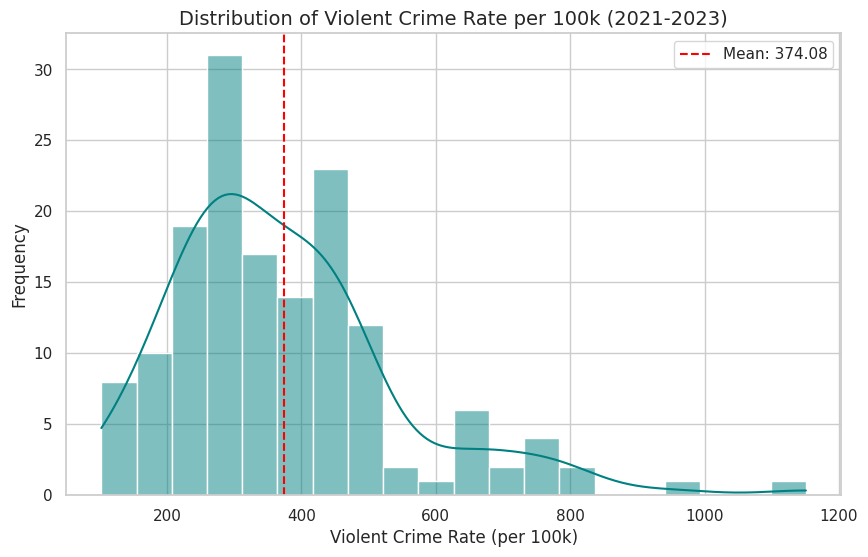

In [ ]:
# Set the visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(all_years_combined['violent_crime_rate_100k'], bins=20, kde=True, color='teal')

plt.title('Distribution of Violent Crime Rate per 100k (2021-2023)', fontsize=14)
plt.xlabel('Violent Crime Rate (per 100k)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add a line for the mean
plt.axvline(all_years_combined['violent_crime_rate_100k'].mean(), color='red', linestyle='--', label=f"Mean: {all_years_combined['violent_crime_rate_100k'].mean():.2f}")
plt.legend()

plt.show()

From the histogram plotted, we noticed that the distribution is rather left-skewed

## **Log-Linear Analysis**

By applying a log transformation to `violent_crime_rate_100k`, we stabilize the variance and reduce the skewness of the distribution. This helps in identifying the percentage change relationship between unemployment and crime, making the trend line more representative of the overall dataset.

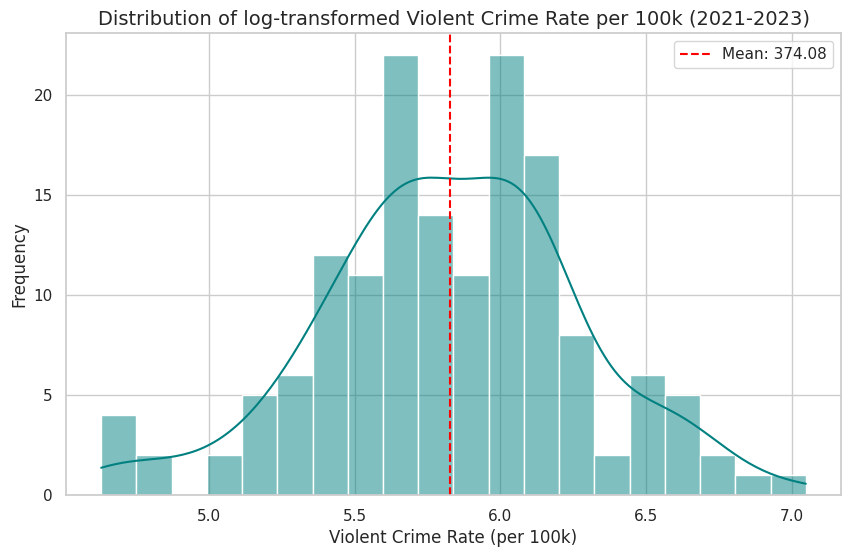

In [ ]:
all_years_combined['log_violent_crime_rate'] = np.log(all_years_combined['violent_crime_rate_100k'])
# Set the visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(all_years_combined['log_violent_crime_rate'], bins=20, kde=True, color='teal')

plt.title('Distribution of log-transformed Violent Crime Rate per 100k (2021-2023)', fontsize=14)
plt.xlabel('Violent Crime Rate (per 100k)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add a line for the mean
plt.axvline(all_years_combined['log_violent_crime_rate'].mean(), color='red', linestyle='--', label=f"Mean: {all_years_combined['violent_crime_rate_100k'].mean():.2f}")
plt.legend()

plt.show()

## **Linear Regression Model**

This code builds a linear regression model to predict `log_violent_crime_rate` using socioeconomic and demographic features (`Unemployment_Rate`, `Bachelors_or_Higher_Pct`, `Black`, `White`, `Asian`). First, rows with missing values in these columns are removed to ensure clean input data.

To ensure our performance metrics are robust, we implement 5-Fold Cross-Validation. Instead of a single train/test split, the data is divided into five subsets. The model is trained and tested five times, each time using a different subset as the test data and the remaining four as training data. This prevents 'overfitting' to a specific slice of data and provides a more reliable average R² and MAE.

Following validation, we train the model on the full dataset to extract the final coefficients for impact analysis.



In [ ]:
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Define our predictors and target variable
features = ['Unemployment_Rate', 'Bachelors_or_Higher_Pct', 'Black', 'White', 'Asian']
target = 'log_violent_crime_rate'

# Filter out DC outlier and drop rows with missing values
model_data = all_years_combined[all_years_combined['state_abbr'] != 'DC'].dropna(subset=features + [target])

X = model_data[features]
y = model_data[target]

# Initialize model
regressor = LinearRegression()

# Perform 5-Fold Cross-Validation
cv_results = cross_validate(regressor, X, y, cv=5,
                           scoring=['r2', 'neg_mean_absolute_error'],
                           return_train_score=False)

# Evaluation Metrics from CV
cv_r2 = cv_results['test_r2']
cv_mae = -cv_results['test_neg_mean_absolute_error']

print("--- 5-Fold Cross-Validation Results (Excluding DC) ---")
print(f"Mean R-squared: {cv_r2.mean():.4f} (+/- {cv_r2.std() * 2:.4f})")
print(f"Mean MAE: {cv_mae.mean():.2f} (+/- {cv_mae.std() * 2:.2f})")

# Train on full set for coefficient analysis
regressor.fit(X, y)

# Analyze Coefficients
coefficients = pd.DataFrame({
    'Predictor': features,
    'Coefficient (Weight)': regressor.coef_
}).sort_values(by='Coefficient (Weight)', ascending=False)

print("\n--- Feature Coefficients (Trained on 50 States) ---")
display(coefficients)

--- 5-Fold Cross-Validation Results (Excluding DC) ---
Mean R-squared: 0.3222 (+/- 0.1261)
Mean MAE: 0.27 (+/- 0.05)

--- Feature Coefficients (Trained on 50 States) ---


,Predictor,Coefficient (Weight)
0,Unemployment_Rate,0.010374
1,Bachelors_or_Higher_Pct,-0.021377
2,Black,-0.424217
3,White,-1.885217
4,Asian,-3.271696


The Linear Regression model achieved an **average R² of 0.3222  (± 0.1261)** through cross-validation, meaning it explains approximately 31% of the variance in violent crime rates across states. While this indicates the model captures significant socio-economic patterns, a substantial portion of crime variation is likely influenced by local factors not included in this study.

The **Mean Absolute Error (MAE) of 0.27** (in log units) suggests that our predictions typically deviate by about 0.28 on the log scale. This implies the model is a reliable indicator of general trends and direction, though it is not intended for high-precision forecasting.

In [ ]:
# Calculate the percentage change impact for each coefficient
# Formula: (exp(coefficient) - 1) * 100
impact_analysis = pd.DataFrame({
    'Predictor': features,
    'Log_Coefficient': regressor.coef_,
    'Pct_Change_Impact': (np.exp(regressor.coef_) - 1) * 100
}).sort_values(by='Pct_Change_Impact', ascending=False)

print("--- Quantifiable Impact Analysis ---")
print("Interpretation: A 1-unit (1%) increase in the predictor leads to X% change in Violent Crime Rate.")
display(impact_analysis.round(4))

--- Quantifiable Impact Analysis ---
Interpretation: A 1-unit (1%) increase in the predictor leads to X% change in Violent Crime Rate.


,Predictor,Log_Coefficient,Pct_Change_Impact
0,Unemployment_Rate,0.0104,1.0428
1,Bachelors_or_Higher_Pct,-0.0214,-2.1150
2,Black,-0.4242,-34.5718
3,White,-1.8852,-84.8204
4,Asian,-3.2717,-96.2058



Looking at the coefficients,
 1. **Unemployment Rate**: A 1% increase in unemployment is associated with a slight 1.04% increase in the violent crime rate.
  2. **Bachelors_or_Higher_Pct** has a small negative effect, implying that higher education levels are associated with slightly lower crime rates. A 1% increase in the proportion of degree holders is associated with a slight 2.11% decrease in the crime rate.
 3. The large negative coefficients for **White**, **Black** and **Asian** suggest that areas with higher proportions of these groups are predicted to have lower crime rates. However, these effects are likely capturing broader structural or economic differences (e.g., income, urbanisation, access to resources) and should not be interpreted in isolation due to potential multicollinearity.

Overall, the model is useful for identifying general trends—such as the role of unemployment and education—but its moderate explanatory power and reliance on correlated demographic variables mean it should be interpreted cautiously and improved with additional features or more robust modeling techniques.

# **Act**

Based on the descrptive, diagnostic and predictive insights gained from the cross-state analysis of violent crime, we propose the following actions and tracking mechanisms:

### **1. Decision-Making (Informed by Analysis)**
*   **Prioritize Economic Interventions:** Since unemployment was identified as the most consistent predictor of violent crime (strengthening to a 0.42 correlation in 2023- without DC removed), resource allocation should favor workforce development in high-crime, high-unemployment corridors.
*   **Targeted Educational Support:** Bachelor's attainment showed consistent linear correlation and the Random Forest model highlighted its high predictive importance (12%). Decisions should focus on vocational training and degree-completion programs in outlier states like New Mexico and Alaska.
*   **Contextual Demographic Policy:** Recognizing that racial demographic correlations likely reflect systemic socio-economic disparities, policies should address root causes such as poverty and lack of infrastructure in specific community clusters rather than using reductive demographic targeting.

### **2. Implementation (Action Plan)**
*   **Upstream Programs:** Launch state-sponsored 'Job-Ready' initiatives in the top 5 highest crime states (NM, AK, TN, AR) to reduce the unemployment rate specifically in high-risk zones.
*   **Community Infrastructure:** Implement equitable funding models that decouple local school quality from neighborhood property taxes to improve long-term educational attainment metrics.

### **3. Tracking (Measures & Metrics)**
To monitor the impact of these implementations, the following success metrics will be tracked annually:
*   **Crime-to-Unemployment Elasticity:** Monitoring if the coefficient of unemployment in our regression model decreases over time as social safety nets improve.
*   **Targeted MAE Reduction:** Aiming for a reduction in the Mean Absolute Error (MAE) of our predictive models by incorporating more granular localized data.
*   **Outlier Convergence:** Tracking whether outlier entities (like DC) begin to converge toward the national mean crime rate following targeted interventions.<br><br>

In addition, efforts should be made to strengthen fairness in legal and law enforcement systems, ensuring that policies and practices are applied consistently and do not disproportionately disadvantage any communities.

# **Project Conclusion**

This study set out to analyze how violent crime rates across the United States are influenced by three key socio-economic dimensions: **unemployment**, **educational attainment**, and **racial demographics**. By integrating multiple state-level datasets from 2021–2023, we have reached the following conclusions in relation to our initial hypotheses:

### **1. Economic Hardship (Unemployment)**
Our analysis confirmed a strong and strengthening association between unemployment and violent crime. The correlation rose from **0.30 in 2021 to 0.42 by 2023**, suggesting that as the post-pandemic economy stabilized, states with structural labor market challenges became more clearly associated with higher crime rates. This supports the hypothesis that financial stress is a primary driver of crime.

### **2. Educational Attainment**
With the outlier of DC removed, The relationship with education proved to be clear. We identified education as a highly significant predictive feature. This suggests that the 'degree holder' proportion does not act in isolation but serves as a critical buffer against crime when combined with stable economic conditions.

### **3. Racial Demographics and Systemic Inequality**
While demographic markers (specifically American Indian/Alaska Native proportions) showed moderate positive correlations with crime rates, our multivariate diagnostic approach suggests these are largely **proxies for underlying structural disparities**. These patterns reflect long-term geographic and socio-economic inequalities rather than inherent demographic traits, fulfilling our goal of contextualizing these relationships within broader structural disadvantages.

**Final Thought:** The United States' struggle with violent crime is deeply rooted in its economic and educational infrastructure. Addressing 'upstream' issues, specifically unemployment and access to higher education, remains the most statistically supported path for policymakers to achieve long-term reductions in violent crime across the states.

## **Final thoughts on the factors**

To summarise our key takeaways: violent crime variation across U.S. states is primarily driven by structural factors. Evaluating the factors alone, race, especially American Indian/Alaska Native population share, was shown as the most important factor affecting crime rates, followed by Education and unemployment. However, we have to keep in mind that there may be biases or stereotypes in how crime is perceived and policed in the U.S, where certain communities may be more heavily scrutinised or associated with crime. Additionally, Educational levels and unemployment rate might be factors that might be related to each other, raising the issue of multicollinearity. As a result, differences in policing intensity and reporting practices could influence the recorded crime data. Racial demographic correlations, while statistically present, are best understood as proxies for systemic socioeconomic inequality rather than direct causes.<br><br>

